# **Trabajo Fin de Máster**

# **Optimización de la biopsia líquida mediante Machine Learning: Detección y diagnóstico del origen tumoral a partir del transcriptoma plaquetario**


## **Fase 1: comprensión de los datos**

Objetivo del bloque: cargar el conjunto de datos GSE68086 a partir de Google Drive, obtener las etiquetas correctas desde los metadatos de GEO y hacer un primer análisis exploratorio.

*Nota:* el tipo de cáncer se toma del campo "cancer type" del fichero
series_matrix de GEO, no del nombre de las columnas de la matriz de
expresión (porque son ambiguos: Type-Unknown-N, MGH-BrCa-*,...).

### **Carga del conjunto de datos**

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
from google.colab import drive
import os

semilla = 42 # semilla fija para reproducibilidad
np.random.seed(semilla)

# Se define la paleta de colores
azul_oscuro, verde_azulado, fondo_claro = "#33415C", "#0F5C6B", "#F8F9FB"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 30)

Para evitar bloqueos, la descarga de datos se hace de forma manual desde el enlace: https://ftp.ncbi.nlm.nih.gov/geo/series/GSE68nnn/GSE68086 .

Los archivos se suben a Google Drive y desde allí, se conectan con Google Colab.

In [103]:
# Se conecta Google Colab con Google Drive
drive.mount('/content/drive')

ruta_drive = "/content/drive/My Drive/archivos_tfm/"

archivo_expresion = os.path.join(ruta_drive, "GSE68086_TEP_data_matrix.txt.gz")
archivo_metadatos = os.path.join(ruta_drive, "GSE68086_series_matrix.txt.gz")

# Se comprueba que la carga se ha realizado de forma correcta
if os.path.exists(archivo_expresion) and os.path.exists(archivo_metadatos):
    print("Archivos encontrados en Google Drive.\n")
else:
    print("No se han encontrado los archivos.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivos encontrados en Google Drive.



In [104]:
expr = pd.read_csv(archivo_expresion, sep="\t", index_col=0)
print("Dimensiones (genes × muestras):", expr.shape)
print("Ejemplo de nombres de columna:", list(expr.columns[:5]))
expr.iloc[:4, :4]

Dimensiones (genes × muestras): (57736, 285)
Ejemplo de nombres de columna: ['3-Breast-Her2-ampl', '8-Breast-WT', '10-Breast-Her2-ampl', 'Breast-100', '15-Breast-Her2-ampl']


,3-Breast-Her2-ampl,8-Breast-WT,10-Breast-Her2-ampl,Breast-100
ENSG00000000003,0,0,0,0
ENSG00000000005,0,0,0,0
ENSG00000000419,44,14,16,8
ENSG00000000457,26,1,14,0


El archivo de GEO contiene 57736 genes y 285 individuos/muestras.

### **Obtención de las etiquetas correctas desde los metadatos de GEO**

El estado de cada muestra (sano, cáncer de pulmón,...) se extrae desde el archivo series_matrix de GEO. En él, cada muestra tiene varios campos de características (age, gender, cancer type,...).

El siguiente código muestra un ejemplo de cada campo para localizar el de "cancer type".

In [105]:
titulos = accesos = None
lista_caracteristicas = []
with gzip.open(archivo_metadatos, "rt") as f:
    for linea in f:
        if linea.startswith("!series_matrix_table_begin"):
            break
        if linea.startswith("!Sample_title"):
            titulos = [v.strip().strip('"') for v in linea.rstrip("\n").split("\t")[1:]]
        elif linea.startswith("!Sample_geo_accession"):
            accesos = [v.strip().strip('"') for v in linea.rstrip("\n").split("\t")[1:]]
        elif linea.startswith("!Sample_characteristics_ch1"):
            valores = [v.strip().strip('"') for v in linea.rstrip("\n").split("\t")[1:]]
            lista_caracteristicas.append(valores)

metadatos = pd.DataFrame({"titulo": titulos, "gsm": accesos})
caract_df = pd.DataFrame(lista_caracteristicas).T
caract_df.columns = [f"caracteristica_{i}" for i in range(caract_df.shape[1])]

print("Muestras en el series_matrix:", len(metadatos))
print("Campos de características por muestra:", caract_df.shape[1], "\n")
for c in caract_df.columns:
    print(c, "-->", caract_df[c].dropna().iloc[0])   # un ejemplo de cada campo

Muestras en el series_matrix: 285
Campos de características por muestra: 6 

caracteristica_0 --> tissue: blood
caracteristica_1 --> cell type: Thrombocytes
caracteristica_2 --> patient id: Breast-03
caracteristica_3 --> cancer type: Breast
caracteristica_4 --> batch: Batch03
caracteristica_5 --> mutational subclass: HER2+


En la salida anterior, la característica situada en la posición 3 aparece asociada a "cancer type" en la muestra tomada como ejemplo. Tomando esa misma posición para todas las muestras se obtiene la siguiente distribución.

In [106]:
# Se limpia el texto para quitar el prefijo "cancer type: " y quedar solo el valor
tipos_cancer = caract_df["caracteristica_3"].str.split(":", n=1).str[1].str.strip()

print("Diferentes estados (HC: Healthy control):\n")
print(tipos_cancer.unique())

print("\n\nDistribución por tipo según GEO:\n")
print(tipos_cancer.value_counts())

Diferentes estados (HC: Healthy control):

['Breast' 'Hepatobiliary' 'CRC' 'GBM' 'HC' 'Lung' 'Pancreas' 'PIK3CA' 'wt'
 'HER2+' 'KRAS' 'EGFR']


Distribución por tipo según GEO:

caracteristica_3
HC               55
GBM              40
Lung             40
CRC              38
Pancreas         35
Breast           24
Hepatobiliary    13
wt               12
KRAS             11
EGFR              9
HER2+             6
PIK3CA            2
Name: count, dtype: int64


El resultado incluye 5 valores que no corresponden a ningún órgano ni al grupo de control: wt, KRAS, EGFR, HER2+ y PIK3CA. Los cuatro últimos son alteraciones moleculares y wt (wild type) indica que se analizó un gen y no se halló mutación, de modo que ninguno señala la localización del tumor.

Antes de concluir que el depósito de GEO mezcla ambos tipos de anotaciones (cánceres con alteraciones moleculares) se debe revisar el método de extracción.

Se ha tomado siempre la posición 3 para deducir el tipo de cáncer, pero nada garantiza que todas las muestras registren los mismos campos ni en el mismo orden. Si el número de características varía de una muestra a otra, esa posición contendrá información distinta según el caso. Por tanto, se comprobará localizando cada campo por su clave.

In [107]:
def extraer_campo(fila, clave):
    """Localiza un campo por su clave, sea cual sea la posición que ocupe."""
    for valor in fila:
        if isinstance(valor, str) and valor.split(":", 1)[0].strip().lower() == clave:
            return valor.split(":", 1)[1].strip()
    return None

tipo_por_clave = caract_df.apply(lambda f: extraer_campo(f, "cancer type"), axis=1)
subclase = caract_df.apply(lambda f: extraer_campo(f, "mutational subclass"), axis=1)

print("Campo 'cancer type' localizado por su clave:")
print(tipo_por_clave.value_counts(dropna=False).to_string())
print(f"\nMuestras sin campo 'cancer type': {tipo_por_clave.isna().sum()}\n")

print("Campo 'mutational subclass':")
print(subclase.value_counts(dropna=False).to_string())

Campo 'cancer type' localizado por su clave:
Lung             60
HC               55
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14

Muestras sin campo 'cancer type': 0

Campo 'mutational subclass':
wt                 175
KRAS                63
EGFR                13
HER2+               10
EGFR, MET            8
Triple Negative      6
PIK3CA               6
HER2+, PIK3CA        2
MET                  1
KRAS, MET            1


Localizando el campo por su clave, las 285 muestras registran un valor de "cancer type" que corresponde a uno de los siete grupos esperados, con la distribución Lung 60, HC 55, CRC 42, GBM 40, Breast 39, Pancreas 35 y Hepatobiliary 14. De esta forma, no aparece ninguna anotación molecular y no queda ninguna muestra sin valor.

Los 5 valores extraños detectados anteriormente proceden de un campo distinto, "mutational subclass", que también está presente en las 285 muestras y que recoge la caracterización molecular del tumor: wt en 175 casos, KRAS en 63, EGFR en 13, HER2+ en 10 y combinaciones como "EGFR, MET" o "HER2+, PIK3CA" en el resto.

Por tanto, el depósito de GEO no mezcla ambos tipos de anotación, sino que lo que ocurre es que el número de características varía de una muestra a otra, de manera que la extracción por posición tomaba el tipo de cáncer en unos casos y la subclase molecular en otros.

Para estar completamente seguros de que el procedimiento de asignación de etiquetas ha sido correcto, se puede contrastar el campo "cancer type" con una fuente independiente. El título de cada muestra en el archivo de metadatos sigue el formato Blood_Platelets_<grupo>-<codigo>, donde el primer elemento identifica el órgano afectado o, en el caso de los controles, el grupo HC. Detectando ese token por palabras clave y cruzándolo con el campo de los metadatos se comprueba si ambas fuentes coinciden.

In [108]:
import re

# Palabras clave por órgano, buscadas en el título sin distinguir mayúsculas
patrones_organo = {
    "Lung":          [r"lung", r"nsclc"],
    "CRC":           [r"crc", r"colo", r"rectal"],
    "GBM":           [r"gbm", r"glio"],
    "Breast":        [r"breast", r"brca", r"mamm"],
    "Pancreas":      [r"panc"],
    "Hepatobiliary": [r"hepato", r"biliary", r"chol", r"liver", r"\bhb\b"],
    "HC":            [r"healthy", r"control",  r"(?<![A-Za-z])hc(?![A-Za-z])"],
}

def detectar_organo(titulo):
    encontrados = [org for org, pats in patrones_organo.items()
                   if any(re.search(p, titulo, re.IGNORECASE) for p in pats)]
    if len(encontrados) == 1:
        return encontrados[0]
    if len(encontrados) == 0:
        return "SIN_DETECTAR"
    return "AMBIGUO:" + "/".join(encontrados)

organo_titulo = metadatos["titulo"].apply(detectar_organo)

print("Órgano leído del título × campo 'cancer type' de los metadatos:\n")
print(pd.crosstab(organo_titulo, tipo_por_clave))

coinciden = (organo_titulo.values == tipo_por_clave.values).all()
print(f"\n¿Coinciden ambas fuentes en las {len(metadatos)} muestras? {coinciden}")

Órgano leído del título × campo 'cancer type' de los metadatos:

col_0          Breast  CRC  GBM  HC  Hepatobiliary  Lung  Pancreas
titulo                                                            
Breast             39    0    0   0              0     0         0
CRC                 0   42    0   0              0     0         0
GBM                 0    0   40   0              0     0         0
HC                  0    0    0  55              0     0         0
Hepatobiliary       0    0    0   0             14     0         0
Lung                0    0    0   0              0    60         0
Pancreas            0    0    0   0              0     0        35

¿Coinciden ambas fuentes en las 285 muestras? True


Con la clase de cada muestra ya establecida en los metadatos, queda asociarla a la columna que le corresponde en la matriz de expresión e insertarla como fila de variable objetivo.

Para ello es necesario comprobar antes si ambos archivos ordenan las muestras de la misma forma. De ser así, bastaría con emparejarlas por su posición.

In [109]:
# Enlace por posición.
# Se asigna a cada columna de expr la clase que ocupa esa misma posición en los metadatos, y se contrasta con el órgano que sugiere el nombre de la columna.
etiquetas_por_posicion = pd.Series(tipo_por_clave.values,
                                   index=expr.columns, name="prueba_posicion")

organo_expr = pd.Series(expr.columns, index=expr.columns).apply(detectar_organo)

print("Órgano del nombre de columna × clase asignada por posición:\n")
print(pd.crosstab(organo_expr, etiquetas_por_posicion))

Órgano del nombre de columna × clase asignada por posición:

prueba_posicion  Breast  CRC  GBM  HC  Hepatobiliary  Lung  Pancreas
row_0                                                               
Breast               34    3    0   0              1     0         0
CRC                   1   37    0   0              1     4         1
GBM                   0    0   38   0              0     0         0
HC                    0    0    0   9              0     0         0
Hepatobiliary         0    0    0   0             12     0         0
Lung                  3    0    0   0              0    56         0
Pancreas              0    0    0   0              0     0        33
SIN_DETECTAR          1    2    2  46              0     0         1


Como se puede observar, el orden parece no ser exactamente el mismo en los dos archivos de texto, ya que hay algunas muestras de series_matrix que corresponden a un tipo de cáncer y corresponderían a otro tipo de cáncer distinto en data_matrix. Por tanto, no se puede suponer que el orden sea el mismo.

Si se analizan los nombres de las muestras en cada uno de los archivos, se tiene que:

In [110]:
cols_expr = list(expr.columns)
titulos_meta = list(metadatos["titulo"])

print("¿Hay el mismo número de muestras?", len(cols_expr), "columnas expr /",
      len(titulos_meta), "títulos metadatos\n")

print("Columnas de expr:")
print(cols_expr, "\n")
print("Títulos de metadatos:")
print(titulos_meta, "\n")

# Coincidencias con distintos niveles de tolerancia
exactas = set(cols_expr) & set(titulos_meta)
print("Coincidencias exactas:", len(exactas), "de", len(cols_expr))

norm = lambda s: str(s).strip().lower().replace(" ", "")
map_norm = {norm(t): t for t in titulos_meta}
coinc_norm = sum(1 for c in cols_expr if norm(c) in map_norm)
print("Coincidencias ignorando mayúsculas/espacios:", coinc_norm, "de", len(cols_expr))

¿Hay el mismo número de muestras? 285 columnas expr / 285 títulos metadatos

Columnas de expr:
['3-Breast-Her2-ampl', '8-Breast-WT', '10-Breast-Her2-ampl', 'Breast-100', '15-Breast-Her2-ampl', '16-Breast-WT', '21-Breast-WT', '33-Breast-Her2-ampl', '42-Breast-Her2-ampl', 'Breast-454', '48-Breast-WT', '50-Breast-WT', '55-Breast-WT', 'Type-Unknown-6', 'Breast-564', '59-Breast-WT', 'Breast-590', 'Breast-60', 'Breast-603', 'ALK61-Breast-Her2-unknown', 'Breast-85', 'Breast-86', '97-Breast-Her2-ampl', 'Breast-ALK-82', '292-Liver-KRAS', '316-Liver-KRAS', '341-Liver-WT', '376-Liver-WT', '379-Liver-WT', 'Chol-410', 'Chol-442', 'Chol-460', 'Chol-611', 'Chol-ALK-28', 'VU256-CRC', 'VU258-CRC', 'VU272-CRC', 'VU276-CRC', 'Type-Unknown-1', '329-CRC-KRAS', '342-CRC-KRAS', 'Type-Unknown-5', '354-CRC-WT', '356-CRC-WT', 'CRC-357', '374-CRC-WT', '378-CRC-WT', '420-CRC-WT', '429-CRC-WT', 'CRC-450', '453-CRC-KRAS', 'CRC-459', '462-CRC-KRAS', 'CRC-463', '466-CRC-KRAS', '474-CRC-WT', 'CRC-487', 'CRC-496', '497

Ambos archivos de texto tienen nombres diferentes asociados a cada una de las muestras.

La matriz de expresión usa nombres como '3-Breast-Her2-ampl' o 'VU274-CRC', mientras que el series_matrix (matriz de metadatos) utiliza el formato 'Blood_Platelets_Breast-03'.

No hay ninguna coincidencia exacta entre ambos conjuntos de nombres, ni tampoco al ignorar mayúsculas y espacios, por lo que no es posible enlazarlos directamente por texto. El emparejamiento por posición tampoco funciona, ya que el orden de las muestras es diferente entre los dos archivos, sobre todo en el tramo final (las muestras con prefijo 'MGH-' y 'Vumc-').

Además, el nombre de columna de la matriz de expresión no siempre indica el
órgano correcto. Por ejemplo, la columna 'VU274-CRC' aparece en el
series_matrix como 'Liver-274', es decir, hepatobiliar, y 'MGH-CRC-BRAF4' como 'Chol-BRAF4', también hepatobiliar. Por lo que, tomar la clase del nombre de
columna daría 44 muestras de colorrectal y 12 de hepatobiliar, en lugar de las 42 y 14 que registra el series_matrix. Por este motivo, la clase de cada muestra se toma siempre del campo "cancer type" del series_matrix, que es la fuente autorizada, y no del nombre de la columna de la matriz de expresión.

El enlace entre ambos archivos se forma entonces, a partir del código identificador de la muestra (el número o código corto que ambos archivos tienen en común), depurado para que sea comparable entre los dos formatos.

La clase la aporta el metadato, y el órgano leído del nombre de columna se usa solamente como pista para desempatar los códigos que se repitan en más de un órgano. Las muestras de control sano ('HD-' y 'Control-') se identifican directamente por su prefijo como sanos. Y, por último, las cinco muestras señaladas como 'Type-Unknown-N' en el data_matrix, que carecen de
código aprovechable, se identifican a partir de la clase de sus muestras
anteriores y posteriores en la matriz, y solo cuando estas coinciden.

Todo el proceso se valida al final contrastando la distribución de clases obtenida con la que registra el series_matrix.

In [111]:
from collections import defaultdict

def limpiar_codigo(texto):
    if not isinstance(texto, str):
        return ""
    t = re.sub(r"[^A-Za-z0-9]", "", texto.upper())      # solo alfanumérico
    m = re.match(r"^([A-Z]*)0*(\d+)([A-Z]*)$", t)        # quita ceros a la izquierda
    return m.group(1) + m.group(2) + m.group(3) if m else t

# La clase procede del campo "cancer type" de los metadatos, localizado por su
# clave. El código identificador se extrae del título, que es donde figura.
nucleo   = metadatos["titulo"].str.replace("Blood_Platelets_", "", regex=False)
cod_meta = (nucleo.str.split("-", n=1).str[1]
                  .str.replace("ALK", "", regex=False)
                  .apply(limpiar_codigo))

metadatos["clase"]  = tipo_por_clave.replace({"HC": "Sano"}).values
metadatos["codigo"] = cod_meta

print("Distribución según metadatos (referencia):")
print(metadatos["clase"].value_counts(), "\n")

# Índice codigo: clases posibles (para desempatar)
codigo_a_clases = defaultdict(set)
for cod, cls in zip(metadatos["codigo"], metadatos["clase"]):
    codigo_a_clases[cod].add(cls)

Distribución según metadatos (referencia):
clase
Lung             60
Sano             55
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14
Name: count, dtype: int64 



In [112]:
# Pista de órgano a partir del nombre de columna (solo para desempatar)
pistas = {"BrCa": "Breast", "Breast": "Breast", "NSCLC": "Lung", "Lung": "Lung",
          "CRC": "CRC", "GBM": "GBM", "Pancr": "Pancreas", "Panc": "Pancreas",
          "Liver": "Hepatobiliary", "Chol": "Hepatobiliary",
          "HD": "Sano", "Control": "Sano"}

def pista_organo(nombre):
    for token, cls in pistas.items():
        if re.search(token, nombre, re.IGNORECASE):
            return cls
    return None

def codigo_expr(nombre):
    s = nombre.upper()
    s = re.sub(r"PLATELET-?HISEQ|-?TR-?\d+|HER2|AMPL|UNKNOWN|-WT|-KRAS|-EGFR|VIII", " ", s)
    for t in ["BLOOD_PLATELETS", "MGH", "VUMC", "VU", "BREAST", "BRCA", "NSCLC",
              "LUNG", "CRC", "GBM", "PANCR", "PANC", "LIVER", "CHOL",
              "HD", "CONTROL", "ALK"]:
        s = re.sub(t, " ", s)
    s = re.sub(r"(\d)J", r"\1", s)      # quita la J de sufijos tipo 0020J
    return limpiar_codigo(s)

filas = []
for col in expr.columns:
    pista = pista_organo(col)
    if pista == "Sano":                     # todo HD/Control es sano, sin cruzar número
        clase, origen = "Sano", "sano"
    else:
        cod = codigo_expr(col)
        posibles = codigo_a_clases.get(cod, set())
        if len(posibles) == 1:              # código único: manda el metadato
            clase, origen = next(iter(posibles)), "codigo"
        elif len(posibles) > 1:             # choque de códigos: desempata la pista
            clase = pista if pista in posibles else None
            origen = "codigo+pista"
        else:                               # sin match de código: usa la pista
            clase, origen = pista, ("pista" if pista else "SIN_RESOLVER")
    filas.append((col, pista, clase, origen))

diag = pd.DataFrame(filas, columns=["columna", "pista", "clase", "origen"])

print("Resueltas por origen:")
print(diag["origen"].value_counts(), "\n")
print("Columnas SIN RESOLVER:")
print(diag[diag["clase"].isna()]["columna"].tolist(), "\n")
print("Distribución provisional en expr:")
print(diag["clase"].value_counts())

Resueltas por origen:
origen
codigo          169
sano             54
codigo+pista     43
pista            14
SIN_RESOLVER      5
Name: count, dtype: int64 

Columnas SIN RESOLVER:
['Type-Unknown-6', 'Type-Unknown-1', 'Type-Unknown-5', 'Type-Unknown-3', 'Type-Unknown-4'] 

Distribución provisional en expr:
clase
Lung             60
Sano             54
CRC              40
GBM              40
Breast           38
Pancreas         34
Hepatobiliary    14
Name: count, dtype: int64


In [113]:
# Las Type-Unknown se resuelven por la clase de sus columnas vecinas en la matriz
# Solo se asigna si las dos vecinas coinciden

orden = list(expr.columns)
clase_por_col = dict(zip(diag["columna"], diag["clase"]))

for col in diag.loc[diag["clase"].isna(), "columna"]:
    i = orden.index(col)
    vecinas = [clase_por_col.get(orden[j]) for j in (i - 1, i + 1)
               if 0 <= j < len(orden)]
    vecinas = [v for v in vecinas if v]
    if len(set(vecinas)) == 1:
        clase_por_col[col] = vecinas[0]
        print(f"{col}: -> {vecinas[0]}  (vecinas: {orden[i-1]}, {orden[i+1]})")
    else:
        print(f"{col}: vecinas discrepantes {vecinas}, requiere revisión manual")

# Etiquetas finales
etiquetas = pd.Series([clase_por_col[c] for c in expr.columns], index=expr.columns, name="tipo_tumor")

esperado = {"Lung": 60, "Sano": 55, "CRC": 42, "GBM": 40, "Breast": 39, "Pancreas": 35, "Hepatobiliary": 14}
print("\nSin etiqueta:", etiquetas.isna().sum())
print(etiquetas.value_counts())
print("\n¿Coincide con la referencia del metadato?",
      etiquetas.value_counts().to_dict() == esperado)

Type-Unknown-6: -> Breast  (vecinas: 55-Breast-WT, Breast-564)
Type-Unknown-1: -> CRC  (vecinas: VU276-CRC, 329-CRC-KRAS)
Type-Unknown-5: -> CRC  (vecinas: 342-CRC-KRAS, 354-CRC-WT)
Type-Unknown-3: -> Sano  (vecinas: Control-13, HD-17-1)
Type-Unknown-4: -> Pancreas  (vecinas: 448-Pancr-KRAS, Panc-451)

Sin etiqueta: 0
tipo_tumor
Lung             60
Sano             55
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14
Name: count, dtype: int64

¿Coincide con la referencia del metadato? True


Una vez encontrada la correspondencia correcta entre las muestras y sus etiquetas, es momento de insertar la fila objetivo en la matriz de datos.

In [114]:
# Para no modificar la matriz original, se trabajará con una copia
expr_con_obj = expr.copy()

# Se añade la variable objetivo como nueva fila
expr_con_obj.loc["tipo_tumor"] = etiquetas

print("Dimensiones de la matriz original:", expr.shape)
print("Dimensiones de la matriz copia (con la etiqueta):", expr_con_obj.shape)

# Vemos las últimas filas de la copia para confirmarlo
expr_con_obj.tail(3)

Dimensiones de la matriz original: (57736, 285)
Dimensiones de la matriz copia (con la etiqueta): (57737, 285)


,3-Breast-Her2-ampl,8-Breast-WT,10-Breast-Her2-ampl,Breast-100,15-Breast-Her2-ampl,16-Breast-WT,21-Breast-WT,33-Breast-Her2-ampl,42-Breast-Her2-ampl,Breast-454,48-Breast-WT,50-Breast-WT,55-Breast-WT,Type-Unknown-6,Breast-564,...,MGH-NSCLC-L07-TR459,MGH-NSCLC-L11-TR477,MGH-NSCLC-L12-TR478,MGH-NSCLC-L18-TR479,MGH-NSCLC-L19-TR461,MGH-NSCLC-L20-TR500,MGH-NSCLC-L22-TR462,MGH-NSCLC-L23-TR524,MGH-NSCLC-L25-TR480,MGH-NSCLC-L39-TR519,MGH-NSCLC-L40-TR520,MGH-NSCLC-L51-TR521,MGH-NSCLC-L58-TR525,MGH-NSCLC-L59-TR522,MGH-NSCLC-L65-TR523
ENSG00000273492,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000273493,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
tipo_tumor,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,...,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung


Con la fila de etiquetas ya insertada en la matriz de datos, se puede realizar el análisis exploratorio inicial.

### **Análisis exploratorio inicial**

En este apartado se comprueba la existencia de valores faltantes, se examina la distribución de los valores de expresión y la escala de los conteos, se cuantifica el desbalance entre clases y se identifican las réplicas presentes en el conjunto.

In [115]:
# Primero se estudia la existencia de valores faltantes
n_faltantes = int(expr.isna().sum().sum())
prop_ceros = (expr == 0).to_numpy().mean()

print("Valores faltantes (NaN) en la matriz:", n_faltantes)
print(f"Proporción de ceros en la matriz: {prop_ceros:.2%}")
print("Los ceros no son valores faltantes, sino que representan ausencia de expresión detectada.")

Valores faltantes (NaN) en la matriz: 0
Proporción de ceros en la matriz: 85.21%
Los ceros no son valores faltantes, sino que representan ausencia de expresión detectada.


Este dataset no presenta valores faltantes, por lo que el siguiente paso es ver cómo se comportan los valores de expresión.

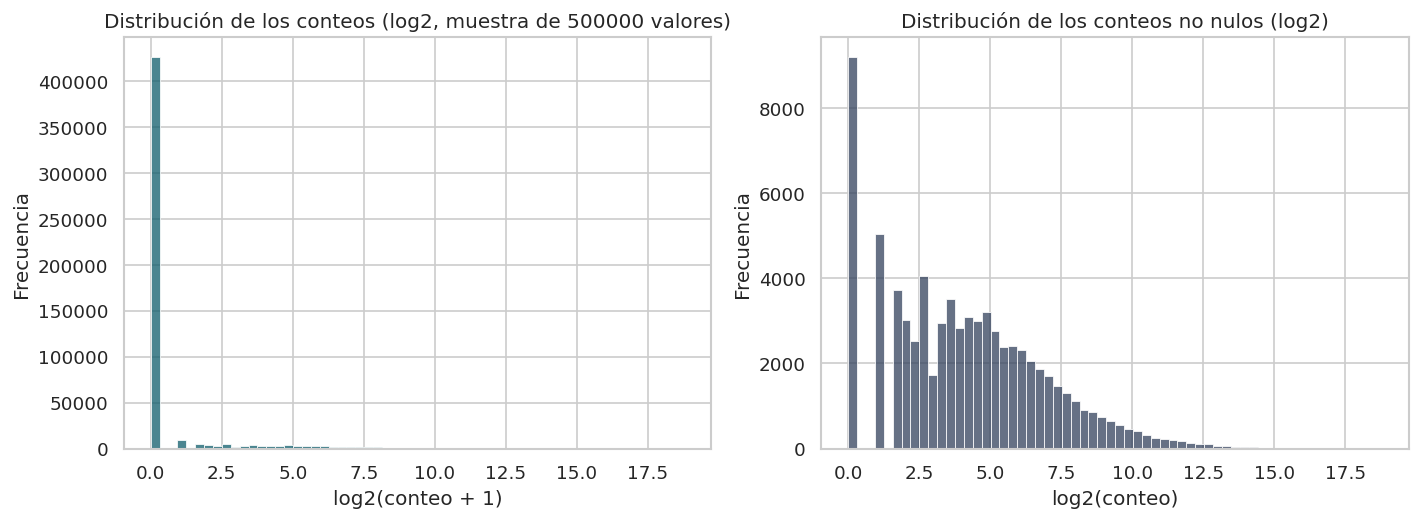

In [116]:
rng = np.random.default_rng(semilla)

# La matriz contiene más de 16 millones de valores (celdas), así que se toma una muestra aleatoria de 500.000 para representar el histograma
valores = expr.to_numpy().ravel()
muestra_val = rng.choice(valores, size=500_000, replace=False)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

# Los valores se representan en escala logarítmica en base 2 porque los conteos de RNA-seq abarcan un rango muy amplio, con muchísimas celdas nulas o de valor bajo y unos pocos genes que acumulan cantidades enormes de lecturas.
# Sin transformar, casi todos los datos quedarían comprimidos junto al eje y el gráfico no mostraría nada.
# Se usa base 2 y no base 10, ya que cada unidad de esa escala corresponde a duplicar la expresión, lo que permite leer las diferencias directamente como cambios de magnitud.
# La suma de una unidad previa a la transformación evita que los valores nulos, para los que el logaritmo no está definido, queden fuera de la representación.
sns.histplot(np.log2(muestra_val + 1), bins=60, color=verde_azulado, ax=ejes[0])
ejes[0].set_title("Distribución de los conteos (log2, muestra de 500000 valores)")
ejes[0].set_xlabel("log2(conteo + 1)"); ejes[0].set_ylabel("Frecuencia")

no_nulos = muestra_val[muestra_val > 0]
sns.histplot(np.log2(no_nulos), bins=60, color=azul_oscuro, ax=ejes[1])
ejes[1].set_title("Distribución de los conteos no nulos (log2)")
ejes[1].set_xlabel("log2(conteo)"); ejes[1].set_ylabel("Frecuencia")

plt.tight_layout(); plt.show()

Las dos gráficas muestran la distribución de los valores de expresión en escala logarítmica en base 2. En la primera se representan todos los valores de la matriz, sumando una unidad antes de transformar para poder incluir los ceros. La barra situada en el extremo izquierdo corresponde justamente a esos ceros, que suponen el 85,21% de la matriz y dominan por completo la distribución. El resto de valores se reparte en una curva que desciende de forma continua a medida que aumenta la expresión.

La segunda gráfica excluye los ceros para poder observar los valores realmente detectados. La distribución sigue siendo claramente asimétrica hacia la derecha, ocurriendo que la mayor parte de los genes presenta conteos bajos y solo una minoría alcanza valores muy altos. El hecho de que esta asimetría se mantenga tras eliminar los ceros indica que no la provocan las ausencias de expresión, sino la propia naturaleza de los datos de secuenciación, en los que unos pocos genes muy activos concentran una gran parte de las lecturas.

Ambas gráficas condicionan el preprocesado dado que la gran cantidad de ceros justifica el filtrado de los genes que apenas se detectan, ya que no aportan información y solo añaden dimensionalidad. La asimetría, por su parte, justifica la transformación logarítmica, que comprime el rango de valores y evita que los genes más expresados dominen el entrenamiento de los modelos.

Comprobada la distribución de los valores de expresión, es necesario examinar la escala de los conteos desde dos puntos de vista.

- Por muestra, interesa saber cuántas lecturas totales se han obtenido en cada una, ya que ese volumen afecta directamente a la magnitud de sus valores.
- Por gen, interesa conocer en cuántas muestras se detecta expresión, lo que permite estimar qué proporción del transcriptoma aporta información real al análisis.

Lecturas por muestra -> mín 218,517 | mediana 2,015,926 | máx 7,273,295
Genes sin ninguna lectura en todas las muestras: 29,195
Genes con cero en más del 90% de las muestras: 44,291


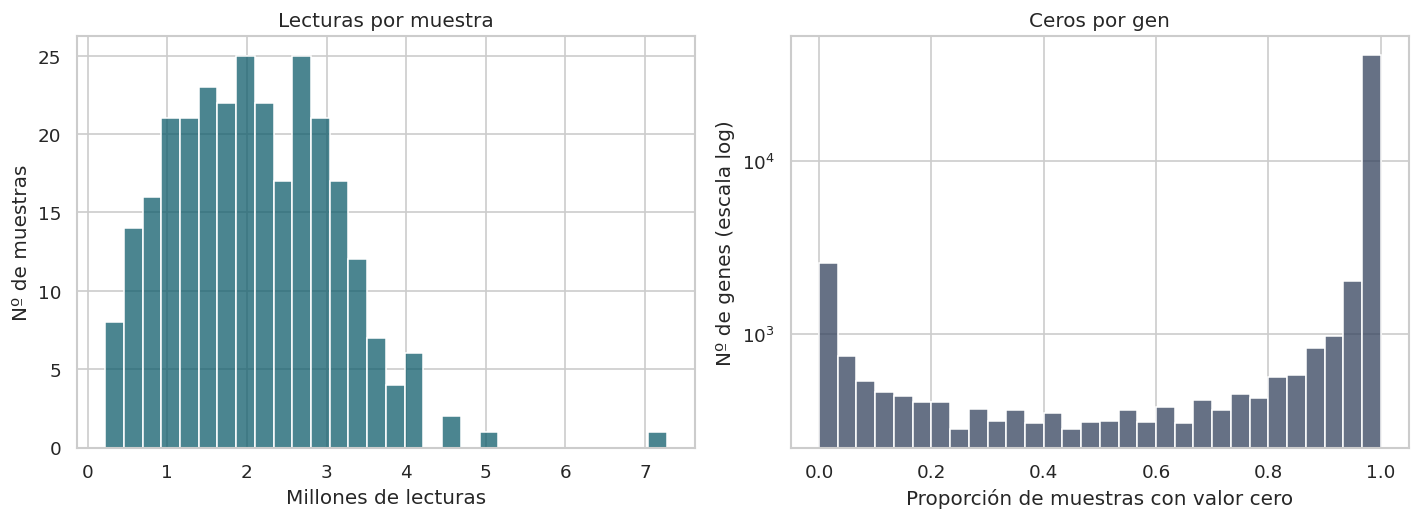

In [117]:
tam_libreria = expr.sum(axis=0)             # lecturas por muestra
ceros_por_gen = (expr == 0).mean(axis=1)    # fracción de muestras con cero, por gen
genes_todo_cero = int((expr.sum(axis=1) == 0).sum())

print(f"Lecturas por muestra -> mín {tam_libreria.min():,.0f} | "
      f"mediana {tam_libreria.median():,.0f} | máx {tam_libreria.max():,.0f}")
print(f"Genes sin ninguna lectura en todas las muestras: {genes_todo_cero:,}")
print(f"Genes con cero en más del 90% de las muestras: {(ceros_por_gen > 0.9).sum():,}")

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(tam_libreria / 1e6, bins=30, color=verde_azulado, ax=ejes[0])
ejes[0].set_title("Lecturas por muestra")
ejes[0].set_xlabel("Millones de lecturas"); ejes[0].set_ylabel("Nº de muestras")

sns.histplot(ceros_por_gen, bins=30, color=azul_oscuro, ax=ejes[1])
ejes[1].set_yscale("log")
ejes[1].set_title("Ceros por gen")
ejes[1].set_xlabel("Proporción de muestras con valor cero")
ejes[1].set_ylabel("Nº de genes (escala log)")

plt.tight_layout(); plt.show()

In [118]:
tramos = {
    "Presentes en todas las muestras (0 % de ceros)": (ceros_por_gen == 0).sum(),
    "Ceros en menos del 10 % de las muestras":        (ceros_por_gen < 0.1).sum(),
    "Zona intermedia (entre 10 % y 90 %)":            ((ceros_por_gen >= 0.1) & (ceros_por_gen <= 0.9)).sum(),
    "Ceros en más del 90 %":                          (ceros_por_gen > 0.9).sum(),
    "Ceros en el 100 % de las muestras":              (ceros_por_gen == 1).sum(),
}
for k, v in tramos.items():
    print(f"{k}: {v:,}")

Presentes en todas las muestras (0 % de ceros): 959
Ceros en menos del 10 % de las muestras: 3,851
Zona intermedia (entre 10 % y 90 %): 9,594
Ceros en más del 90 %: 44,291
Ceros en el 100 % de las muestras: 29,195


La profundidad de secuenciación varía de forma considerable entre muestras. La mediana se sitúa en algo más de 2 millones de lecturas, pero el rango va desde las 218517 hasta los 7273295, más de 30 veces de diferencia. Sin embargo, los conteos en bruto no son comparables entre muestras, ya que un valor elevado puede reflejar tanto una expresión alta como una secuenciación más profunda. Por tanto, para poder comparar los números correctamente, es necesario transformar los datos a conteos por millón antes del modelado.

La segunda gráfica sitúa cada gen según la proporción de muestras en las que su valor es cero. Un gen que nunca se detecta se sitúa en el extremo derecho, en 1,0, mientras que uno presente en todas las muestras aparece en el extremo izquierdo, en 0,0. La altura de cada barra indica cuántos genes caen en ese tramo, y el eje vertical se representa en escala logarítmica porque sino, la barra del extremo derecho ocultaría por completo al resto.

El grupo más numeroso se acumula en el extremo derecho, donde, un total de 29195 genes carecen de lecturas en las 285 muestras, y al ampliar el tramo a los que están a cero en más del 90% de las muestras, la cifra alcanza los 44291 genes, es decir, más o menos tres cuartas partes del total. En el extremo opuesto se sitúan 3851 genes que se detectan en más del 90% de las muestras, de los cuales 959 están presentes en todas ellas sin excepción. Entre ambos extremos queda una zona intermedia de 9594 genes, cuya presencia varía de unas muestras a otras.

Este reparto condiciona la dimensionalidad del problema, dado que la mayor parte de las 57736 variables no contiene información aprovechable para distinguir entre clases y solo aumenta el desajuste entre el número de variables y el de muestras.

La escala logarítmica del gráfico reduce visualmente la importancia de los grupos menos numerosos: la zona intermedia parece inexistente, pero contiene casi 10 mil genes. Su existencia implica que el corte entre lo que se expresa y lo que no resulta gradual, sin una frontera clara, de modo que el umbral de filtrado buscado en la siguiente fase es una decisión que debe justificarse de forma explícita y no un valor que los datos determinen por sí solos.

Una vez estudiados los valores de expresión, queda por mirar la variable objetivo.

El reparto de las muestras entre clases determina si los modelos tenderán a favorecer a las categorías más frecuentes y, condiciona tanto las métricas de evaluación como las estrategias correctoras que deben aplicarse.

Se analiza en la tarea binaria, que separa a las personas sin cáncer de las que lo padecen, y en la multiclase, que distingue el tipo de tumor.

Distribución multiclase:
tipo_tumor
Lung             60
Sano             55
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14
Name: count, dtype: int64 

Distribución binaria:
tipo_tumor
Cáncer    230
Sano       55
Name: count, dtype: int64 

Razón de desbalance multiclase: 4.3 a 1
Razón de desbalance binaria:    4.2 a 1


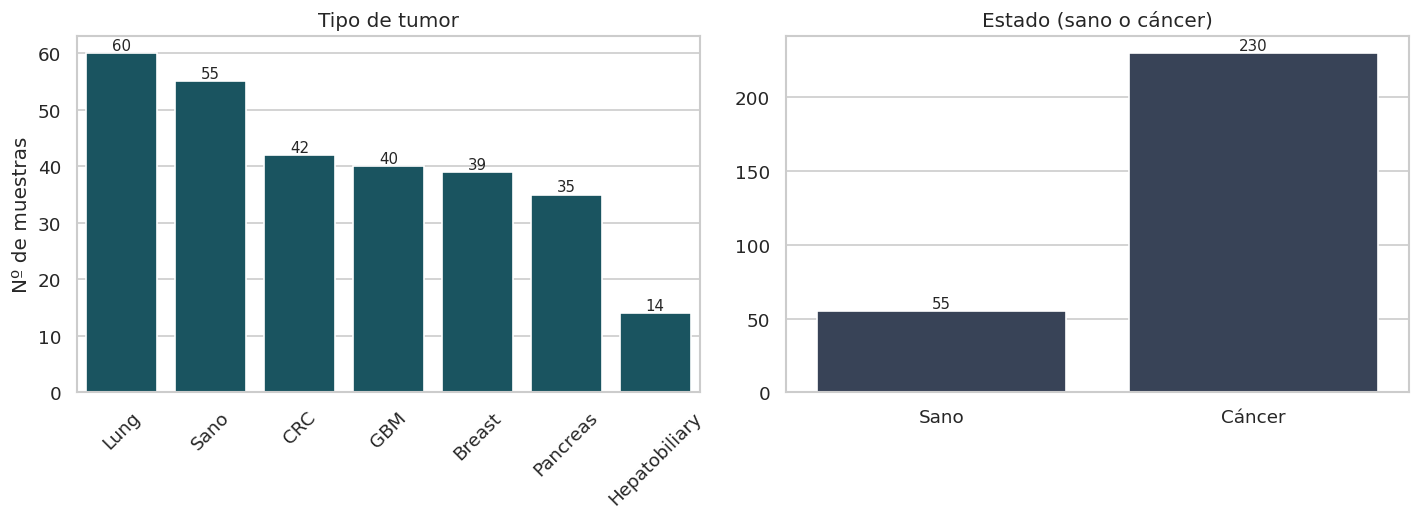

In [119]:
etiqueta_binaria = etiquetas.apply(lambda x: "Sano" if x == "Sano" else "Cáncer")

print("Distribución multiclase:")
print(etiquetas.value_counts(), "\n")
print("Distribución binaria:")
print(etiqueta_binaria.value_counts(), "\n")

# Razón entre la clase más frecuente y la menos frecuente
conteo = etiquetas.value_counts()
print(f"Razón de desbalance multiclase: {conteo.max() / conteo.min():.1f} a 1")
conteo_bin = etiqueta_binaria.value_counts()
print(f"Razón de desbalance binaria:    {conteo_bin.max() / conteo_bin.min():.1f} a 1")

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x=etiquetas, order=conteo.index, color=verde_azulado, ax=ejes[0])
ejes[0].set_title("Tipo de tumor")
ejes[0].set_xlabel(""); ejes[0].set_ylabel("Nº de muestras")
ejes[0].tick_params(axis="x", rotation=45)

sns.countplot(x=etiqueta_binaria, order=["Sano", "Cáncer"], color=azul_oscuro, ax=ejes[1])
ejes[1].set_title("Estado (sano o cáncer)")
ejes[1].set_xlabel(""); ejes[1].set_ylabel("")

for eje in ejes:
    for barra in eje.patches:
        eje.annotate(int(barra.get_height()),
                     (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()

Ambas tareas presentan un desbalance considerable y de magnitud parecida. En la tarea binaria, las 230 muestras de pacientes con cáncer cuadruplican a las 55 de individuos sanos. En la multiclase, el tipo más representado es el cáncer de pulmón, con 60 muestras, mientras que el hepatobiliar apenas tiene 14, lo que supone una razón de algo más de cuatro a uno entre la clase mayoritaria y la minoritaria.

Esta situación tiene dos consecuencias para el resto del trabajo.
- La primera afecta a la evaluación, ya que la exactitud global resultaría engañosa. Un modelo que clasificase todas las muestras como cáncer alcanzaría un 80% de aciertos sin haber aprendido nada útil, por lo que la comparación se debe apoyar en métricas que ponderan por igual a todas las clases.
- La segunda afecta al entrenamiento, porque los algoritmos tienden a favorecer a las categorías más frecuentes sin importar las minoritarias. Como no existe una estrategia correctora que funcione mejor en todos los casos, y las muestras sintéticas pueden introducir ruido en datos de alta dimensión, se compararán tres alternativas: no aplicar ninguna corrección, ponderar las clases durante el entrenamiento y generar muestras sintéticas mediante SMOTE.

La clase hepatobiliar necesita atención individual, ya que al tener solo 14 muestras, cualquier partición de los datos dejará muy pocos casos disponibles para su evaluación, por lo que las métricas correspondientes a esta categoría estarán sujetas a una variabilidad considerable y deberán analizarse con cuidado.

Antes de pasar a la siguiente fase, es necesario estudiar la existencia de réplicas.

El conjunto incluye al menos una muestra repetida, es decir, un mismo paciente secuenciado en dos ocasiones. Es necesario identificarla porque, si ambas quedasen repartidas entre entrenamiento y prueba, el modelo se evaluaría con información procedente de un individuo ya visto durante el aprendizaje.

In [120]:
replicas = [c for c in expr.columns if c.endswith("-1") and c[:-2] in expr.columns]
n_individuos = expr.shape[1] - len(replicas)

print("Columnas cuyo nombre acaba en -1:",
      len([c for c in expr.columns if c.endswith("-1")]))
print("De ellas, con la muestra base también presente:", len(replicas))
print("Réplica identificada:", replicas)
print(f"\nMuestras: {expr.shape[1]} | Individuos distintos: {n_individuos}")

Columnas cuyo nombre acaba en -1: 28
De ellas, con la muestra base también presente: 1
Réplica identificada: ['Lung-0020J-1']

Muestras: 285 | Individuos distintos: 284


El criterio se centra en los nombres del depósito de datos, que añade el sufijo -1 al identificador de la muestra repetida, y en la condición adicional de que exista la muestra base correspondiente. Esa segunda condición es la que resulta determinante, ya que en la mayoría de los casos el sufijo forma parte del identificador sin significar repetición, como ocurre en HD-2-1, para la que no existe ninguna muestra HD-2.

Un criterio basado en nombres depende, sin embargo, de la consistencia de quien depositó los datos, por lo que es necesario verificar la réplica a partir de los propios valores de expresión.

In [121]:
for col in ["Lung-0020J", "Lung-0020J-1"]:
    print(f"{col:15s} lecturas: {expr[col].sum():>12,.0f} | "
          f"ceros: {(expr[col] == 0).mean():.1%} | "
          f"genes detectados: {(expr[col] > 0).sum():,}")

Lung-0020J      lecturas:    5,054,795 | ceros: 82.4% | genes detectados: 10,170
Lung-0020J-1    lecturas:      592,866 | ceros: 87.3% | genes detectados: 7,344


Ambas muestras se diferencian en profundidad de secuenciación, con más de ocho veces de diferencia entre una y otra. La 'muestra repetición' (Lung-0020J-1) se sitúa además entre las muestras con menor número de lecturas de todo el conjunto, lo que condiciona cualquier comparación entre sus perfiles, ya que gran parte de los genes ausentes en la segunda no refleja una diferencia biológica, sino la falta de lecturas suficientes para detectarlos.

Por este motivo, la comparación se plantea partiendo de la muestra de menor profundidad, que es la que pone el límite, y se realiza sobre los genes con expresión detectable y en escala logarítmica, entendiendo por ellos los que alcanzan al menos una lectura por millón en catorce muestras o más.

Un cálculo previo sobre la matriz completa resultó poco concluyente, ya que los más de 40 mil genes con valor nulo en casi todas las muestras introducen ruido, el cual distorsiona el resultado.

In [122]:
# Filtrado y transformación provisionales solo para esta comprobación
cpm_tmp = expr / expr.sum(axis=0) * 1e6
genes_tmp = (cpm_tmp >= 1).sum(axis=1) >= 14
log_cpm = np.log2(cpm_tmp.loc[genes_tmp] + 1)

print(f"Genes con expresión detectable empleados en la comparación: " f"{genes_tmp.sum():,} de {expr.shape[0]:,}\n")

corr_filt = log_cpm.corr(method="pearson")
np.fill_diagonal(corr_filt.values, np.nan)

print("Correlación de la pareja:", f"{corr_filt.loc['Lung-0020J', 'Lung-0020J-1']:.3f}\n")
print("Cinco muestras más parecidas a Lung-0020J-1:")
print(corr_filt["Lung-0020J-1"].sort_values(ascending=False).head(5).to_string())

Genes con expresión detectable empleados en la comparación: 13,343 de 57,736

Correlación de la pareja: 0.927

Cinco muestras más parecidas a Lung-0020J-1:
Lung-0020J    0.927441
Lung-0040     0.891227
CRC-450       0.880331
Lung-0096     0.877633
Lung-0025J    0.873640


La muestra Lung-0020J es la más parecida a Lung-0020J-1, con una correlación de 0,927 frente al 0,891 de la siguiente muestra candidata, una diferencia que la separa con claridad del resto del conjunto. Las demás muestras próximas corresponden además, en su mayoría, a pacientes con cáncer de pulmón, lo que indica que el cálculo refleja estructura biológica y no ruido técnico.

Lo último que falta por comprobar para poder decir si son el mismo paciente es que los metadatos coincidan.


In [123]:
filas = metadatos["titulo"].isin(["Blood_Platelets_Lung-20", "Blood_Platelets_Lung-20-1"])
print(pd.concat([metadatos.loc[filas, ["titulo", "gsm"]],
                 caract_df.loc[filas]], axis=1).T.to_string())

                                      189                        190
titulo            Blood_Platelets_Lung-20  Blood_Platelets_Lung-20-1
gsm                            GSM1662723                 GSM1662724
caracteristica_0            tissue: blood              tissue: blood
caracteristica_1  cell type: Thrombocytes    cell type: Thrombocytes
caracteristica_2      patient id: Lung-20      patient id: Lung-20-1
caracteristica_3        cancer type: Lung          cancer type: Lung
caracteristica_4           batch: Batch02             batch: Batch02
caracteristica_5  mutational subclass: wt    mutational subclass: wt


Los metadatos respaldan la conclusión. Ambas muestras comparten tejido, tipo celular, tipo tumoral, subclase mutacional y lote de procesamiento, y sus identificadores en el repositorio son consecutivos. El campo de identificación del paciente las registra con valores distintos, de modo que el depósito no declara de forma explícita que correspondan al mismo individuo, aunque los nombres utilizados y la coincidencia del resto de características apuntan en esa dirección.

Las 285 muestras del conjunto corresponden, por tanto, a 284 individuos distintos.

Para llevar a cabo el resto del análisis, ambas secuenciaciones se mantendrán en el mismo lado de la partición, usando un criterio conservador que evita la fuga de información hacia el conjunto de evaluación y cuyo coste, en caso de no tratarse del mismo paciente, se limitaría a una única muestra.

## **Fase 2: preparación de los datos**

Objetivo del bloque: convertir la matriz en bruto en un conjunto listo para el modelado, cuidando en cada paso que no se filtre información del conjunto de evaluación. Para ello, se necesitan los siguientes pasos: filtrado de genes poco expresados, reorganización a formato de modelo (transposición de la matriz y separación de variables y objetivo), partición entre entrenamiento y prueba, normalización y estandarización, control de calidad de las muestras y preparación de las estrategias frente al desbalance.

*Nota:* todo cálculo que dependa de los datos, se ajustará únicamente con el conjunto de entrenamiento y se aplicará después al de prueba. La única excepción es el filtrado de genes, que se realiza sobre el conjunto completo para no utilizar en ningún momento las etiquetas de clase.

### **Filtrado de genes poco expresados**

El análisis exploratorio ha mostrado que la mayor parte de los genes apenas se detecta (44291 de los 57736 presentan valor cero en más del 90% de las muestras). Mantenerlos no aporta capacidad a los modelos, empeora el desajuste entre variables y muestras, y encarece todos los pasos posteriores.

El umbral debe fijarse de forma explícita, ya que la zona intermedia de la distribución impide un corte evidente. Por tanto, el criterio elegido para mantener un gen exigirá el cumplimiento de dos condiciones: que alcance al menos una lectura por millón, y que lo haga en un mínimo de catorce muestras. De esta forma, se descartan tanto los genes que alcanzan valores altos en muy pocas muestras como aquellos que, a pesar de aparecer con frecuencia, lo hacen siempre con niveles mínimos.

El hecho de elegir 14 muestras corresponde al tamaño del grupo menos representado, el hepatobiliar. Se escoge ese valor ya que un gen característico de un único tipo tumoral se expresaría únicamente en las muestras de ese grupo y en ninguna otra, y un umbral mayor lo eliminaría precisamente por ser específico, cuando se trata del tipo de gen que interesa conservar. Por debajo de esa cifra, en cambio, no existe ningún grupo que justifique la presencia del gen, por lo que su aparición se puede asociar al ruido técnico del proceso de secuenciación.

Además, el hecho de comparar en lecturas por millón y no en conteos brutos es que estos últimos dependen de la profundidad de secuenciación. Es decir, una muestra con 7 millones de lecturas presenta valores más elevados en todos sus genes que otra con 200 mil, sin que ello implique mayor expresión. Por esto, al expresar el umbral en proporción al total de cada muestra, la exigencia acaba siendo equivalente para todas.

Este filtro se aplica sobre el conjunto completo, antes de la partición. No existe, por tanto, riesgo de que el conjunto de evaluación influya en la decisión.

El caso de la selección de características es distinto, porque sí evalúa la relación de cada gen con la clase y deberá realizarse dentro de la validación cruzada.

In [124]:
# Conteos por millón, solo para decidir el filtro (los datos siguen en bruto)
cpm = expr / expr.sum(axis=0) * 1e6

umbral_cpm = 1
min_muestras = int(etiquetas.value_counts().min())   # 14, la clase minoritaria

genes_a_conservar = (cpm >= umbral_cpm).sum(axis=1) >= min_muestras
expr_filtrada = expr.loc[genes_a_conservar]

print(f"Criterio: al menos {umbral_cpm} CPM en {min_muestras} muestras o más\n")
print(f"Genes antes del filtrado: {expr.shape[0]:,}")
print(f"Genes tras el filtrado:   {expr_filtrada.shape[0]:,}")
print(f"Genes descartados:        {expr.shape[0] - expr_filtrada.shape[0]:,} "
      f"({1 - expr_filtrada.shape[0] / expr.shape[0]:.1%})")
print(f"\nDimensiones resultantes: {expr_filtrada.shape}")

Criterio: al menos 1 CPM en 14 muestras o más

Genes antes del filtrado: 57,736
Genes tras el filtrado:   13,343
Genes descartados:        44,393 (76.9%)

Dimensiones resultantes: (13343, 285)


El filtrado reduce la matriz de 57736 a 13343 genes, descartando 44393 variables (un 76,9 % del total).

Con esto, la dimensionalidad del problema disminuye, aunque, se mantiene la condición de que el número de variables sigue superando ampliamente al de muestras, con más de 13 mil genes frente a las 285 disponibles.

Se debe comprobar si alguna clase ha quedado infrarrepresentada tras esta eliminación de genes.

In [125]:
cpm_filtrada = cpm.loc[genes_a_conservar]
print("Genes detectados (CPM >= 1) por clase, mediana entre sus muestras:\n")
for clase in etiquetas.value_counts().index:
    columnas = etiquetas[etiquetas == clase].index
    detectados = (cpm_filtrada[columnas] >= umbral_cpm).sum(axis=0)
    print(f"  {clase:15s} {detectados.median():>7,.0f}")


Genes detectados (CPM >= 1) por clase, mediana entre sus muestras:

  Lung              6,664
  Sano              8,925
  CRC               6,766
  GBM               7,134
  Breast            7,176
  Pancreas          7,156
  Hepatobiliary     7,782


La comprobación por clases descarta que el criterio de selección de genes haya perjudicado a alguna categoría en particular. La mediana de genes detectados se sitúa entre 6664 y 8925 según el grupo, valores del mismo orden en todos los casos.

Se aprecia que el grupo hepatobiliar no queda desfavorecido, con 7782 genes detectados.

El grupo con mayor cantidad de genes detectados es el de los Sanos, ¿puede eso tener que ver con el número de lecturas por muestra?


In [126]:
print("Mediana de lecturas por muestra, según clase:\n")
for clase in etiquetas.value_counts().index:
    columnas = etiquetas[etiquetas == clase].index
    print(f"  {clase:15s} {expr[columnas].sum(axis=0).median():>12,.0f}")

Mediana de lecturas por muestra, según clase:

  Lung               2,043,704
  Sano               1,037,596
  CRC                2,329,392
  GBM                1,725,766
  Breast             2,394,606
  Pancreas           2,289,569
  Hepatobiliary      1,909,101



Se observa que las muestras de individuos sanos son las que menos lecturas acumulan por muestra, con una mediana de 1037596 frente a los más de 2 millones de algunos grupos tumorales, y sin embargo son las que mayor número de genes detectan.

La diferencia no puede asociarse, por tanto, a una secuenciación más profunda, sino que sugiere un perfil de expresión más repartido entre genes distintos, mientras que en las muestras tumorales una proporción mayor de las lecturas se concentra en un conjunto más reducido. Esto se trata de una observación exploratoria que no forma parte de los objetivos del trabajo y que es coherente con el fenómeno de educación plaquetaria tratado en la literatura del trabajo, según el cual la presencia del tumor altera el perfil transcripcional de la plaqueta.

### **Transposición y separación de variables y objetivo**

Los algoritmos de clasificación esperan que cada fila represente una observación y cada columna una variable.

Como la matriz de expresión sigue la dinámica contraria, debe transponerse. Tras la transposición, cada individuo queda representado por un vector de 13343 valores de expresión, uno por gen.

A esa matriz de variables se asocian dos variables objetivo distintas, correspondientes a las dos tareas planteadas. La primera es binaria y separa a los individuos sin cáncer de aquellos que lo padecen. La segunda es multiclase y distingue entre los seis tipos tumorales presentes en el conjunto; en esta segunda tarea las muestras de individuos sanos quedan excluidas, ya que el objetivo es diferenciar el origen del tumor en pacientes que ya han sido identificados como enfermos.

In [127]:
# Se transpone la matriz
X = expr_filtrada.T
X.index.name = "muestra"

# Tarea binaria: sano frente a cáncer (las 285 muestras)
y_binaria = etiquetas.apply(lambda x: "Sano" if x == "Sano" else "Cáncer")

# Tarea multiclase: tipo de tumor (solo las muestras de cáncer)
muestras_cancer = etiquetas[etiquetas != "Sano"].index
X_multiclase = X.loc[muestras_cancer]
y_multiclase = etiquetas.loc[muestras_cancer]

print(f"Matriz de variables (X): {X.shape[0]} muestras × {X.shape[1]:,} genes\n")

print("Tarea binaria:")
print(f"  X: {X.shape}")
print(y_binaria.value_counts().to_string(), "\n")

print("Tarea multiclase:")
print(f"  X: {X_multiclase.shape}")
print(y_multiclase.value_counts().to_string())

Matriz de variables (X): 285 muestras × 13,343 genes

Tarea binaria:
  X: (285, 13343)
tipo_tumor
Cáncer    230
Sano       55 

Tarea multiclase:
  X: (230, 13343)
tipo_tumor
Lung             60
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14


In [128]:
print("Índices alineados (binaria):   ", X.index.equals(y_binaria.index))
print("Índices alineados (multiclase):", X_multiclase.index.equals(y_multiclase.index))
print("Valores faltantes en X:        ", int(X.isna().sum().sum()))
print("\nPrimeras filas y columnas de X:")
print(X.iloc[:3, :4])

Índices alineados (binaria):    True
Índices alineados (multiclase): True
Valores faltantes en X:         0

Primeras filas y columnas de X:
                     ENSG00000000003  ENSG00000000419  ENSG00000000457  \
muestra                                                                  
3-Breast-Her2-ampl                 0               44               26   
8-Breast-WT                        0               14                1   
10-Breast-Her2-ampl                0               16               14   

                     ENSG00000000460  
muestra                               
3-Breast-Her2-ampl                81  
8-Breast-WT                       98  
10-Breast-Her2-ampl               18  


La matriz queda organizada en 285 filas, una por muestra, y 13343 columnas, una por gen.

La tarea binaria conserva las 285 muestras, con 230 casos de cáncer frente a 55 controles sanos, mientras que la multiclase trabaja solo con las 230 muestras tumorales: 60 de pulmón, 42 colorrectales, 40 glioblastomas, 39 de mama, 35 de páncreas y 14 hepatobiliares.

La ejecución de la segunda celda de código sirve para ver que los índices de la matriz de variables y de las etiquetas coinciden en ambas tareas y no hay valores ausentes.

### **Partición entre entrenamiento y prueba**

La comparación final entre modelos debe realizarse sobre datos que no hayan participado en el entrenamiento ni en el ajuste de hiperparámetros. Se reserva para ello un 20% de las muestras, proporción que deja suficientes casos para entrenar, dado lo reducido que es el conjunto de datos, y conserva un grupo de evaluación con un mínimo de representatividad. En la tarea multiclase esa cifra supone apenas tres muestras del grupo hepatobiliar, límite que se tiene que tener en cuenta al interpretar sus métricas.

La partición se estratifica por clase para que ninguna quede infrarrepresentada por azar. Además, las dos muestras del paciente Lung-0020J deben permanecer en el mismo lado, ya que, tal y como se ha mencionado antes, repartirlas supondría evaluar el modelo con información procedente de un individuo visto durante el entrenamiento.

In [129]:
# Para la tarea binaria
from sklearn.model_selection import train_test_split

replica = ["Lung-0020J", "Lung-0020J-1"]

# Se aparta la réplica antes de repartir y se devuelve después a entrenamiento
sin_replica = X.index.difference(replica)

X_ent_bin, X_pru_bin, y_ent_bin, y_pru_bin = train_test_split(
    X.loc[sin_replica], y_binaria.loc[sin_replica],
    test_size=0.20, stratify=y_binaria.loc[sin_replica], random_state=semilla)

X_ent_bin = pd.concat([X_ent_bin, X.loc[replica]])
y_ent_bin = pd.concat([y_ent_bin, y_binaria.loc[replica]])

print("Tarea binaria")
print(f"  Entrenamiento: {X_ent_bin.shape[0]} muestras")
print(y_ent_bin.value_counts().to_string())
print(f"\n  Prueba: {X_pru_bin.shape[0]} muestras")
print(y_pru_bin.value_counts().to_string())
print("\n¿El individuo estudiado dos veces aparece en el entrenamiento?", all(m in X_ent_bin.index for m in replica))

Tarea binaria
  Entrenamiento: 228 muestras
tipo_tumor
Cáncer    184
Sano       44

  Prueba: 57 muestras
tipo_tumor
Cáncer    46
Sano      11

¿El individuo estudiado dos veces aparece en el entrenamiento? True


In [130]:
# Para la tarea multiclase
sin_replica_multi = X_multiclase.index.difference(replica)

X_ent_multi, X_pru_multi, y_ent_multi, y_pru_multi = train_test_split(
    X_multiclase.loc[sin_replica_multi], y_multiclase.loc[sin_replica_multi],
    test_size=0.20, stratify=y_multiclase.loc[sin_replica_multi],
    random_state=semilla)

X_ent_multi = pd.concat([X_ent_multi, X_multiclase.loc[replica]])
y_ent_multi = pd.concat([y_ent_multi, y_multiclase.loc[replica]])

print("Tarea multiclase")
print(f"  Entrenamiento: {X_ent_multi.shape[0]} muestras")
print(y_ent_multi.value_counts().to_string())
print(f"\n  Prueba: {X_pru_multi.shape[0]} muestras")
print(y_pru_multi.value_counts().to_string())

print("\n¿El individuo estudiado dos veces aparece en el entrenamiento?", all(m in X_ent_multi.index for m in replica))

Tarea multiclase
  Entrenamiento: 184 muestras
tipo_tumor
Lung             48
CRC              34
GBM              32
Breast           31
Pancreas         28
Hepatobiliary    11

  Prueba: 46 muestras
tipo_tumor
Lung             12
CRC               8
GBM               8
Breast            8
Pancreas          7
Hepatobiliary     3

¿El individuo estudiado dos veces aparece en el entrenamiento? True


Se debe terminar comprobando que ninguna muestra ha quedado tanto en el entrenamiento como en el conjunto de prueba.

In [131]:
for nombre, ent, pru in [("binaria", X_ent_bin, X_pru_bin),
                         ("multiclase", X_ent_multi, X_pru_multi)]:
    solapamiento = set(ent.index) & set(pru.index)
    print(f"{nombre:12s} muestras compartidas entre conjuntos: {len(solapamiento)}")

binaria      muestras compartidas entre conjuntos: 0
multiclase   muestras compartidas entre conjuntos: 0


La partición guarda 57 muestras para la evaluación de la tarea binaria y 46 para la multiclase, manteniendo en ambos conjuntos proporciones equivalentes a las del conjunto completo. En ambas tareas, las dos secuenciaciones del paciente Lung-0020J quedan en el lado de entrenamiento, y ninguna muestra aparece a la vez en los dos conjuntos.

El reparto realizado es aleatorio, aunque sujeto a la condición de que cada clase conserve su proporción. Sin esa restricción, el azar podría dejar las categorías más pequeñas con poca representación o incluso ausentes del conjunto de evaluación, algo probable con solo 14 muestras hepatobiliares.

Sin embargo, este diseño tiene una limitación que es importante conocer. La comparación final se apoya en una única partición, de forma que los resultados dependen en cierta medida del reparto concreto obtenido. El caso más delicado es el del grupo hepatobiliar, que solo tiene tres muestras en el conjunto de prueba multiclase, por lo que un solo acierto o error modifica su sensibilidad en un tercio. Así, para valorar hasta qué punto las conclusiones dependen del reparto, la evaluación final se repetirá con varias semillas distintas, informando de la media y la dispersión de las métricas obtenidas. Por su parte, la selección de modelos se apoyará en la validación cruzada realizada sobre el conjunto de entrenamiento, donde cada muestra participará en varias evaluaciones.

### **Normalización y estandarización**

Como ya se ha dicho en los apartados anteriores, los conteos en bruto no son comparables entre muestras dado que la profundidad de secuenciación varía en más de 30 veces entre la muestra con menos lecturas y la que más tiene.

La técnica de corrección más habitual consiste en expresar cada valor en lecturas por millón, dividiendo por el total de la muestra. A esa escala se aplica después una transformación logarítmica, que comprime el rango de valores y disminuye el peso de los genes muy expresados, cuya distribución resultaba fuertemente asimétrica. Se suma una unidad antes de transformar para que los ceros no queden indefinidos.

Las dos operaciones anteriores trabajan con cada muestra por separado, usando solo sus valores, así que pueden aplicarse igual al conjunto de entrenamiento y al de prueba sin que haya riesgo de fuga de información.

Con la estandarización pasa lo contrario. Centrar y escalar cada gen exige calcular su media y su desviación típica sobre un conjunto de muestras, de manera que el resultado depende de qué muestras formen parte de ese cálculo. Por eso ambos estadísticos se obtienen únicamente con los datos de entrenamiento y se aplican después, tal cual, a los de prueba. Hacerlo de otra manera contaminaría la evaluación con información que el modelo no debería conocer.

In [132]:
def normalizar(matriz):
    cpm = matriz.div(matriz.sum(axis=1), axis=0) * 1e6
    return np.log2(cpm + 1)

X_ent_bin_norm = normalizar(X_ent_bin)
X_pru_bin_norm = normalizar(X_pru_bin)
X_ent_multi_norm = normalizar(X_ent_multi)
X_pru_multi_norm = normalizar(X_pru_multi)

print("Antes de normalizar (conteos brutos):")
print(f"  mínimo {X_ent_bin.to_numpy().min():,.0f} | "
      f"máximo {X_ent_bin.to_numpy().max():,.0f}")
print("\nDespués de normalizar (log2 de CPM + 1):")
print(f"  mínimo {X_ent_bin_norm.to_numpy().min():.2f} | "
      f"máximo {X_ent_bin_norm.to_numpy().max():.2f}")

# El total por muestra debe ser el mismo en todas tras pasar a CPM
totales_cpm = (X_ent_bin.div(X_ent_bin.sum(axis=1), axis=0) * 1e6).sum(axis=1)
print(f"\nTotal de CPM por muestra: mínimo {totales_cpm.min():,.0f} | "
      f"máximo {totales_cpm.max():,.0f}")

Antes de normalizar (conteos brutos):
  mínimo 0 | máximo 1,047,567

Después de normalizar (log2 de CPM + 1):
  mínimo 0.00 | máximo 18.22

Total de CPM por muestra: mínimo 1,000,000 | máximo 1,000,000


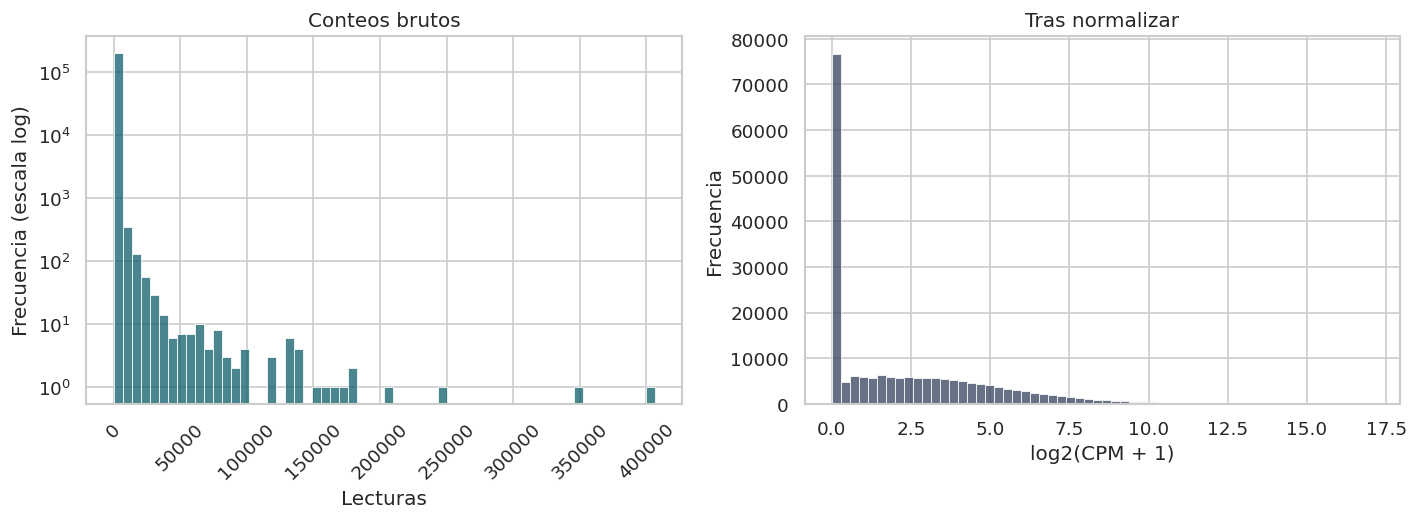

In [133]:
rng = np.random.default_rng(semilla)
muestra_bruta = rng.choice(X_ent_bin.to_numpy().ravel(), size=200_000, replace=False)
muestra_norm = rng.choice(X_ent_bin_norm.to_numpy().ravel(), size=200_000, replace=False)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(muestra_bruta, bins=60, color=verde_azulado, ax=ejes[0])
ejes[0].set_yscale("log")
ejes[0].set_title("Conteos brutos")
ejes[0].set_xlabel("Lecturas"); ejes[0].set_ylabel("Frecuencia (escala log)")
ejes[0].tick_params(axis='x', rotation=45)

sns.histplot(muestra_norm, bins=60, color=azul_oscuro, ax=ejes[1])
ejes[1].set_title("Tras normalizar")
ejes[1].set_xlabel("log2(CPM + 1)"); ejes[1].set_ylabel("Frecuencia")

plt.tight_layout(); plt.show()

In [134]:
from sklearn.preprocessing import StandardScaler

def estandarizar(entrenamiento, prueba):
    escalador = StandardScaler()
    ent = pd.DataFrame(escalador.fit_transform(entrenamiento),
                       index=entrenamiento.index, columns=entrenamiento.columns)
    pru = pd.DataFrame(escalador.transform(prueba),
                       index=prueba.index, columns=prueba.columns)
    return ent, pru, escalador

X_ent_bin_esc, X_pru_bin_esc, escalador_bin = estandarizar(
    X_ent_bin_norm, X_pru_bin_norm)
X_ent_multi_esc, X_pru_multi_esc, escalador_multi = estandarizar(
    X_ent_multi_norm, X_pru_multi_norm)

print("Entrenamiento tras estandarizar:")  # debe dar media 0 y desviación 1
print(f"  media {X_ent_bin_esc.to_numpy().mean():.3f} | "
      f"desviación {X_ent_bin_esc.to_numpy().std():.3f}")
print("\nPrueba tras aplicar la misma escala:") # no tiene por qué dar 0 y 1
print(f"  media {X_pru_bin_esc.to_numpy().mean():.3f} | "
      f"desviación {X_pru_bin_esc.to_numpy().std():.3f}")

Entrenamiento tras estandarizar:
  media 0.000 | desviación 1.000

Prueba tras aplicar la misma escala:
  media -0.018 | desviación 1.055


La normalización deja todas las muestras con un total de 1 millón de lecturas, lo que las hace comparables entre sí independientemente de su profundidad de secuenciación original. Los valores, que en bruto llegaban hasta 1047567 lecturas en una sola celda, pasan a moverse en un rango de 0 a 18,22 en escala logarítmica.

El valor de ese máximo, 18,22, equivale a unas 305000 lecturas por millón, de manera que un único gen concentra cerca del 30% de todas las lecturas de esa muestra. Esto es común en el transcriptoma plaquetario, donde unos pocos genes muy abundantes acaparan gran parte de la señal (sin la transformación logarítmica, esos genes dominarían por completo cualquier cálculo de distancias o de coeficientes).

Las gráficas muestran el cambio conseguido, se aprecia que la distribución de conteos brutos se concentra por completo junto al cero, con una cola tan larga que solo resulta visible representando la frecuencia en escala logarítmica. Tras normalizar, la distribución se despliega en un rango manejable, manteniendo el pico correspondiente a los valores nulos, pero el resto de la señal se distribuye de forma mucho más homogénea entre 0 y 18.

La estandarización deja el conjunto de entrenamiento con media 0 y desviación típica 1, tal como se esperaba. El conjunto de prueba, transformado con esos mismos parámetros, presenta una media de -0,018 y una desviación de 1,055. El hecho de que no coincidan exactamente con cero y uno es justamente la señal de que la escala no se ha recalculado con sus datos, ya que si lo hubiera hecho, el conjunto de evaluación habría influido en su propia transformación.

### **Control de calidad de las muestras**

En datos de expresión no tiene sentido buscar valores atípicos gen a gen, porque un valor muy alto suele reflejar actividad biológica real, no un error de medida, y la transformación logarítmica ya ha comprimido el rango. Lo que sí es recomendable detectar son muestras cuyo perfil se aparte del resto, ya que una secuenciación deficiente, un ARN degradado o un problema de procesamiento afectan a la muestra entera y no a valores sueltos.

La forma común de verlo es reducir cada muestra a unas pocas dimensiones mediante análisis de componentes principales (PCA) y observar su posición relativa. De esta forma se podrá comprobar si la principal fuente de variación responde a diferencias biológicas o a factores técnicos.

Este análisis se realiza solo sobre el conjunto de entrenamiento, para no obtener información del conjunto guardado para la evaluación.

In [135]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=semilla)
componentes = pca.fit_transform(X_ent_bin_esc)

varianza = pca.explained_variance_ratio_
print("Varianza explicada por componente:")
for i, v in enumerate(varianza[:5], start=1):
    print(f"  CP{i}: {v:.1%}")
print(f"\nAcumulada en 10 componentes: {varianza.sum():.2%}")

pca_df = pd.DataFrame(componentes[:, :2], index=X_ent_bin_esc.index,
                      columns=["CP1", "CP2"])
pca_df["clase"] = etiquetas.loc[pca_df.index]
pca_df["lecturas"] = X_ent_bin.sum(axis=1)

Varianza explicada por componente:
  CP1: 18.4%
  CP2: 5.9%
  CP3: 4.0%
  CP4: 2.2%
  CP5: 1.7%

Acumulada en 10 componentes: 37.67%


La primera componente recoge el 18,4% de la variación y la segunda el 5,9%, de forma que entre ambas explican menos de una cuarta parte del total y las diez primeras no alcanzan el 38%. La variación está, por tanto, muy repartida, algo común cuando se trabaja con miles de genes que responden a factores diversos.

Estas cifras no bastan para descartar la presencia de efectos técnicos, por lo que es necesario examinar la posición de las muestras según su tipo de tumor y su profundidad de secuenciación.

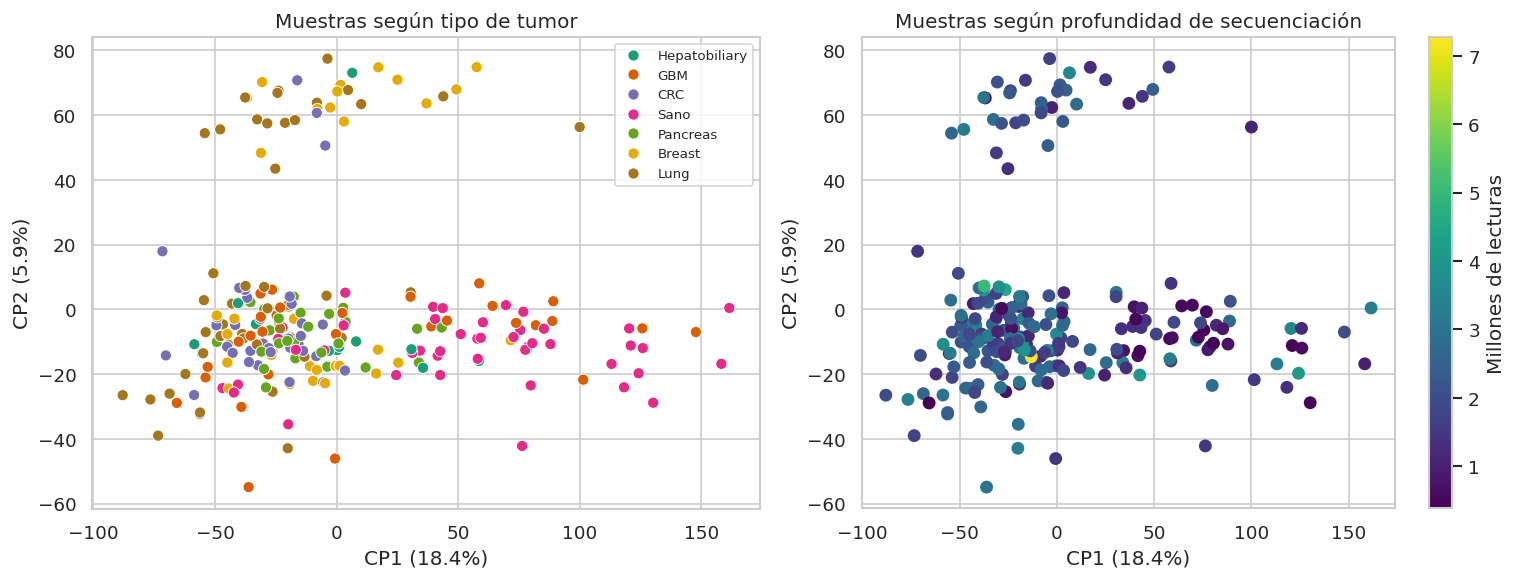

In [136]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=pca_df, x="CP1", y="CP2", hue="clase",
                palette="Dark2", s=45, ax=ejes[0])
ejes[0].set_title("Muestras según tipo de tumor")
ejes[0].set_xlabel(f"CP1 ({varianza[0]:.1%})")
ejes[0].set_ylabel(f"CP2 ({varianza[1]:.1%})")
ejes[0].legend(fontsize=8, title=None)

dispersion = ejes[1].scatter(pca_df["CP1"], pca_df["CP2"],
                             c=pca_df["lecturas"] / 1e6, cmap="viridis", s=45)
ejes[1].set_title("Muestras según profundidad de secuenciación")
ejes[1].set_xlabel(f"CP1 ({varianza[0]:.1%})")
ejes[1].set_ylabel(f"CP2 ({varianza[1]:.1%})")
plt.colorbar(dispersion, ax=ejes[1], label="Millones de lecturas")

plt.tight_layout(); plt.show()

La representación por profundidad enseña que muestras con menos de 1 millón de lecturas aparecen mezcladas con otras de más de 4 millones, lo que confirma que la normalización ha cumplido su función.

No obstante, en ambas gráficas aparece un grupo de muestras claramente separado en la parte superior, que no se explica por la profundidad ni corresponde a un único tipo de tumor. Es por esto que se necesita comprobar si esta separación está asociada al lote de procesamiento (es decir, aquellas registradas en la misma tanda del laboratorio).

In [137]:
lote_meta = caract_df.apply(lambda f: extraer_campo(f, "batch"), axis=1)
print("Lotes registrados en los metadatos:")
print(lote_meta.value_counts(dropna=False).to_string())

Lotes registrados en los metadatos:
Batch03    103
Batch04     87
Batch02     53
Batch06     30
Batch05     10
Batch01      2


In [138]:
# Índice código: todas las posiciones que lo comparten, con su clase.
# Se conservan todas porque 36 códigos aparecen en más de un título; quedarse solo con la última asignaría el lote de otra muestra sin previo aviso.
codigo_a_indices = defaultdict(list)
for i, (cod, cls) in enumerate(zip(metadatos["codigo"], metadatos["clase"])):
    codigo_a_indices[cod].append((i, cls))


lote_por_columna = {}
for col in X_ent_bin_esc.index:
    pista = pista_organo(col)
    if pista == "Sano":
        lote_por_columna[col] = None
        continue
    candidatos = codigo_a_indices.get(codigo_expr(col), [])
    coincidentes = [i for i, cls in candidatos if cls == pista]
    if len(coincidentes) == 1:
        lote_por_columna[col] = lote_meta.iloc[coincidentes[0]]
    elif len(candidatos) == 1:
        lote_por_columna[col] = lote_meta.iloc[candidatos[0][0]]
    else:
        lote_por_columna[col] = None

pca_df["lote"] = [lote_por_columna.get(m) for m in pca_df.index]

grupo_alto = pca_df["CP2"] > 40
print(f"Muestras separadas en la parte superior (CP2 > 40): {grupo_alto.sum()}\n")
print("Lote de esas muestras:")
print(pca_df.loc[grupo_alto, "lote"].value_counts(dropna=False).to_string())
print("\nClase de esas muestras:")
print(pca_df.loc[grupo_alto, "clase"].value_counts().to_string())

Muestras separadas en la parte superior (CP2 > 40): 33

Lote de esas muestras:
lote
Batch06    24
Batch05     9

Clase de esas muestras:
clase
Lung             16
Breast           13
CRC               3
Hepatobiliary     1


Antes de atribuir la separación al lote de procesamiento hay que descartar una explicación alternativa.

Las muestras no se reparten al azar entre tandas, cada una puede proceder de un centro distinto, con un perfil de pacientes propio, de manera que un lote podría concentrar unos tipos tumorales y no tener otros. Si fuese así, la separación observada respondería a la composición de clases del grupo y no a la variación técnica introducida durante el procesamiento.

Ambas explicaciones se distinguen mirando qué ocurre dentro de una misma clase. Si la separación se debiera a la composición, todas las muestras de un mismo tipo tumoral quedarían del mismo lado. Si responde al lote, aparecerán repartidas entre ambos grupos según la tanda en que se procesaron.

In [139]:
from scipy.stats import chi2_contingency

tabla_lote_clase = pd.crosstab(pca_df["lote"], pca_df["clase"])
print("Distribución de las clases entre lotes (conjunto de entrenamiento):\n")
print(tabla_lote_clase.to_string())

chi2, p, gl, esperado = chi2_contingency(tabla_lote_clase)
print(f"\nContraste de independencia: chi-cuadrado = {chi2:.1f}, gl = {gl}, p = {p:.3g}")
print("(varias casillas tienen frecuencias esperadas pequeñas, "
      "por lo que el valor p debe tomarse como orientativo)")

Distribución de las clases entre lotes (conjunto de entrenamiento):

clase    Breast  CRC  GBM  Hepatobiliary  Lung  Pancreas
lote                                                    
Batch01       0    0    1              0     0         0
Batch02       0    3    6              1    14         0
Batch03      11   16    5              7     4        16
Batch04       8   11    9              3    12         9
Batch05       6    1    0              0     2         0
Batch06       7    3    0              1    14         0

Contraste de independencia: chi-cuadrado = 80.4, gl = 25, p = 9.73e-08
(varias casillas tienen frecuencias esperadas pequeñas, por lo que el valor p debe tomarse como orientativo)


In [140]:
# Prueba para ver si el lote separa los elementos de una clase
for clase in ["Lung", "Breast"]:
    sub = pca_df[pca_df["clase"] == clase].copy()
    sub["grupo"] = np.where(sub["CP2"] > 40, "separado", "nube principal")
    print(f"\n{clase} ({len(sub)} muestras en entrenamiento):")
    print(pd.crosstab(sub["lote"].fillna("sin lote"), sub["grupo"]).to_string())


Lung (48 muestras en entrenamiento):
grupo     nube principal  separado
lote                              
Batch02               14         0
Batch03                4         0
Batch04               12         0
Batch05                0         2
Batch06                0        14
sin lote               2         0

Breast (32 muestras en entrenamiento):
grupo    nube principal  separado
lote                             
Batch03              11         0
Batch04               8         0
Batch05               0         6
Batch06               0         7


Los nombres de las muestras en la matriz de expresión tienen prefijos que identifican el centro de procedencia, lo que permite comprobar si el lote se corresponde con el hospital que aportó cada muestra.

In [141]:
def centro(nombre):
    if nombre.startswith("MGH"):
        return "MGH (Boston)"
    if nombre.startswith(("Vumc", "VU")):
        return "VU / Vumc (Ámsterdam)"
    return "sin prefijo de centro"

centros = pd.Series({m: centro(m) for m in pca_df.index}, name="centro")
print("Centro de procedencia frente a lote de procesamiento:\n")
print(pd.crosstab(centros, pca_df["lote"].fillna("sin lote")).to_string())

Centro de procedencia frente a lote de procesamiento:

lote                   Batch01  Batch02  Batch03  Batch04  Batch05  Batch06  sin lote
centro                                                                               
MGH (Boston)                 0        0        0        0        7       25         0
VU / Vumc (Ámsterdam)        1       11        5        0        2        0         9
sin prefijo de centro        0       13       54       52        0        0        49


Las 33 muestras del grupo separado pertenecen todas a Batch05 o Batch06: las 9 de Batch05 y 24 de las 25 de Batch06. La única excepción es una muestra de cáncer colorrectal de Batch06, que se queda en la nube principal.

La primera comprobación confirma que las clases no están repartidas al azar entre tandas, ya que Batch05 y Batch06 no incluyen ni un solo glioblastoma ni un solo caso de páncreas, mientras que Batch03 acumula 16 de páncreas y 16 colorrectales (la prueba estadística descarta que ese reparto sea aleatorio).

La duda se resuelve mirando qué pasa dentro de un mismo tipo de tumor. Si el grupo se separase por la clase, todas las muestras de pulmón deberían estar juntas, y esto no es lo que ocurre. De las 48 de pulmón, las 30 que se procesaron en Batch02, Batch03 y Batch04 (14, 4 y 12 respectivamente) están en la nube principal, junto a otras 2 de lote desconocido, y las 16 de Batch05 y Batch06 están en el grupo separado. Con el cáncer de mama pasa lo mismo, con sus 19 muestras de Batch03 y Batch04 en la nube y las 13 de Batch05 y Batch06 aparte. Muestras del mismo tumor caen a un lado o a otro según la tanda en que se procesaron, así que lo que las separa es el lote y no la enfermedad.

Queda por saber de dónde viene esa diferencia, y los nombres de las muestras dan la respuesta. Las 32 que llevan el prefijo MGH, del Massachusetts General Hospital, están todas en Batch05 o Batch06, y Batch06 no contiene ninguna otra. El resto de las muestras vienen del hospital de Ámsterdam.

Esos dos lotes recogen, entonces, las muestras que aportó el MGH, aunque Batch05 incluye además dos procedentes de Ámsterdam. Lo que separa a ese grupo son las diferencias de manipulación entre un laboratorio y otro.

Eso explica también por qué el lote da pistas sobre la clase. El centro de Boston envió 16 casos de pulmón, 13 de mama, 3 colorrectales y 1 hepatobiliar, y ningún control sano, ningún glioblastoma y ningún páncreas. Saber de qué tanda viene una muestra ya dice bastante sobre qué es, y un modelo podría aprender a reconocer el hospital en lugar del tumor, acertando por el motivo equivocado.

No se corrige el efecto justamente porque los métodos que existen para quitarlo dan por hecho que la tanda no guarda relación con lo que se quiere predecir, y aquí sí la guarda, así que al eliminar la diferencia técnica se llevarían por delante parte de la señal biológica. Se menciona la limitación y más adelante se comprueba si los genes en los que se apoya el modelo son los mismos que separan las tandas.

*Nota*: el lote solo puede asignarse a las muestras de cáncer. La matriz de expresión llama a los controles sanos HD-N o Control-N y los metadatos los llaman HC-N, con dos numeraciones que van por su cuenta y coinciden en ocho números, así que el número no basta para saber qué control es cada uno.

El efecto de lote afecta a un grupo entero de muestras, pero el control de calidad tiene un segundo objetivo, que es detectar casos aislados que se separen del conjunto por algún problema durante su procesamiento.

Se calcula entonces la distancia de cada muestra al centro de la nube, en las diez componentes principales.

In [142]:
# Distancia de cada muestra al centro de la nube, en las diez componentes
centro = componentes.mean(axis=0)
distancias = pd.Series(np.linalg.norm(componentes - centro, axis=1),
                       index=X_ent_bin_esc.index).sort_values(ascending=False)

umbral = distancias.mean() + 3 * distancias.std()
print(f"Umbral (media + 3 desviaciones típicas): {umbral:.1f}\n")

resumen = pd.DataFrame({
    "distancia": distancias.head(10).round(1),
    "clase": etiquetas.loc[distancias.head(10).index],
    "lecturas": X_ent_bin.sum(axis=1).loc[distancias.head(10).index],
})
print("Diez muestras más alejadas del centro:\n")
print(resumen.to_string())
print(f"\nMuestras por encima del umbral: {(distancias > umbral).sum()}")

Umbral (media + 3 desviaciones típicas): 152.6

Diez muestras más alejadas del centro:

                     distancia clase  lecturas
muestra                                       
HD-45-1                  178.0  Sano   3267506
VU280-GBM                174.8   GBM   1439266
HD-38-2                  163.0  Sano    989811
GBM-440                  154.9   GBM   1979592
GBM-486                  138.8   GBM   1177855
MGH-NSCLC-L12-TR478      138.2  Lung   1050839
HD-1                     138.1  Sano   1347946
HD-46-1                  137.9  Sano   4087549
HD-48-1                  136.3  Sano    448086
HD-51-1                  136.1  Sano    618318

Muestras por encima del umbral: 4


Cuatro muestras superan el umbral de tres desviaciones típicas respecto al centro de la nube: 2 controles sanos y 2 glioblastomas.

En el conjunto de las diez más alejadas, 6 son controles sanos y 3 glioblastomas, lo que apunta a una mayor variabilidad interna de esos dos grupos antes que a fallos técnicos. Tampoco se observa relación con la profundidad de secuenciación, ya que entre las diez figuran tanto muestras de apenas 448086 lecturas como otras que superan los 4 millones.

Ninguna muestra se elimina porque con 285 muestras disponibles cada caso cuenta, y descartar alguno a partir de una distancia calculada sobre componentes que explican poco más de un tercio de la variación, sería una decisión mal tomada.

El control de calidad deja, por tanto, dos conclusiones. La profundidad de secuenciación ya no condiciona la posición de las muestras, señal de que la normalización ha funcionado, y ninguna muestra individual presenta un comportamiento que justifique descartarla. La única fuente de variación técnica identificada es el lote de procesamiento, que se menciona como limitación y se retomará al examinar los genes en los que se apoyan las predicciones.

El análisis anterior se ha realizado sobre el conjunto de entrenamiento de la tarea binaria, que incluye muestras de todos los tipos tumorales además de los controles. Las conclusiones sobre calidad se pueden extender a la tarea multiclase, ya que tanto las muestras anómalas como el efecto de lote son propiedades de las muestras y no dependen de la etiqueta que se les asigne.

Sin embargo, es buena idea repetir la representación empleando únicamente las muestras tumorales, con la finalidad de comprobar si los seis tipos de tumor presentan alguna separación apreciable antes de aplicar ningún método de selección.

Varianza explicada (solo muestras tumorales):
  CP1: 14.1%
  CP2: 6.8%
  CP3: 4.3%


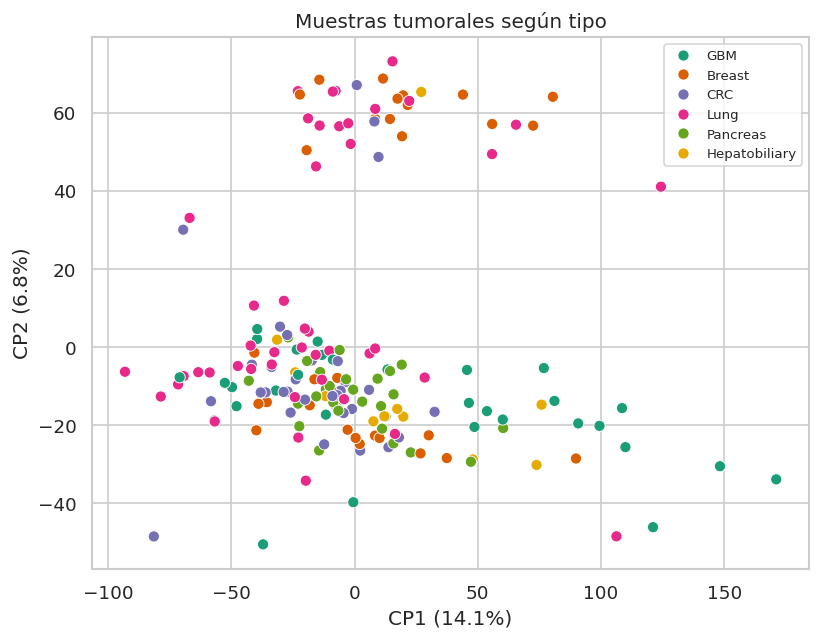

In [143]:
pca_multi = PCA(n_components=10, random_state=semilla)
comp_multi = pca_multi.fit_transform(X_ent_multi_esc)
var_multi = pca_multi.explained_variance_ratio_

pca_multi_df = pd.DataFrame(comp_multi[:, :2], index=X_ent_multi_esc.index,
                            columns=["CP1", "CP2"])
pca_multi_df["clase"] = y_ent_multi

print("Varianza explicada (solo muestras tumorales):")
for i, v in enumerate(var_multi[:3], start=1):
    print(f"  CP{i}: {v:.1%}")

plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=pca_multi_df, x="CP1", y="CP2", hue="clase",
                palette="Dark2", s=45)
plt.title("Muestras tumorales según tipo")
plt.xlabel(f"CP1 ({var_multi[0]:.1%})"); plt.ylabel(f"CP2 ({var_multi[1]:.1%})")
plt.legend(fontsize=8, title=None)
plt.tight_layout(); plt.show()

Al repetir el análisis solo con las 184 muestras tumorales del conjunto de entrenamiento, el resultado es que los seis tipos de tumor no se separan. En la nube central aparecen mezclados, de modo que dos muestras próximas en el gráfico pueden pertenecer a tumores distintos. Solo se aprecia una leve tendencia de las muestras de pulmón a colocarse hacia la izquierda, que no es suficiente para distinguirlas del resto. Además, vuelve a verse el grupo desplazado hacia arriba, que corresponde de nuevo a los lotes Batch05 y Batch06.

Las dos primeras componentes recogen aquí el 14,1% y el 6,8% de la variación, cifras algo menores que en el conjunto completo, lo que resulta lógico al haber excluido a los controles sanos, cuyo perfil era el más diferenciado.

Este resultado no invalida la tarea multiclase, pero muestra que será más difícil que la binaria, ya que las diferencias entre un cáncer de mama y uno de páncreas existen, pero afectan a unos pocos genes y quedan tapadas por la variación del resto. Por ello se necesitan aplicar métodos de selección de características antes del modelado, puesto que, a diferencia del análisis de componentes principales, estos sí utilizan las etiquetas y pueden localizar los genes que separan las clases, aunque su aportación a la variación total sea pequeña.

### **Preparación de las estrategias frente al desbalance de las clases**

Para el desbalance se comparan tres alternativas. La primera consiste en no aplicar ninguna corrección, y sirve de referencia para valorar si las demás aportan algo. La segunda pondera las clases durante el entrenamiento, penalizando más los errores cometidos sobre las categorías minoritarias sin modificar los datos. La tercera genera muestras sintéticas de las clases pequeñas mediante SMOTE, interpolando entre vecinos próximos.

Si el reequilibrado se aplicase antes de dividir los datos, las muestras sintéticas generadas a partir del conjunto de entrenamiento podrían acabar evaluándose como si fueran casos nuevos, y el rendimiento saldría inflado. Para evitarlo se emplea la estructura de flujo de imbalanced-learn, que aplica el remuestreo solo a la parte de entrenamiento de cada pliegue y deja intacta la de evaluación.

In [144]:
from imblearn.pipeline import Pipeline as PipelineDesbalance
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

def construir_flujo(modelo, estrategia):
    """Encadena escalado, reequilibrado (si procede) y modelo."""
    pasos = [("escalado", StandardScaler())]
    if estrategia == "smote":
        pasos.append(("remuestreo", SMOTE(random_state=semilla, k_neighbors=5)))
    pasos.append(("modelo", modelo))
    return PipelineDesbalance(pasos)

estrategias = ["ninguna", "ponderacion", "smote"]

In [145]:
# SMOTE genera muestras nuevas interpolando entre las vecinas más próximas de cada clase, por lo que una clase necesita al menos tantas muestras como vecinas se le pidan, más una.
# Dentro de la validación cruzada cada pliegue entrena con solo cuatro quintas partes de los datos, así que se comprueba que la clase más pequeña siga teniendo suficientes en ese caso.
n_pliegues = 5
k_vecinos = 5

for nombre, y in [("binaria", y_ent_bin), ("multiclase", y_ent_multi)]:
    minima = y.value_counts().min()
    clase_min = y.value_counts().idxmin()
    en_pliegue = int(minima * (n_pliegues - 1) / n_pliegues)
    print(f"{nombre:11s} clase menor: {clase_min} ({minima} muestras) -> "
          f"~{en_pliegue} al entrenar en cada pliegue "
          f"{'(suficiente)' if en_pliegue > k_vecinos else '(INSUFICIENTE)'}")

binaria     clase menor: Sano (44 muestras) -> ~35 al entrenar en cada pliegue (suficiente)
multiclase  clase menor: Hepatobiliary (11 muestras) -> ~8 al entrenar en cada pliegue (suficiente)


In [146]:
# Se muestra qué hace SMOTE sobre el conjunto de entrenamiento completo
muestreador = SMOTE(random_state=semilla, k_neighbors=5)

for nombre, X_datos, y in [("Binaria", X_ent_bin_norm, y_ent_bin),
                           ("Multiclase", X_ent_multi_norm, y_ent_multi)]:
    _, y_remuestreado = muestreador.fit_resample(X_datos, y)
    print(f"{nombre}:")
    print("  antes: ", y.value_counts().to_dict())
    print("  después:", pd.Series(y_remuestreado).value_counts().to_dict(), "\n")

Binaria:
  antes:  {'Cáncer': 184, 'Sano': 44}
  después: {'Cáncer': 184, 'Sano': 184} 

Multiclase:
  antes:  {'Lung': 48, 'CRC': 34, 'GBM': 32, 'Breast': 31, 'Pancreas': 28, 'Hepatobiliary': 11}
  después: {'GBM': 48, 'Breast': 48, 'CRC': 48, 'Lung': 48, 'Pancreas': 48, 'Hepatobiliary': 48} 



Las tres estrategias quedan preparadas junto con el escalado, de modo que todas las operaciones que dependen de los datos se recalculen en cada pliegue de la validación cruzada.

La comprobación previa confirma que SMOTE puede aplicarse en ambas tareas, siendo el caso más ajustado es el del grupo hepatobiliar, que con 11 muestras de entrenamiento conserva unas 8 en cada pliegue, suficientes para el método aunque con margen pequeño.

El efecto del remuestreo equipara todas las clases a la más numerosa. En la tarea binaria los 44 controles sanos crecen hasta los 184 casos de cáncer, y en la multiclase todas las categorías alcanzan las 48 muestras de la clase de pulmón. Esto supone que más de tres cuartas partes de las muestras de los pacientes con cáncer hepatobiliar pasarían a ser sintéticas, construidas a partir de 11 casos reales. Por esto, no se puede afirmar que este método sea beneficioso, ya que interpolar entre tan pocos ejemplos en un espacio de más de 13 mil dimensiones puede añadir más ruido que información.

## **Fase 3: modelado**

Objetivo del bloque: reducir el número de variables mediante selección de características, comparar cinco algoritmos de clasificación cruzados con las tres estrategias frente al desbalance, y afinar los hiperparámetros de las combinaciones con más potencial.

*Nota:* la selección de características utiliza las etiquetas, por lo que se realiza dentro de cada pliegue de la validación cruzada y nunca sobre el conjunto completo.

### **Selección de características**

Quedan 13343 genes, de manera que el desajuste entre dimensiones sigue siendo la principal dificultad. El filtrado de la fase anterior eliminó los genes sin expresión detectable, pero no distingue cuáles resultan útiles para separar las clases.

Esa distinción necesita comparar cada gen con la etiqueta, lo que convierte la selección en un paso supervisado y obliga a realizarla dentro de la validación cruzada. Si se hiciera antes, sobre todo el conjunto de entrenamiento, los genes elegidos se habrían escogido sabiendo cómo se comportan en las muestras que después servirán para evaluar cada pliegue, y el rendimiento resultaría optimista.

El método usado es un filtro univariante que ordena los genes según el estadístico F del análisis de varianza, midiendo hasta qué punto cada uno separa las medias de las clases. Se ha escogido por su bajo coste de cálculo, que es necesario al tener que repetirse en cada pliegue y para cada combinación de la rejilla. El número de genes a conservar no se fija de antemano, sino que se prueban varios valores y se decide con los resultados.

In [147]:
from sklearn.feature_selection import SelectKBest, f_classif

def construir_flujo(modelo, estrategia, k_genes):
    "Encadena escalado, selección de genes, reequilibrado y modelo."
    pasos = [("escalado", StandardScaler()),
             ("seleccion", SelectKBest(f_classif, k=k_genes))]
    if estrategia == "smote":
        pasos.append(("remuestreo", SMOTE(random_state=semilla, k_neighbors=5)))
    pasos.append(("modelo", modelo))
    return PipelineDesbalance(pasos)

Para decidir cuántos genes se conservan, se prueban varios valores y se compara el rendimiento obtenido mediante validación cruzada. La exploración se realiza con regresión logística y sin corrección del desbalance, ya que su finalidad es conseguir un rango razonable y no comparar modelos (cruzar el número de genes con las 15 combinaciones de la rejilla multiplicaría el coste sin aportar información útil).

En la tarea binaria se incluye además el conjunto completo de 13343 genes, que equivale a no seleccionar y sirve como referencia para saber si la selección aporta algo.

In [148]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

# En la binaria se llega hasta el total de genes; en la multiclase no es necesario, ya que el rendimiento no crece a partir de unos pocos miles.
exploracion = {
    "binaria":    (X_ent_bin_norm,   y_ent_bin,   [50, 100, 250, 500, 1000, 2000, 5000, 10000, 13343]),
    "multiclase": (X_ent_multi_norm, y_ent_multi, [50, 100, 250, 500, 1000, 2000, 5000]),
}

resultados_k = []
for tarea, (X_datos, y, valores_k) in exploracion.items():
    for k in valores_k:
        flujo = construir_flujo(
            LogisticRegression(max_iter=2000, random_state=semilla),
            estrategia="ninguna", k_genes=k)
        p = cross_val_score(flujo, X_datos, y, cv=cv,
                            scoring="balanced_accuracy", n_jobs=-1)
        resultados_k.append({"tarea": tarea, "k": k,
                             "media": p.mean(), "desviacion": p.std()})

tabla_k = pd.DataFrame(resultados_k)

for tarea in exploracion:
    sub = tabla_k[tabla_k["tarea"] == tarea]
    print(f"{tarea.upper()}")
    print(sub[["k", "media", "desviacion"]].round(3).to_string(index=False), "\n")

BINARIA
    k  media  desviacion
   50  0.814       0.052
  100  0.819       0.032
  250  0.812       0.054
  500  0.861       0.076
 1000  0.853       0.088
 2000  0.889       0.072
 5000  0.898       0.069
10000  0.917       0.053
13343  0.917       0.056 

MULTICLASE
   k  media  desviacion
  50  0.476       0.085
 100  0.528       0.073
 250  0.557       0.071
 500  0.565       0.055
1000  0.576       0.059
2000  0.529       0.109
5000  0.558       0.135 



Las cifras obtenidas presentan una dispersión considerable entre pliegues, de modo que las diferencias pequeñas entre configuraciones cercanas podrían deberse al azar. Para distinguir qué tendencias son reales, la exploración se ha repetido con una partición distinta, y si el orden entre configuraciones se mantiene, la diferencia es consistente, pero si se invierte, se trata de ruido.

In [149]:
cv_alternativa = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla + 1)

verificacion = {
    "binaria":    (X_ent_bin_norm,   y_ent_bin,   [1000, 5000, 13343]),
    "multiclase": (X_ent_multi_norm, y_ent_multi, [500, 1000, 2000]),
}

for tarea, (X_datos, y, valores_k) in verificacion.items():
    print(f"{tarea.upper()} (segunda partición)")
    for k in valores_k:
        flujo = construir_flujo(
            LogisticRegression(max_iter=2000, random_state=semilla),
            estrategia="ninguna", k_genes=k)
        p = cross_val_score(flujo, X_datos, y, cv=cv_alternativa,
                            scoring="balanced_accuracy", n_jobs=-1)
        print(f"  k={k:6d}  {p.mean():.3f} ± {p.std():.3f}")
    print()

BINARIA (segunda partición)
  k=  1000  0.850 ± 0.130
  k=  5000  0.878 ± 0.120
  k= 13343  0.903 ± 0.100

MULTICLASE (segunda partición)
  k=   500  0.596 ± 0.089
  k=  1000  0.570 ± 0.074
  k=  2000  0.586 ± 0.075



Se observan dos comportamientos distintos según la tarea.

- En la binaria, el rendimiento aumenta de forma sostenida a medida que se conservan más genes, desde 0,814 con cincuenta hasta 0,917 con el conjunto completo, sin que aparezca ningún máximo intermedio. El orden entre configuraciones se mantiene al repetir la validación cruzada con una partición distinta, de modo que el filtro univariante no localiza ningún subconjunto que supere al total.

- En la multiclase el comportamiento es otro. Los valores comprendidos entre 500 y 2000 genes son similares, siendo la selección de 1000 la que mejores resultados consigue. Al repetir la validación cruzada con otra partición, el orden entre esas configuraciones se invierte por completo, lo que confirma que las diferencias observadas responden a la variabilidad y no a una ventaja real de ninguna de ellas. Solo se puede afirmar que con cincuenta genes el rendimiento es claramente inferior.

Por tanto, se fijan 5000 genes para la tarea binaria y 1000 para la multiclase. La decisión no se apoya en una mejora del rendimiento, que no se produce en ningún caso, sino en dos razones: la primera es práctica, ya que la rejilla de 15 combinaciones debe entrenarse repetidamente y reducir el número de variables abarata el cálculo; la segunda es que para identificar los genes característicos de cada tipo de cáncer se necesita acotar el conjunto a un tamaño interpretable.

La selección cumple entonces una función de prefiltrado, mientras que la reducción a una firma génica se llevará a cabo al final del trabajo.

In [150]:
# Valores de prefiltrado que se emplearán en la rejilla de la fase siguiente
k_binaria = 5000
k_multiclase = 1000

### **Comparación de la rejilla de combinaciones**

La parte central del trabajo es la comparación de 5 algoritmos cruzados con las 3 estrategias frente al desbalance, lo que da lugar a 15 combinaciones por tarea. Todas se evalúan sobre los mismos datos, con la misma partición de validación cruzada y las mismas métricas, de modo que las diferencias observadas se deban a la combinación y no al procedimiento.

Esta primera comparación usa los hiperparámetros por defecto de cada algoritmo. Su finalidad no es obtener el mejor resultado posible, sino descartar las combinaciones que quedan claramente por detrás antes de afinarlas. El ajuste se realizará solo en aquellas que hayan demostrado ser mejores.

Es importante saber que la ponderación de clases no está disponible de la misma manera en todos los algoritmos. La regresión logística, la máquina de vectores soporte y el bosque aleatorio admiten un parámetro que reequilibra el peso de cada clase durante el entrenamiento. Sin embargo, los k vecinos más próximos no lo tienen, por lo que se usa en su lugar el ponderado por distancia, alternativa que favorece a las muestras cercanas y disminuye en parte el dominio de la clase mayoritaria, aunque no resulta equivalente. Además, el gradient boosting asigna pesos a cada muestra en función de la frecuencia de su clase.

In [151]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

def crear_modelo(nombre, estrategia):
    """Devuelve el modelo configurado según la estrategia de desbalance."""
    ponderar = (estrategia == "ponderacion")
    if nombre == "regresion_logistica":
        return LogisticRegression(max_iter=2000, random_state=semilla,
                                  class_weight="balanced" if ponderar else None)
    if nombre == "knn":
        # No admite ponderación de clases; se usa el ponderado por distancia
        return KNeighborsClassifier(weights="distance" if ponderar else "uniform")
    if nombre == "svm":
        return SVC(random_state=semilla, probability=True,
                   class_weight="balanced" if ponderar else None)
    if nombre == "random_forest":
        return RandomForestClassifier(random_state=semilla, n_jobs=-1,
                                      class_weight="balanced" if ponderar else None)
    if nombre == "xgboost":
        # La ponderación se aplica por muestra en el momento de entrenar
        return XGBClassifier(random_state=semilla, n_jobs=-1,
                             eval_metric="logloss", verbosity=0)

modelos = ["regresion_logistica", "knn", "svm", "random_forest", "xgboost"]
estrategias = ["ninguna", "ponderacion", "smote"]

Cada combinación se evalúa mediante validación cruzada estratificada de 5 pliegues sobre el conjunto de entrenamiento. Y, se registran varias métricas a la vez: la exactitud balanceada, que da el mismo peso a cada clase y sirve de criterio principal; la puntuación F1 promediada por clase; y el área bajo la curva ROC, que resume la capacidad de separación independientemente del umbral escogido.

In [152]:
from sklearn.model_selection import cross_validate
import time

def evaluar_rejilla(X_datos, y, k_genes, multiclase):
    codificador = LabelEncoder()
    y_cod = pd.Series(codificador.fit_transform(y), index=y.index)

    metricas = ["balanced_accuracy", "f1_macro",
                "roc_auc_ovr" if multiclase else "roc_auc"]
    filas = []
    for nombre in modelos:
        for estrategia in estrategias:
            inicio = time.time()
            flujo = construir_flujo(crear_modelo(nombre, estrategia),
                                    estrategia, k_genes)
            # XGBoost necesita etiquetas numéricas; el resto acepta ambas
            objetivo = y_cod if nombre == "xgboost" else y
            ajuste = {}
            if nombre == "xgboost" and estrategia == "ponderacion":
                ajuste["modelo__sample_weight"] = compute_sample_weight("balanced", y_cod)

            resultado = cross_validate(flujo, X_datos, objetivo, cv=cv,
                                       scoring=metricas, n_jobs=-1,
                                       params=ajuste if ajuste else None)
            filas.append({
                "modelo": nombre, "estrategia": estrategia,
                "exactitud_balanceada": resultado["test_balanced_accuracy"].mean(),
                "desviacion": resultado["test_balanced_accuracy"].std(),
                "f1_macro": resultado["test_f1_macro"].mean(),
                "auc": resultado[f"test_{metricas[2]}"].mean(),
                "segundos": time.time() - inicio,
            })
            print(f"  {nombre:20s} {estrategia:12s} "
                  f"{filas[-1]['exactitud_balanceada']:.3f} "
                  f"({filas[-1]['segundos']:.0f}s)")
    return pd.DataFrame(filas), codificador

print("TAREA BINARIA")
rejilla_bin, cod_bin = evaluar_rejilla(X_ent_bin_norm, y_ent_bin, k_binaria, False)
print("\nTAREA MULTICLASE")
rejilla_multi, cod_multi = evaluar_rejilla(X_ent_multi_norm, y_ent_multi,
                                           k_multiclase, True)

TAREA BINARIA
  regresion_logistica  ninguna      0.898 (2s)
  regresion_logistica  ponderacion  0.917 (2s)
  regresion_logistica  smote        0.917 (3s)
  knn                  ninguna      0.634 (3s)
  knn                  ponderacion  0.634 (3s)
  knn                  smote        0.882 (2s)
  svm                  ninguna      0.838 (3s)
  svm                  ponderacion  0.851 (4s)
  svm                  smote        0.870 (7s)
  random_forest        ninguna      0.835 (4s)
  random_forest        ponderacion  0.830 (4s)
  random_forest        smote        0.856 (8s)
  xgboost              ninguna      0.876 (19s)
  xgboost              ponderacion  0.879 (22s)
  xgboost              smote        0.870 (39s)

TAREA MULTICLASE
  regresion_logistica  ninguna      0.576 (2s)
  regresion_logistica  ponderacion  0.579 (2s)
  regresion_logistica  smote        0.576 (2s)
  knn                  ninguna      0.461 (2s)
  knn                  ponderacion  0.497 (2s)
  knn                  sm

In [153]:
for nombre, tabla in [("BINARIA", rejilla_bin), ("MULTICLASE", rejilla_multi)]:
    print(f"{nombre} — ordenada por exactitud balanceada y, en caso de empate, por AUC\n")
    print(tabla.sort_values(["exactitud_balanceada", "auc"], ascending=False)
          .round(3).to_string(index=False), "\n")

BINARIA — ordenada por exactitud balanceada y, en caso de empate, por AUC

             modelo  estrategia  exactitud_balanceada  desviacion  f1_macro   auc  segundos
regresion_logistica       smote                 0.917       0.056     0.921 0.978     3.488
regresion_logistica ponderacion                 0.917       0.056     0.921 0.975     2.154
regresion_logistica     ninguna                 0.898       0.069     0.911 0.978     2.336
                knn       smote                 0.882       0.040     0.797 0.926     2.264
            xgboost ponderacion                 0.879       0.066     0.873 0.960    21.810
            xgboost     ninguna                 0.876       0.069     0.882 0.968    18.606
            xgboost       smote                 0.870       0.077     0.870 0.964    39.416
                svm       smote                 0.870       0.062     0.867 0.952     7.224
      random_forest       smote                 0.856       0.075     0.854 0.940     7.778
     

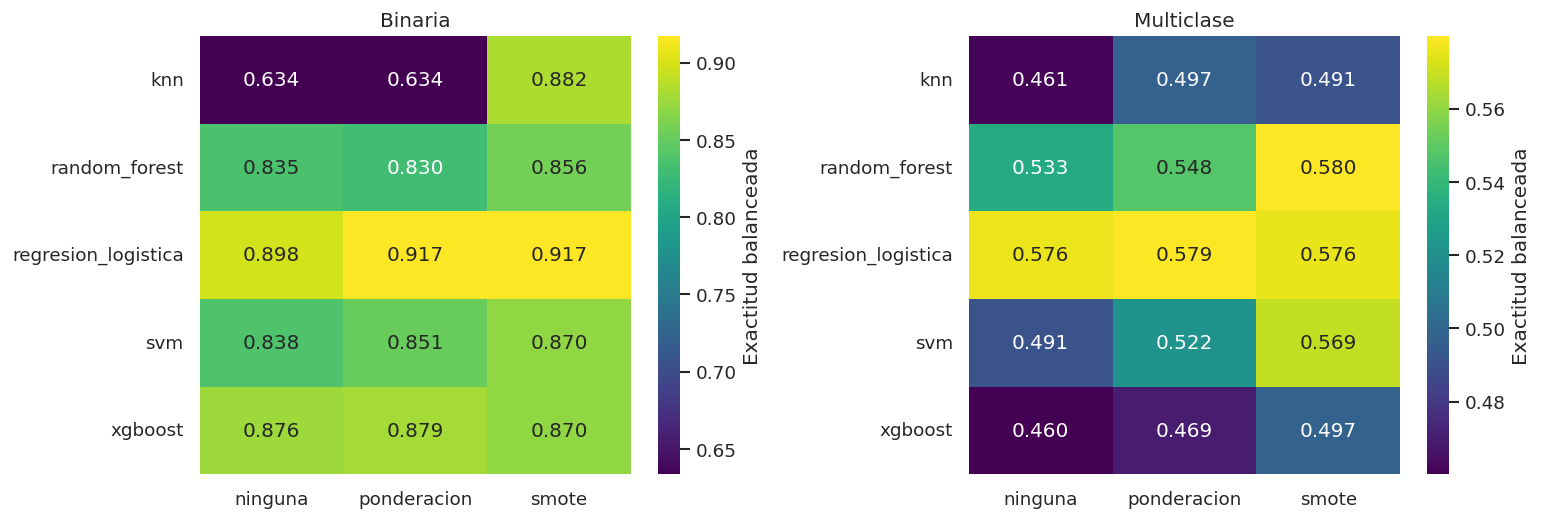

In [154]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
for eje, (nombre, tabla) in zip(ejes, [("Binaria", rejilla_bin),
                                       ("Multiclase", rejilla_multi)]):
    matriz = tabla.pivot(index="modelo", columns="estrategia",
                         values="exactitud_balanceada")
    sns.heatmap(matriz, annot=True, fmt=".3f", cmap="viridis", ax=eje,
                cbar_kws={"label": "Exactitud balanceada"})
    eje.set_title(nombre); eje.set_xlabel(""); eje.set_ylabel("")
plt.tight_layout(); plt.show()

En la tarea binaria la regresión logística se coloca como ganadora con diferencia, alcanzando una exactitud balanceada de 0,917 tanto con ponderación de clases como con SMOTE, frente al 0,879 si no se usa ninguna técnica frente al desbalance. El resultado coincide con el obtenido por Jopek et al. (2024) sobre datos de la misma naturaleza, donde un modelo lineal sencillo superó a métodos considerablemente más complejos.

Las dos variantes de la regresión logística quedan empatadas en la métrica principal y se diferencian en 0,003 de área bajo la curva, que es irrelevante frente a una desviación típica de 0,056 entre pliegues. Por esto, aplicar corrección del desbalance sí aporta algo respecto a no aplicarla, aunque la mejora, de 0,02, tampoco resulta concluyente por sí sola.

El método de los k vecinos más próximos queda en último lugar con una diferencia notable, con 0,634 sin remuestreo frente al 0,882 que alcanza al aplicar SMOTE. Esto ocurre porque con miles de variables, las distancias entre muestras tienden a igualarse y el criterio de proximidad pierde capacidad discriminativa. Ese mismo fenómeno explica que ponderar los vecinos por distancia no modifique ningún resultado en la tarea binaria, ya que los pesos apenas cambian cuando todas las distancias son parecidas; en la multiclase, con más clases en juego, sí produce un efecto más notable.

La tarea multiclase presenta una situación distinta. Los valores son considerablemente inferiores, con un máximo de 0,580 para el random forest con SMOTE, seguido de la regresión logística con 0,579 y 0,576. Las diferencias entre las tres primeras combinaciones son de milésimas y quedan muy por debajo de sus desviaciones típicas, que varían entre 0,058 y 0,101, de modo que no puede afirmarse que ninguna supere a las demás.

Es importante señalar que la regresión logística presenta la menor dispersión de todas ellas, lo que indica un comportamiento más estable entre particiones.

Por último, destaca que el remuestreo mediante SMOTE resulta beneficioso en la mayoría de combinaciones de la tarea multiclase, mientras que en la binaria su efecto es menor, salvo en los k vecinos más próximos, donde es determinante.

El número de combinaciones que pasan al ajuste de hiperparámetros no se fija a ojo, sino que se escoge en función de la dispersión de los resultados.

Se calcula el error estándar de la mejor combinación, dividiendo su desviación típica entre la raíz del número de pliegues, y se conservan todas aquellas cuya media se sitúe dentro de esa distancia. Esto se basa en que, a menos de un error estándar de diferencia, no se puede afirmar que una combinación sea peor que otra, de manera que descartarla supondría dar por buena una diferencia que los datos no sostienen.

A este criterio se le añade un detalle: tiene que haber un mínimo de 4 combinaciones, para garantizar que la comparación final no quede extremadamente reducida.

In [155]:
def seleccionar_candidatos(tabla, n_pliegues=5, maximo_por_modelo=3, minimo=4):
    """Combinaciones dentro de un error estándar de la mejor, con tope por
    algoritmo para evitar afinar el mismo modelo repetidamente."""
    tabla = tabla.copy()
    tabla["error_estandar"] = tabla["desviacion"] / np.sqrt(n_pliegues)
    mejor = tabla["exactitud_balanceada"].max()
    umbral = mejor - tabla.loc[tabla["exactitud_balanceada"].idxmax(), "error_estandar"]

    ordenada = tabla.sort_values("exactitud_balanceada", ascending=False)
    dentro = ordenada[ordenada["exactitud_balanceada"] >= umbral]

    # Tope por algoritmo
    elegidas = dentro.groupby("modelo").head(maximo_por_modelo)

    # Si quedan menos del mínimo, se completa con las siguientes mejores
    if len(elegidas) < minimo:
        resto = ordenada.drop(elegidas.index)
        resto = resto.groupby("modelo").head(maximo_por_modelo)
        elegidas = pd.concat([elegidas, resto.head(minimo - len(elegidas))])

    print(f"Mejor: {mejor:.3f} | umbral (un error estándar): {umbral:.3f}")
    print(f"Dentro del umbral: {len(dentro)} | seleccionadas: {len(elegidas)}\n")
    return elegidas.sort_values("exactitud_balanceada", ascending=False)

print("BINARIA")
candidatos_bin = seleccionar_candidatos(rejilla_bin)
print(candidatos_bin[["modelo", "estrategia", "exactitud_balanceada",
                      "desviacion"]].round(3).to_string(index=False))

print("\nMULTICLASE")
candidatos_multi = seleccionar_candidatos(rejilla_multi)
print(candidatos_multi[["modelo", "estrategia", "exactitud_balanceada",
                        "desviacion"]].round(3).to_string(index=False))

BINARIA
Mejor: 0.917 | umbral (un error estándar): 0.892
Dentro del umbral: 3 | seleccionadas: 4

             modelo  estrategia  exactitud_balanceada  desviacion
regresion_logistica ponderacion                 0.917       0.056
regresion_logistica       smote                 0.917       0.056
regresion_logistica     ninguna                 0.898       0.069
                knn       smote                 0.882       0.040

MULTICLASE
Mejor: 0.580 | umbral (un error estándar): 0.534
Dentro del umbral: 6 | seleccionadas: 6

             modelo  estrategia  exactitud_balanceada  desviacion
      random_forest       smote                 0.580       0.101
regresion_logistica ponderacion                 0.579       0.058
regresion_logistica     ninguna                 0.576       0.059
regresion_logistica       smote                 0.576       0.059
                svm       smote                 0.569       0.122
      random_forest ponderacion                 0.548       0.102


### **Ajuste de hiperparámetros**

Las combinaciones seleccionadas se han evaluado hasta ahora con los valores por defecto de cada algoritmo. Queda comprobar si un ajuste de sus parámetros modifica el orden o mejora el rendimiento de alguna de ellas.

La búsqueda se realiza mediante validación cruzada sobre el conjunto de entrenamiento, con la misma partición empleada en la comparación anterior, de modo que los resultados sean directamente comparables. Se va a realizar una búsqueda exhaustiva, que prueba todas las combinaciones de la rejilla definida para cada algoritmo; el número de candidatos es reducido y las rejillas se han mantenido acotadas, por lo que el coste computacional se ha reducido.

Las rejillas se limitan a los parámetros que dan complejidad al modelo, que son los que más influyen en el equilibrio entre sesgo y varianza. En la regresión logística se explora la fuerza de la regularización y su tipo, contrastando la penalización L2, que reduce todos los coeficientes de forma proporcional, con la L1, que anula los correspondientes a las variables menos útiles y realiza así una selección dentro del propio entrenamiento (esta última resulta interesante más allá del rendimiento, ya que produce modelos más sencillos de interpretar); en los k vecinos más próximos, el número de vecinos y la métrica de distancia; en la máquina de vectores soporte, el margen y la amplitud del núcleo; y en el bosque aleatorio, el número de árboles, su profundidad y el número de variables consideradas en cada división.



In [156]:
from sklearn.model_selection import GridSearchCV

# Los nombres van prefijados con "modelo__" porque el algoritmo es un paso
# dentro del flujo que incluye escalado, selección y remuestreo.
rejillas = {
    "regresion_logistica": {"modelo__C": [0.01, 0.1, 1, 10, 100],
                            "modelo__penalty": ["l2", "l1"],
                            "modelo__solver": ["liblinear"]},
    "knn": {"modelo__n_neighbors": [3, 5, 7, 11, 15],
            "modelo__p": [1, 2]},
    "svm": {"modelo__C": [0.1, 1, 10, 100],
            "modelo__gamma": ["scale", 0.001, 0.01]},
    "random_forest": {"modelo__n_estimators": [100, 200, 500],
                      "modelo__max_depth": [None, 10, 20],
                      "modelo__max_features": ["sqrt", 0.1]},
    "xgboost": {"modelo__n_estimators": [100, 300],
                "modelo__max_depth": [3, 6],
                "modelo__learning_rate": [0.05, 0.1, 0.3]},
}

La elección de la mejor configuración se centra en la exactitud balanceada, que es el criterio principal por dar el mismo peso a cada clase. Las demás métricas se calculan sobre esa misma configuración ganadora, y permiten comprobar si el modelo elegido lo es de forma consistente o solo según un indicador concreto.

In [157]:
def afinar(candidatos, X_datos, y, k_genes, multiclase):
    metricas = {
        "exactitud_balanceada": "balanced_accuracy",
        "f1_macro": "f1_macro",
        "precision": "precision_macro",
        "sensibilidad": "recall_macro",
        "auc": "roc_auc_ovr" if multiclase else "roc_auc",
    }
    resultados = []
    for _, fila in candidatos.iterrows():
        modelo, estrategia = fila["modelo"], fila["estrategia"]
        inicio = time.time()

        flujo = construir_flujo(crear_modelo(modelo, estrategia), estrategia, k_genes)
        busqueda = GridSearchCV(flujo, rejillas[modelo], cv=cv,
                                scoring=metricas, refit="exactitud_balanceada",
                                n_jobs=-1)
        busqueda.fit(X_datos, y)

        i = busqueda.best_index_
        registro = {
            "modelo": modelo,
            "estrategia": estrategia,
            "por_defecto": fila["exactitud_balanceada"],
            "mejores_parametros": busqueda.best_params_,
            "segundos": time.time() - inicio,
        }
        for nombre_metrica in metricas:
            registro[nombre_metrica] = busqueda.cv_results_[f"mean_test_{nombre_metrica}"][i]
        registro["desviacion"] = busqueda.cv_results_["std_test_exactitud_balanceada"][i]

        resultados.append(registro)
        print(f"  {modelo:20s} {estrategia:12s} "
              f"{fila['exactitud_balanceada']:.3f} -> "
              f"{registro['exactitud_balanceada']:.3f} "
              f"({registro['segundos']:.0f}s)")
    return pd.DataFrame(resultados)

print("TAREA BINARIA")
afinado_bin = afinar(candidatos_bin, X_ent_bin_norm, y_ent_bin, k_binaria, False)

print("\nTAREA MULTICLASE")
afinado_multi = afinar(candidatos_multi, X_ent_multi_norm, y_ent_multi, k_multiclase, True)

TAREA BINARIA
  regresion_logistica  ponderacion  0.917 -> 0.926 (24s)
  regresion_logistica  smote        0.917 -> 0.926 (29s)
  regresion_logistica  ninguna      0.898 -> 0.926 (26s)
  knn                  smote        0.882 -> 0.921 (22s)

TAREA MULTICLASE
  random_forest        smote        0.580 -> 0.609 (237s)
  regresion_logistica  ponderacion  0.579 -> 0.606 (22s)
  regresion_logistica  ninguna      0.576 -> 0.625 (25s)
  regresion_logistica  smote        0.576 -> 0.616 (26s)
  svm                  smote        0.569 -> 0.582 (33s)
  random_forest        ponderacion  0.548 -> 0.581 (177s)


In [158]:
columnas = ["modelo", "estrategia", "exactitud_balanceada", "f1_macro",
            "precision", "sensibilidad", "auc", "desviacion"]
criterio = ["exactitud_balanceada", "f1_macro", "auc", "precision"]

for nombre, tabla in [("BINARIA", afinado_bin), ("MULTICLASE", afinado_multi)]:
    salida = tabla.sort_values(criterio, ascending=False)
    print(f"{nombre} — métricas tras el ajuste\n")
    print(salida[columnas].round(3).to_string(index=False))
    print(f"\n  (mejora sobre los valores por defecto: "
          f"{(salida['exactitud_balanceada'] - salida['por_defecto']).round(3).tolist()})\n")

BINARIA — métricas tras el ajuste

             modelo  estrategia  exactitud_balanceada  f1_macro  precision  sensibilidad   auc  desviacion
regresion_logistica       smote                 0.926     0.877      0.852         0.926 0.974       0.059
regresion_logistica     ninguna                 0.926     0.877      0.852         0.926 0.974       0.059
regresion_logistica ponderacion                 0.926     0.876      0.850         0.926 0.975       0.064
                knn       smote                 0.921     0.865      0.838         0.921 0.949       0.048

  (mejora sobre los valores por defecto: [0.009, 0.029, 0.009, 0.038])

MULTICLASE — métricas tras el ajuste

             modelo  estrategia  exactitud_balanceada  f1_macro  precision  sensibilidad   auc  desviacion
regresion_logistica     ninguna                 0.625     0.612      0.635         0.625 0.859       0.059
regresion_logistica       smote                 0.616     0.604      0.635         0.616 0.855       0.04

La comparación entre el rendimiento por defecto y el obtenido tras el ajuste permite valorar si este último aporta una mejora apreciable o si los valores por defecto ya eran adecuados para estos datos.

In [159]:
# Valores por defecto de los parámetros que se han explorado en cada rejilla
def parametros_por_defecto(modelo, estrategia):
    instancia = crear_modelo(modelo, estrategia)
    parametros = instancia.get_params()
    claves = [p.replace("modelo__", "") for p in rejillas[modelo]]
    return {f"modelo__{c}": parametros.get(c, "(no definido)") for c in claves}

for nombre, tabla in [("BINARIA", afinado_bin), ("MULTICLASE", afinado_multi)]:
    print(f"{nombre}\n")
    for _, f in tabla.sort_values("exactitud_balanceada", ascending=False).iterrows():
        defecto = parametros_por_defecto(f["modelo"], f["estrategia"])
        print(f"{f['modelo']} — {f['estrategia']}")
        for clave, valor_afinado in f["mejores_parametros"].items():
            valor_defecto = defecto.get(clave)
            marca = "  <-- cambia" if valor_defecto != valor_afinado else ""
            print(f"   {clave.replace('modelo__', ''):15s} "
                  f"{str(valor_defecto):>8s}  ->  {str(valor_afinado):>8s}{marca}")
        print()

BINARIA

regresion_logistica — smote
   C                    1.0  ->         1
   penalty               l2  ->        l2
   solver             lbfgs  ->  liblinear  <-- cambia

regresion_logistica — ninguna
   C                    1.0  ->       0.1  <-- cambia
   penalty               l2  ->        l2
   solver             lbfgs  ->  liblinear  <-- cambia

regresion_logistica — ponderacion
   C                    1.0  ->        10  <-- cambia
   penalty               l2  ->        l2
   solver             lbfgs  ->  liblinear  <-- cambia

knn — smote
   n_neighbors            5  ->        11  <-- cambia
   p                      2  ->         1  <-- cambia

MULTICLASE

regresion_logistica — ninguna
   C                    1.0  ->      0.01  <-- cambia
   penalty               l2  ->        l2
   solver             lbfgs  ->  liblinear  <-- cambia

regresion_logistica — smote
   C                    1.0  ->        10  <-- cambia
   penalty               l2  ->        l2
   solver       

El ajuste mejora todas las combinaciones, aunque con efectos muy distintos según la tarea.

En la binaria se gana entre 0,009 y 0,038 de exactitud balanceada, mientras que en la multiclase se gana 0,048 en el mejor caso.

Las tres variantes de la regresión logística consiguen, en la tarea binaria, una exactitud balanceada de 0,926. Sin embargo, lo alcanzan con valores distintos de regularización: 0,1 sin corrección del desbalance, 1 con SMOTE y 10 con ponderación de clases. Este resultado afirma que ajustar la fuerza de la penalización compensa aquello que aportaba la corrección del desbalance, de modo que las tres estrategias acaban describiendo el mismo modelo.

En la multiclase el ajuste modifica el orden obtenido con los valores por defecto. La regresión logística sin corrección del desbalance pasa de 0,576 a 0,625 y se coloca la primera, por delante del bosque aleatorio con SMOTE, que encabezaba la comparación anterior y ahora se queda en 0,609. La configuración elegida usa una regularización más intensa de lo habitual, con un valor de 0,01, coherente con un problema en el que las variables superan considerablemente a las observaciones.

Hay que señalar que la búsqueda ha seleccionado la penalización L2 en todas las regresiones logísticas ajustadas, sin que la L1 resultase preferible en ningún caso. Por tanto, la firma génica, que se aborda más adelante, deberá obtenerse mediante un procedimiento específico y no de forma directa a partir del modelo seleccionado.

El coste de cálculo es muy diferente entre algoritmos, ya que mientras el bosque aleatorio necesitó 277 segundos, la regresión logística necesitó 25, con un rendimiento superior en ambas tareas. Por tanto, y dado que los resultados son similares, la diferencia en el tiempo de computación refuerza la elección de un modelo lineal, que además de su menor coste, tiene una interpretación mucho más sencilla.

Por último, y como las diferencias entre las primeras posiciones siguen situándose por debajo de las desviaciones típicas obtenidas, que oscilan entre 0,048 y 0,097, la selección del modelo definitivo se apoya entonces, en el conjunto de las métricas y no en la exactitud balanceada aislada, y su rendimiento real se estimará sobre el conjunto de prueba.

En el caso de la tarea de clasificación binaria, las tres variantes de la regresión logística alcanzan métricas prácticamente idénticas, de modo que ninguna puede considerarse superior a las demás. Ante ese empate se selecciona la que no aplica corrección del desbalance, por ser la más simple de las tres. La variante con SMOTE se conserva como comprobación, y su resultado sobre el conjunto de prueba se informará junto al del modelo seleccionado, aunque la elección queda fijada antes de la evaluación.

In [160]:
mejor_bin = afinado_bin[(afinado_bin["modelo"] == "regresion_logistica") &
                        (afinado_bin["estrategia"] == "ninguna")].iloc[0]
alternativa_bin = afinado_bin[(afinado_bin["modelo"] == "regresion_logistica") &
                              (afinado_bin["estrategia"] == "smote")].iloc[0]

criterio = ["exactitud_balanceada", "f1_macro", "auc", "precision"]
mejor_multi = afinado_multi.sort_values(criterio, ascending=False).iloc[0]

for nombre, fila in [("binaria (principal)", mejor_bin),
                     ("binaria (comprobación)", alternativa_bin),
                     ("multiclase", mejor_multi)]:
    print(f"{nombre}: {fila['modelo']} — {fila['estrategia']}")
    print(f"  {fila['mejores_parametros']}")
    print(f"  exactitud balanceada (validación cruzada): "
          f"{fila['exactitud_balanceada']:.3f}\n")

binaria (principal): regresion_logistica — ninguna
  {'modelo__C': 0.1, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  exactitud balanceada (validación cruzada): 0.926

binaria (comprobación): regresion_logistica — smote
  {'modelo__C': 1, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  exactitud balanceada (validación cruzada): 0.926

multiclase: regresion_logistica — ninguna
  {'modelo__C': 0.01, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  exactitud balanceada (validación cruzada): 0.625



## **Fase 4: evaluación**

Objetivo del bloque: estimar el rendimiento real de los modelos seleccionados sobre el conjunto de prueba, analizar sus errores mediante la matriz de confusión, comprobar la estabilidad de los resultados frente al reparto de los datos y contrastarlos con los estudios de referencia.

Los modelos seleccionados se entrenan ahora con todo el conjunto de entrenamiento, y no por pliegues, usando los hiperparámetros elegidos en la fase anterior. El resultado se aplica a las muestras reservadas, que son 57 en la tarea binaria y 46 en la multiclase.

Las cifras obtenidas aquí son las que estiman el rendimiento real, y previsiblemente serán algo inferiores a las de validación cruzada.

### **Entrenamiento y predicción**

In [161]:
from sklearn.metrics import (balanced_accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix,
                             classification_report)

def entrenar_y_evaluar(fila, X_ent, y_ent, X_pru, y_pru, k_genes, multiclase):
    """Entrena con todo el conjunto de entrenamiento y evalúa sobre prueba."""
    flujo = construir_flujo(crear_modelo(fila["modelo"], fila["estrategia"]),
                            fila["estrategia"], k_genes)
    flujo.set_params(**fila["mejores_parametros"])
    flujo.fit(X_ent, y_ent)

    prediccion = flujo.predict(X_pru)
    probabilidad = flujo.predict_proba(X_pru)

    if multiclase:
        auc = roc_auc_score(y_pru, probabilidad, multi_class="ovr",
                            average="macro", labels=flujo.classes_)
    else:
        # Se toma "Cáncer" como clase positiva, convirtiendo las etiquetas a 0 y 1
        indice_positiva = list(flujo.classes_).index("Cáncer")
        auc = roc_auc_score((y_pru == "Cáncer").astype(int),
                            probabilidad[:, indice_positiva])

    metricas = {
        "exactitud_balanceada": balanced_accuracy_score(y_pru, prediccion),
        "f1_macro": f1_score(y_pru, prediccion, average="macro"),
        "precision": precision_score(y_pru, prediccion, average="macro",
                                     zero_division=0),
        "sensibilidad": recall_score(y_pru, prediccion, average="macro"),
        "auc": auc,
    }
    return flujo, prediccion, probabilidad, metricas

# Modelo principal de la tarea binaria
flujo_bin, pred_bin, prob_bin, met_bin = entrenar_y_evaluar(
    mejor_bin, X_ent_bin_norm, y_ent_bin, X_pru_bin_norm, y_pru_bin,
    k_binaria, multiclase=False)

# Variante con SMOTE, conservada como comprobación de robustez
flujo_alt, pred_alt, prob_alt, met_alt = entrenar_y_evaluar(
    alternativa_bin, X_ent_bin_norm, y_ent_bin, X_pru_bin_norm, y_pru_bin,
    k_binaria, multiclase=False)

# Modelo de la tarea multiclase
flujo_multi, pred_multi, prob_multi, met_multi = entrenar_y_evaluar(
    mejor_multi, X_ent_multi_norm, y_ent_multi, X_pru_multi_norm, y_pru_multi,
    k_multiclase, multiclase=True)

In [162]:
comparativa = pd.DataFrame([
    {"tarea": "binaria", "modelo": f"{mejor_bin['modelo']} — {mejor_bin['estrategia']}",
     "origen": "validación cruzada", **{k: mejor_bin[k] for k in met_bin}},
    {"tarea": "binaria", "modelo": f"{mejor_bin['modelo']} — {mejor_bin['estrategia']}",
     "origen": "conjunto de prueba", **met_bin},
    {"tarea": "binaria", "modelo": f"{alternativa_bin['modelo']} — {alternativa_bin['estrategia']}",
     "origen": "conjunto de prueba", **met_alt},
    {"tarea": "multiclase", "modelo": f"{mejor_multi['modelo']} — {mejor_multi['estrategia']}",
     "origen": "validación cruzada", **{k: mejor_multi[k] for k in met_multi}},
    {"tarea": "multiclase", "modelo": f"{mejor_multi['modelo']} — {mejor_multi['estrategia']}",
     "origen": "conjunto de prueba", **met_multi},
])

print(comparativa.round(3).to_string(index=False))

     tarea                        modelo             origen  exactitud_balanceada  f1_macro  precision  sensibilidad   auc
   binaria regresion_logistica — ninguna validación cruzada                 0.926     0.877      0.852         0.926 0.974
   binaria regresion_logistica — ninguna conjunto de prueba                 0.857     0.774      0.750         0.857 0.958
   binaria   regresion_logistica — smote conjunto de prueba                 0.857     0.774      0.750         0.857 0.957
multiclase regresion_logistica — ninguna validación cruzada                 0.625     0.612      0.635         0.625 0.859
multiclase regresion_logistica — ninguna conjunto de prueba                 0.458     0.430      0.409         0.458 0.815


In [163]:
print("TAREA BINARIA — modelo seleccionado\n")
print(classification_report(y_pru_bin, pred_bin, digits=3, zero_division=0))

print("\nTAREA MULTICLASE\n")
print(classification_report(y_pru_multi, pred_multi, digits=3, zero_division=0))

TAREA BINARIA — modelo seleccionado

              precision    recall  f1-score   support

      Cáncer      0.974     0.804     0.881        46
        Sano      0.526     0.909     0.667        11

    accuracy                          0.825        57
   macro avg      0.750     0.857     0.774        57
weighted avg      0.887     0.825     0.840        57


TAREA MULTICLASE

               precision    recall  f1-score   support

       Breast      0.714     0.625     0.667         8
          CRC      0.400     0.500     0.444         8
          GBM      0.778     0.875     0.824         8
Hepatobiliary      0.000     0.000     0.000         3
         Lung      0.562     0.750     0.643        12
     Pancreas      0.000     0.000     0.000         7

     accuracy                          0.543        46
    macro avg      0.409     0.458     0.430        46
 weighted avg      0.476     0.543     0.504        46



Respecto a la tarea binaria:

El modelo seleccionado consigue sobre el conjunto de prueba una exactitud balanceada de 0,857 y un área bajo la curva de 0,958, frente al 0,926 y 0,974 estimados por validación cruzada. La variante con SMOTE tiene resultados prácticamente idénticos, lo que confirma que la elección entre ambas resultaba indiferente y refuerza haber elegido la más simple.

La separación por clase muestra un comportamiento asimétrico. El modelo acierta el 90,9% de los 11 controles sanos, pero solo el 80,4% de los 46 casos de cáncer, de manera que 9 pacientes quedarían sin detectar. Su precisión al predecir la clase sana se queda en 0,526, lo que significa que apenas la mitad de las muestras que clasifica como sanas lo son en realidad.

Que el área bajo la curva se mantenga en 0,958 pese a ese desequilibrio resulta significativo. Esta métrica indica que el modelo ordena correctamente las muestras según su probabilidad de corresponder a un paciente con cáncer, de manera que la capacidad discriminativa está presente y el problema reside en el umbral de decisión, fijado por defecto en 0,5. Un umbral distinto podría reducir los falsos negativos pero aumentar los falsos positivos, lo que resulta especialmente importante en un contexto clínico donde pasar por alto un tumor tiene consecuencias más graves que una alarma equivocada. Esto debería realizarse mediante validación cruzada sobre el conjunto de entrenamiento, nunca sobre el de prueba, por lo que se plantea como vía de mejora.

Respecto a la tarea multiclase:

El rendimiento sobre el conjunto de prueba baja hasta una exactitud balanceada de 0,458, frente al 0,625 obtenido por validación cruzada.Esta caída es mucho mayor que en la tarea binaria y afecta de forma desigual a las distintas clases.

El glioblastoma se identifica con mayor facilidad, acertando el 87,5% de las muestras, y el cáncer de pulmón alcanza una sensibilidad de 0,750. Mama y colorrectal quedan en niveles intermedios, mientras que los grupos hepatobiliar y de páncreas, no registran ningún acierto, puesto que ninguna de sus 3 y 7 muestras respectivas se clasifica correctamente.

El fallo del grupo hepatobiliar era previsible y así se predijo al establecer la partición, ya que sus 3 muestras de prueba no permiten una estimación fiable en ningún caso. El del páncreas resulta más imprevisible, puesto que contaba con 28 muestras de entrenamiento y 7 de evaluación, cifras comparables a las de clases que sí obtienen aciertos. La explicación con más sentido apunta a la intensidad de la regularización seleccionada, con un valor de 0,01 muy inferior al habitual. Una penalización tan grande reduce fuertemente la magnitud de los coeficientes y tiende a concentrar las predicciones en las clases mejor representadas o más separables, fastidiando a aquellas cuya señal es más débil.

Este resultado no invalida el planteamiento, pero limita su alcance. Distinguir seis tipos tumorales a partir de perfiles de ARN plaquetario con menos de 200 muestras de entrenamiento resulta considerablemente más difícil que separar individuos sanos de enfermos, algo que el análisis de componentes principales ya predecía al mostrar los tipos entremezclados. El área bajo la curva se mantiene en 0,815, lo que indica que el modelo conserva capacidad de ordenación aunque su asignación de clases sea deficiente.

Debido a los resultados obtenidos, se debe analizar la matriz de confusión de los modelos y considerar cambiar de criterio de elección de modelo, con el fin de obtener mejores predicciones.

### **Matriz de confusión para analizar los errores**

Las métricas globales resumen el rendimiento en una cifra, pero no indican dónde se equivoca el modelo. La matriz de confusión combina la clase real de cada muestra con la predicha, de modo que permite distinguir si los fallos se reparten de forma uniforme o se concentran en determinadas categorías, y con qué otras se confunden.

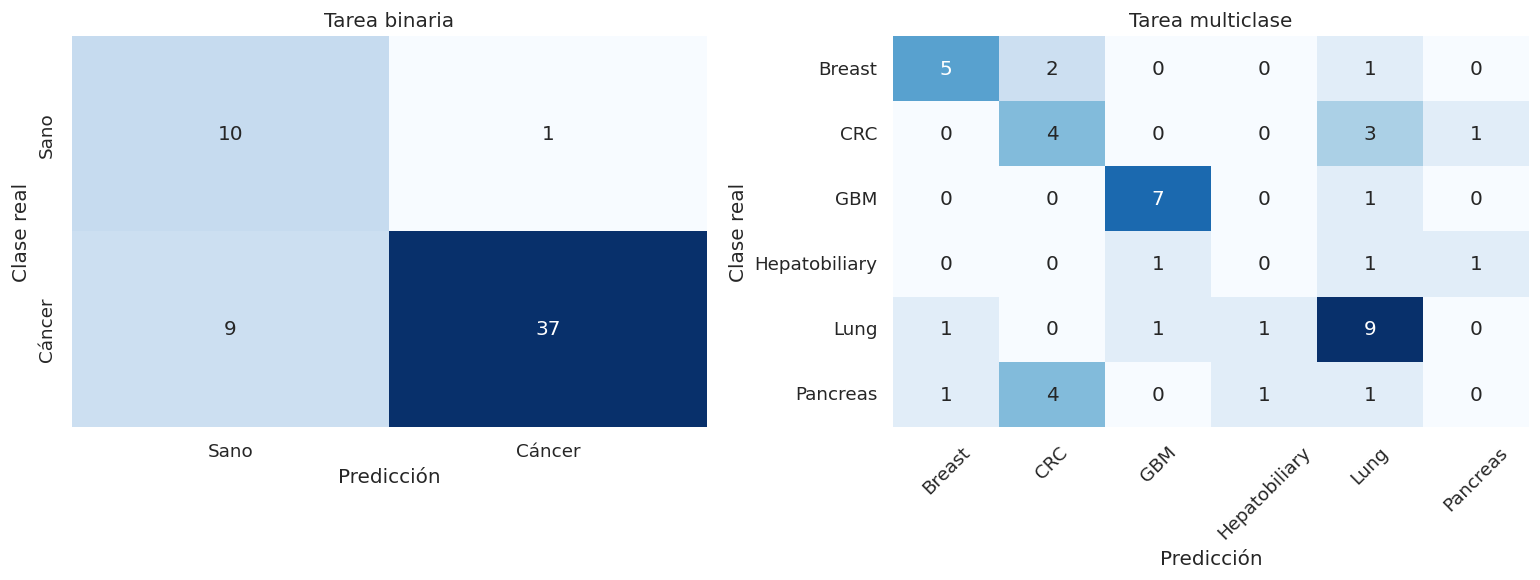

In [164]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

# Binaria
orden_bin = ["Sano", "Cáncer"]
matriz_bin = confusion_matrix(y_pru_bin, pred_bin, labels=orden_bin)
sns.heatmap(matriz_bin, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=orden_bin, yticklabels=orden_bin, ax=ejes[0])
ejes[0].set_title("Tarea binaria")
ejes[0].set_xlabel("Predicción"); ejes[0].set_ylabel("Clase real")

# Multiclase
orden_multi = ["Breast", "CRC", "GBM", "Hepatobiliary", "Lung", "Pancreas"]
matriz_multi = confusion_matrix(y_pru_multi, pred_multi, labels=orden_multi)
sns.heatmap(matriz_multi, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=orden_multi, yticklabels=orden_multi, ax=ejes[1])
ejes[1].set_title("Tarea multiclase")
ejes[1].set_xlabel("Predicción"); ejes[1].set_ylabel("Clase real")
ejes[1].tick_params(axis="x", rotation=45)

plt.tight_layout(); plt.show()

In [165]:
reparto = pd.DataFrame({
    "muestras reales": y_pru_multi.value_counts(),
    "veces predicha": pd.Series(pred_multi).value_counts(),
}).reindex(orden_multi).fillna(0).astype(int)
reparto["aciertos"] = [matriz_multi[i, i] for i in range(len(orden_multi))]

print("Reparto de las predicciones en la tarea multiclase:\n")
print(reparto.to_string())

Reparto de las predicciones en la tarea multiclase:

               muestras reales  veces predicha  aciertos
Breast                       8               7         5
CRC                          8              10         4
GBM                          8               9         7
Hepatobiliary                3               2         0
Lung                        12              16         9
Pancreas                     7               2         0


La matriz de la tarea binaria muestra un comportamiento asimétrico. De las 11 muestras de individuos sanos, 10 se clasifican correctamente y solo 1 se confunde con un caso de cáncer. Entre las 46 muestras tumorales, en cambio, 9 se identifican erróneamente como sanas. El modelo se inclina, por tanto, hacia la clase minoritaria, y el coste de esa inclinación recae precisamente sobre los falsos negativos, que en un contexto clínico resultan más graves que los errones en sanos (falsos positivos).

En la tarea multiclase el análisis es mucho más informativo. El glioblastoma se identifica mejor, con 7 aciertos de 8 muestras, y el cáncer de pulmón alcanza 9 de 12. Mama y colorrectal se sitúan en niveles intermedios, mientras que los grupos hepatobiliar y de páncreas no registran ningún acierto.

El reparto de las predicciones explica el origen del problema. El modelo predice el cáncer de pulmón 16 veces cuando en el conjunto de prueba hay 12 muestras, y el colorrectal 10 frente a 8, mientras que apenas nombra a las categorías de páncreas y hepatobiliar, con 2 predicciones cada una. Las predicciones se desplazan así hacia las clases mejor representadas, un comportamiento característico de una regularización excesiva (al reducir la magnitud de los coeficientes de forma severa, el modelo tiende a centrarse en las categorías que resultan más fáciles de acertar).

Dentro de ese patrón, destaca que 4 de las 7 muestras de páncreas se clasifican como colorrectal, una proporción que difícilmente se debe al azar. Ambos tumores comparten origen en el aparato digestivo, lo que podría traducirse en respuestas plaquetarias semejantes, aunque la propia tendencia del modelo a favorecer las clases mayoritarias basta para explicar buena parte del efecto y no permite atribuirlo con seguridad a una causa biológica.

Se debe señalar que las dos únicas ocasiones en que el modelo predice páncreas resultan también erróneas, ya que corresponden a muestras de colorrectal y hepatobiliar. Por tanto, la frontera entre estas categorías no queda correctamente aprendida.

Este diagnóstico apunta a una limitación del criterio empleado para seleccionar el modelo.

La exactitud balanceada promedia las sensibilidades de todas las clases, de modo que un modelo puede obtener un valor aceptable concentrándose en las categorías más sencillas y renunciando por completo a las difíciles.

La puntuación F1 promediada por clase no lo permite en la misma medida, ya que una categoría sin aciertos arrastra a cero tanto su precisión como su sensibilidad, y penaliza así el abandono de clases minoritarias.

Por tanto, se puede repetir la selección del modelo empleando la puntuación F1 macro como criterio, junto con una exploración más detallada del parámetro de regularización. Los resultados obtenidos hasta este punto se conservan, ya que corresponden a decisiones tomadas sin conocimiento del conjunto de prueba; la nueva selección se presenta como refinamiento posterior al diagnóstico de los errores, y su alcance debe interpretarse teniendo presente esa diferencia.

### **Búsqueda de correcciones a los modelos**

#### **Revisión del umbral de corte en la tarea binaria**

Un clasificador binario no decide directamente la clase, sino que estima la probabilidad de pertenecer a cada una y aplica después un punto de corte, fijado por defecto en 0,5. Ese valor no tiene por qué ser el óptimo.

El área bajo la curva obtenida, de 0,958, indica que el modelo ordena correctamente las muestras según su probabilidad de corresponder a un paciente con cáncer. Por tanto, la capacidad discriminativa existe, y el desequilibrio observado entre falsos positivos y falsos negativos es causado por el punto de corte.

El umbral se determina mediante validación cruzada sobre el conjunto de entrenamiento, sin usar las muestras reservadas para la evaluación. El criterio elegido es el índice de Youden, que maximiza la suma de sensibilidad y especificidad y localiza así el punto de mayor equilibrio entre ambas. Además, se informa del rendimiento alcanzado al fijar la especificidad en el 95% y en el 99%, no como alternativas al criterio anterior, sino para permitir la comparación con los estudios de referencia, que establecieron un límite máximo de falsos positivos y midieron qué detección era posible en esas condiciones.

In [166]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve

# Probabilidades estimadas sin que ninguna muestra intervenga en su propio modelo, de modo que el umbral se elige sin mirar el conjunto de prueba
flujo_umbral = construir_flujo(crear_modelo(mejor_bin["modelo"],
                                            mejor_bin["estrategia"]),
                               mejor_bin["estrategia"], k_binaria)
flujo_umbral.set_params(**mejor_bin["mejores_parametros"])

prob_cv = cross_val_predict(flujo_umbral, X_ent_bin_norm, y_ent_bin,
                            cv=cv, method="predict_proba", n_jobs=-1)

# Columna correspondiente a la clase positiva
clases = np.unique(y_ent_bin)
columna_cancer = list(clases).index("Cáncer")
prob_cancer_cv = prob_cv[:, columna_cancer]
y_ent_binario = (y_ent_bin == "Cáncer").astype(int)

fpr, tpr, umbrales = roc_curve(y_ent_binario, prob_cancer_cv)
print(f"Puntos de corte evaluados: {len(umbrales)}")
print(f"AUC en validación cruzada: {roc_auc_score(y_ent_binario, prob_cancer_cv):.3f}")

Puntos de corte evaluados: 26
AUC en validación cruzada: 0.977


In [167]:
especificidad = 1 - fpr
youden = tpr + especificidad - 1

# Criterio principal: máximo equilibrio entre sensibilidad y especificidad
i_youden = int(np.argmax(youden))
umbral_youden = umbrales[i_youden]

# Criterios adicionales: especificidad mínima fijada, como en los estudios de referencia
def umbral_con_especificidad(objetivo):
    validos = np.where(especificidad >= objetivo)[0]
    if len(validos) == 0:
        return None, None, None
    i = validos[np.argmax(tpr[validos])]   # mayor sensibilidad entre los válidos
    return umbrales[i], tpr[i], especificidad[i]

umbral_95, sens_95, esp_95 = umbral_con_especificidad(0.95)
umbral_99, sens_99, esp_99 = umbral_con_especificidad(0.99)

print("Umbrales estimados por validación cruzada sobre entrenamiento:\n")
print(f"  Por defecto        0,500 | sensibilidad {tpr[np.argmin(np.abs(umbrales - 0.5))]:.3f} "
      f"| especificidad {especificidad[np.argmin(np.abs(umbrales - 0.5))]:.3f}")
print(f"  Índice de Youden   {umbral_youden:.3f} | sensibilidad {tpr[i_youden]:.3f} "
      f"| especificidad {especificidad[i_youden]:.3f}")
if umbral_95:
    print(f"  Especificidad 95%  {umbral_95:.3f} | sensibilidad {sens_95:.3f} "
          f"| especificidad {esp_95:.3f}")
if umbral_99:
    print(f"  Especificidad 99%  {umbral_99:.3f} | sensibilidad {sens_99:.3f} "
          f"| especificidad {esp_99:.3f}")

Umbrales estimados por validación cruzada sobre entrenamiento:

  Por defecto        0,500 | sensibilidad 0.902 | especificidad 0.955
  Índice de Youden   0.567 | sensibilidad 0.886 | especificidad 0.977
  Especificidad 95%  0.505 | sensibilidad 0.902 | especificidad 0.955
  Especificidad 99%  0.774 | sensibilidad 0.832 | especificidad 1.000


La representación de la curva ROC permite situar visualmente los puntos de corte considerados y observar los errores cometidos.

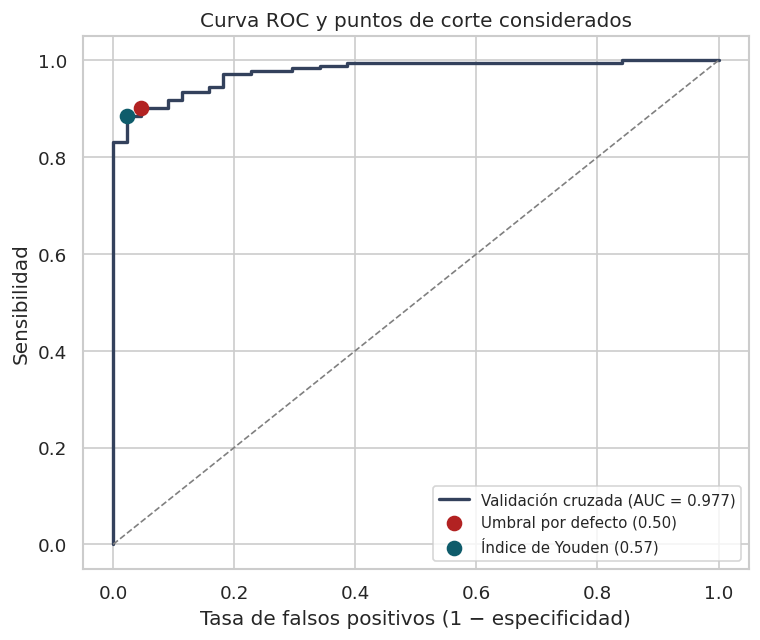

In [168]:
plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr, tpr, color=azul_oscuro, lw=2,
         label=f"Validación cruzada (AUC = {roc_auc_score(y_ent_binario, prob_cancer_cv):.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1)

i_defecto = np.argmin(np.abs(umbrales - 0.5))
plt.scatter(fpr[i_defecto], tpr[i_defecto], color="firebrick", s=70, zorder=5,
            label=f"Umbral por defecto ({umbrales[i_defecto]:.2f})")
plt.scatter(fpr[i_youden], tpr[i_youden], color=verde_azulado, s=70, zorder=5,
            label=f"Índice de Youden ({umbral_youden:.2f})")

plt.xlabel("Tasa de falsos positivos (1 − especificidad)")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC y puntos de corte considerados")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

Determinado el punto de corte sobre el conjunto de entrenamiento, se aplica a las muestras reservadas. El resultado obtenido conserva así su independencia, ya que el conjunto de prueba no ha intervenido en la elección del umbral.

La siguiente tabla recoge el rendimiento obtenido con cada punto de corte. El correspondiente al índice de Youden constituye el modelo revisado; los umbrales de especificidad fija se incluyen únicamente como información complementaria, y su interpretación debe hacerse con cuidado, ya que con 11 controles sanos en el conjunto de prueba, cada falso positivo modifica la especificidad considerablemente.

In [169]:
prob_cancer_pru = prob_bin[:, list(flujo_bin.classes_).index("Cáncer")]
y_pru_binario = (y_pru_bin == "Cáncer").astype(int)

def evaluar_umbral(umbral, nombre):
    prediccion = np.where(prob_cancer_pru >= umbral, "Cáncer", "Sano")
    matriz = confusion_matrix(y_pru_bin, prediccion, labels=["Sano", "Cáncer"])
    vn, fp, fn, vp = matriz.ravel()
    return {
        "criterio": nombre,
        "umbral": umbral,
        "exactitud_balanceada": balanced_accuracy_score(y_pru_bin, prediccion),
        "sensibilidad": vp / (vp + fn),
        "especificidad": vn / (vn + fp),
        "f1_macro": f1_score(y_pru_bin, prediccion, average="macro"),
        "falsos_negativos": int(fn),
        "falsos_positivos": int(fp),
    }

filas = [evaluar_umbral(0.5, "por defecto"),
         evaluar_umbral(umbral_youden, "índice de Youden")]
if umbral_95:
    filas.append(evaluar_umbral(umbral_95, "especificidad 95%"))
if umbral_99:
    filas.append(evaluar_umbral(umbral_99, "especificidad 99%"))

tabla_umbral = pd.DataFrame(filas)
tabla_umbral["papel"] = ["referencia", "PRINCIPAL"] + \
                        ["contraste"] * (len(filas) - 2)

print("Rendimiento sobre el conjunto de prueba según el umbral:\n")
print(tabla_umbral.round(3).to_string(index=False))

Rendimiento sobre el conjunto de prueba según el umbral:

         criterio  umbral  exactitud_balanceada  sensibilidad  especificidad  f1_macro  falsos_negativos  falsos_positivos      papel
      por defecto   0.500                 0.857         0.804          0.909     0.774                 9                 1 referencia
 índice de Youden   0.567                 0.902         0.804          1.000     0.801                 9                 0  PRINCIPAL
especificidad 95%   0.505                 0.857         0.804          0.909     0.774                 9                 1  contraste
especificidad 99%   0.774                 0.870         0.739          1.000     0.749                12                 0  contraste


El área bajo la curva estimada por validación cruzada asciende a 0,977, lo que confirma que el modelo ordena las muestras con gran precisión según su probabilidad de corresponder a un paciente con cáncer. El umbral óptimo según el índice de Youden se sitúa en 0,567, algo por encima del valor por defecto.

Aplicado al conjunto de prueba, el nuevo punto de corte aumenta la exactitud balanceada de 0,857 a 0,902 y la puntuación F1 de 0,774 a 0,801. Este cambio consigue mejorar la especificidad, que pasa de 0,909 a 1,000 al eliminarse el único falso positivo. Sin embargo, la sensibilidad permanece en 0,804, de modo que los 9 casos de cáncer no detectados siguen siéndolo.

Por tanto, el ajuste del umbral no corrige la limitación identificada en el análisis de errores. El criterio de Youden busca el equilibrio entre ambos tipos de error, y sobre el conjunto de entrenamiento ese equilibrio se alcanzaba desplazando el corte hacia una mayor especificidad, dado que la sensibilidad ya resultaba elevada. El desequilibrio hacia los falsos negativos aparece únicamente al evaluar sobre datos nuevos, dado que la sensibilidad estimada por validación cruzada rondaba el 0,90 y desciende a 0,804 en el conjunto de prueba. Ningún cambio del punto de corte puede compensar esa caída, ya que su origen no está en la decisión sino en la capacidad del modelo para generalizar.

Con 11 controles sanos en el conjunto de prueba, la desaparición de un único falso positivo modifica la especificidad en nueve puntos porcentuales, y ese cambio en una sola muestra explica por completo el incremento de la exactitud balanceada. Una diferencia sostenida sobre un caso aislado no permite afirmar que el modelo revisado sea superior de forma consistente.

Los umbrales de especificidad fija, incluidos para el contraste con la literatura, confirman esto. Al exigir una especificidad del 99% el punto de corte se eleva hasta 0,774 y la sensibilidad desciende a 0,739, con 12 casos de cáncer sin detectar. La cifra es comparable al 68% de detección que Jopek et al. (2024) obtuvieron en esas mismas condiciones, aunque la comparación debe hacerse con cuidado por el reducido tamaño del conjunto de evaluación usado.

El modelo elegido para la tarea binaria es la regresión logística sin corrección del desbalance, con un parámetro de regularización de 0,1, penalización L2 y un umbral de decisión de 0,567.

Sobre el conjunto de prueba alcanza una exactitud balanceada de 0,902, una sensibilidad de 0,804 y una especificidad de 1,000. El punto de corte se mantiene a pesar de que su ventaja solo se deba a una única muestra, ya que fue determinado antes de conocer el resultado de la evaluación.

In [170]:
# Modelo definitivo de la tarea binaria: modelo seleccionado + umbral revisado
umbral_final_bin = umbral_youden
pred_bin_final = np.where(prob_cancer_pru >= umbral_final_bin, "Cáncer", "Sano")

In [171]:
from sklearn.metrics import accuracy_score

print("MODELO DEFINITIVO — tarea binaria (umbral 0,567)\n")
print(f"Exactitud simple:      {accuracy_score(y_pru_bin, pred_bin_final):.3f}")
print(f"Exactitud balanceada:  {balanced_accuracy_score(y_pru_bin, pred_bin_final):.3f}")
print(f"AUC:                   {roc_auc_score(y_pru_binario, prob_cancer_pru):.3f}")
print(f"F1 macro:              {f1_score(y_pru_bin, pred_bin_final, average='macro'):.3f}\n")

print(classification_report(y_pru_bin, pred_bin_final, digits=3, zero_division=0))

matriz_final = confusion_matrix(y_pru_bin, pred_bin_final, labels=["Sano", "Cáncer"])
print("Matriz de confusión (filas: real, columnas: predicho):")
print(pd.DataFrame(matriz_final, index=["Sano", "Cáncer"],
                   columns=["Sano", "Cáncer"]).to_string())

MODELO DEFINITIVO — tarea binaria (umbral 0,567)

Exactitud simple:      0.842
Exactitud balanceada:  0.902
AUC:                   0.958
F1 macro:              0.801

              precision    recall  f1-score   support

      Cáncer      1.000     0.804     0.892        46
        Sano      0.550     1.000     0.710        11

    accuracy                          0.842        57
   macro avg      0.775     0.902     0.801        57
weighted avg      0.913     0.842     0.856        57

Matriz de confusión (filas: real, columnas: predicho):
        Sano  Cáncer
Sano      11       0
Cáncer     9      37


#### **Revisión del criterio de selección en la tarea multiclase**

Se va a comprobar si un criterio de selección que penalice el abandono de clases minoritarias produce un modelo más equilibrado en la tarea multiclase.

In [172]:
# Rejilla con mayor resolución en el tramo intermedio de regularización
rejilla_revisada = {
    "modelo__C": [0.005, 0.01, 0.03, 0.05, 0.1, 0.3, 0.5, 1, 3, 10],
    "modelo__penalty": ["l2"],
    "modelo__solver": ["liblinear"],
}

metricas_revision = {
    "exactitud_balanceada": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "precision": "precision_macro",
    "sensibilidad": "recall_macro",
    "auc": "roc_auc_ovr",
}

resultados_revision = []
for estrategia in ["ninguna", "smote"]:
    flujo = construir_flujo(crear_modelo("regresion_logistica", estrategia),
                            estrategia, k_multiclase)
    busqueda = GridSearchCV(flujo, rejilla_revisada, cv=cv,
                            scoring=metricas_revision, refit="f1_macro",
                            n_jobs=-1)
    busqueda.fit(X_ent_multi_norm, y_ent_multi)

    i = busqueda.best_index_
    registro = {"estrategia": estrategia,
                "C": busqueda.best_params_["modelo__C"]}
    for m in metricas_revision:
        registro[m] = busqueda.cv_results_[f"mean_test_{m}"][i]
    resultados_revision.append(registro)
    print(f"  {estrategia:10s} C = {registro['C']:<6} "
          f"F1 macro = {registro['f1_macro']:.3f}")

revision_multi = pd.DataFrame(resultados_revision)

  ninguna    C = 0.01   F1 macro = 0.612
  smote      C = 10     F1 macro = 0.604


Una vez que el nuevo criterio selecciona la configuración sin corrección del desbalance, que tiene una F1 macro de 0,612, falta ver si conduce al mismo modelo que con el criterio de la exactitud balanceada.

In [173]:
mejor_revisado = revision_multi.sort_values("f1_macro", ascending=False).iloc[0]

comparacion = pd.DataFrame([
    {"criterio": "exactitud balanceada (original)",
     "estrategia": mejor_multi["estrategia"],
     "C": mejor_multi["mejores_parametros"]["modelo__C"],
     "exactitud_balanceada": mejor_multi["exactitud_balanceada"],
     "f1_macro": mejor_multi["f1_macro"],
     "precision": mejor_multi["precision"]},
    {"criterio": "F1 macro (revisado)",
     "estrategia": mejor_revisado["estrategia"],
     "C": mejor_revisado["C"],
     "exactitud_balanceada": mejor_revisado["exactitud_balanceada"],
     "f1_macro": mejor_revisado["f1_macro"],
     "precision": mejor_revisado["precision"]},
])

print("Configuración seleccionada según el criterio, en validación cruzada:\n")
print(comparacion.round(3).to_string(index=False))

Configuración seleccionada según el criterio, en validación cruzada:

                       criterio estrategia    C  exactitud_balanceada  f1_macro  precision
exactitud balanceada (original)    ninguna 0.01                 0.625     0.612      0.635
            F1 macro (revisado)    ninguna 0.01                 0.625     0.612      0.635


In [174]:
fila_revisada = pd.Series({
    "modelo": "regresion_logistica",
    "estrategia": mejor_revisado["estrategia"],
    "mejores_parametros": {"modelo__C": mejor_revisado["C"],
                           "modelo__penalty": "l2",
                           "modelo__solver": "liblinear"},
})

flujo_rev, pred_rev, prob_rev, met_rev = entrenar_y_evaluar(
    fila_revisada, X_ent_multi_norm, y_ent_multi,
    X_pru_multi_norm, y_pru_multi, k_multiclase, multiclase=True)

prueba = pd.DataFrame([
    {"modelo": "original (exactitud balanceada)", **met_multi},
    {"modelo": "revisado (F1 macro)", **met_rev},
])
print("Rendimiento sobre el conjunto de prueba:\n")
print(prueba.round(3).to_string(index=False))

Rendimiento sobre el conjunto de prueba:

                         modelo  exactitud_balanceada  f1_macro  precision  sensibilidad   auc
original (exactitud balanceada)                 0.458      0.43      0.409         0.458 0.815
            revisado (F1 macro)                 0.458      0.43      0.409         0.458 0.815


Ambas configuraciones describen el mismo modelo.

Reparto de las predicciones por clase:

               reales  predicha (original)  aciertos (original)  predicha (revisado)  aciertos (revisado)
Breast              8                    7                    5                    7                    5
CRC                 8                   10                    4                   10                    4
GBM                 8                    9                    7                    9                    7
Hepatobiliary       3                    2                    0                    2                    0
Lung               12                   16                    9                   16                    9
Pancreas            7                    2                    0                    2                    0


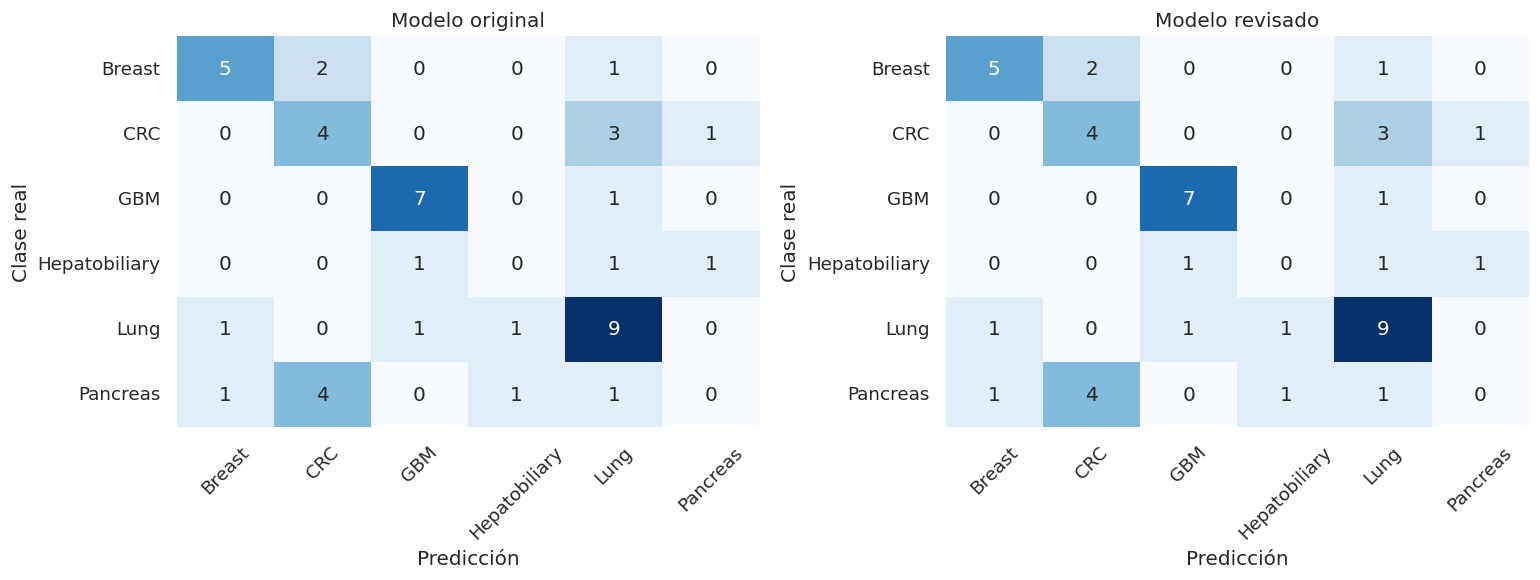

In [175]:
orden_multi = ["Breast", "CRC", "GBM", "Hepatobiliary", "Lung", "Pancreas"]
matriz_rev = confusion_matrix(y_pru_multi, pred_rev, labels=orden_multi)
matriz_ori = confusion_matrix(y_pru_multi, pred_multi, labels=orden_multi)

reparto = pd.DataFrame({
    "reales": y_pru_multi.value_counts(),
    "predicha (original)": pd.Series(pred_multi).value_counts(),
    "aciertos (original)": pd.Series([matriz_ori[i, i] for i in range(6)],
                                     index=orden_multi),
    "predicha (revisado)": pd.Series(pred_rev).value_counts(),
    "aciertos (revisado)": pd.Series([matriz_rev[i, i] for i in range(6)],
                                     index=orden_multi),
}).reindex(orden_multi).fillna(0).astype(int)

print("Reparto de las predicciones por clase:\n")
print(reparto.to_string())

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
for eje, (titulo, matriz) in zip(ejes, [("Modelo original", matriz_ori),
                                        ("Modelo revisado", matriz_rev)]):
    sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=orden_multi, yticklabels=orden_multi, ax=eje)
    eje.set_title(titulo)
    eje.set_xlabel("Predicción"); eje.set_ylabel("Clase real")
    eje.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

In [176]:
print("MODELO REVISADO — detalle por clase\n")
print(classification_report(y_pru_multi, pred_rev, digits=3, zero_division=0))

MODELO REVISADO — detalle por clase

               precision    recall  f1-score   support

       Breast      0.714     0.625     0.667         8
          CRC      0.400     0.500     0.444         8
          GBM      0.778     0.875     0.824         8
Hepatobiliary      0.000     0.000     0.000         3
         Lung      0.562     0.750     0.643        12
     Pancreas      0.000     0.000     0.000         7

     accuracy                          0.543        46
    macro avg      0.409     0.458     0.430        46
 weighted avg      0.476     0.543     0.504        46



Con estas dos últimas celdas de código se ha terminado de confirmar que son el mismo modelo, es decir, que la búsqueda con la puntuación F1 macro como criterio selecciona exactamente la misma configuración que la exactitud balanceada: regresión logística sin corrección del desbalance con un parámetro de regularización de 0,01. Por tanto, ambos criterios conducen al mismo modelo, y su rendimiento sobre el conjunto de prueba es idéntico al ya comentado.

El resultado gana mayor peso al considerar que la rejilla revisada incorporaba valores intermedios que la original no contemplaba, entre ellos 0,005, 0,03 y 0,05, y aun así, la búsqueda siguió escogiendo 0,01, de modo que ese valor no responde a una exploración insuficiente del parámetro sino a que efectivamente maximiza ambos criterios sobre los datos disponibles.

Por ello, se puede descartar la hipótesis de partida. El abandono de las clases minoritarias no se debía a que la exactitud balanceada aguantase ese comportamiento, ya que un criterio que lo penaliza de forma explícita conduce a la misma elección.

Entre todas las configuraciones exploradas, ninguna logra un reparto más equilibrado de las predicciones, por lo que el problema no se encuentra en cómo se selecciona el modelo, sino en la información disponible para distinguir esas categorías. Por tanto, existen limitaciones debido al tamaño del conjunto de datos. El grupo hepatobiliar cuenta con 11 muestras de entrenamiento y el de páncreas con 28, frente a las 1000 variables que conserva el modelo tras el prefiltrado. En esas condiciones, la señal que permitiría separar dichas categorías del resto resulta insuficiente para que ningún ajuste del clasificador la aproveche.

Una vez que se ha descartado el criterio de selección como causa, se debe examinar un elemento anterior del proceso: la elección de los genes con los que trabaja el modelo.

#### **Revisión de la selección de genes (tarea multiclase)**

Lo siguiente es comprobar si un procedimiento de selección que garantice representación a cada clase permite al modelo reconocer las categorías minoritarias.

In [177]:
from sklearn.base import BaseEstimator, TransformerMixin

class SeleccionPorClase(BaseEstimator, TransformerMixin):
    """Selecciona los mejores genes de cada clase frente al resto y los une.
    Garantiza que toda categoría aporte variables, sea cual sea su tamaño."""

    def __init__(self, genes_por_clase=200):
        self.genes_por_clase = genes_por_clase

    def fit(self, X, y):
        X_matriz = np.asarray(X)
        seleccionados = set()
        for clase in np.unique(y):
            binaria = (np.asarray(y) == clase).astype(int)
            puntuaciones, _ = f_classif(X_matriz, binaria)
            puntuaciones = np.nan_to_num(puntuaciones, nan=-np.inf)
            mejores = np.argsort(puntuaciones)[::-1][:self.genes_por_clase]
            seleccionados.update(mejores.tolist())
        self.indices_ = np.array(sorted(seleccionados))
        return self

    def transform(self, X):
        return np.asarray(X)[:, self.indices_]

def construir_flujo_por_clase(modelo, estrategia, genes_por_clase):
    "Igual que el flujo habitual, pero con selección por clase."
    pasos = [("escalado", StandardScaler()),
             ("seleccion", SeleccionPorClase(genes_por_clase))]
    if estrategia == "smote":
        pasos.append(("remuestreo", SMOTE(random_state=semilla, k_neighbors=3)))
    pasos.append(("modelo", modelo))
    return PipelineDesbalance(pasos)

La búsqueda explora tanto el número de genes que aporta cada clase como el parámetro de regularización, ya que ambos interactúan. Un conjunto de variables más amplio suele requerir una penalización más intensa (se emplea la puntuación F1 macro como criterio, por las razones del apartado anterior).

In [178]:
rejilla_por_clase = {
    "seleccion__genes_por_clase": [50, 100, 200, 400],
    "modelo__C": [0.01, 0.1, 1, 10],
    "modelo__penalty": ["l2"],
    "modelo__solver": ["liblinear"],
}

resultados_clase = []
for estrategia in ["ninguna", "smote"]:
    flujo = construir_flujo_por_clase(
        crear_modelo("regresion_logistica", estrategia), estrategia, 200)
    busqueda = GridSearchCV(flujo, rejilla_por_clase, cv=cv,
                            scoring=metricas_revision, refit="f1_macro",
                            n_jobs=-1)
    busqueda.fit(X_ent_multi_norm, y_ent_multi)

    i = busqueda.best_index_
    registro = {"estrategia": estrategia,
                "genes_por_clase": busqueda.best_params_["seleccion__genes_por_clase"],
                "C": busqueda.best_params_["modelo__C"]}
    for m in metricas_revision:
        registro[m] = busqueda.cv_results_[f"mean_test_{m}"][i]
    resultados_clase.append(registro)
    print(f"  {estrategia:10s} genes/clase = {registro['genes_por_clase']:<4} "
          f"C = {registro['C']:<6} F1 macro = {registro['f1_macro']:.3f}")

seleccion_clase = pd.DataFrame(resultados_clase)

  ninguna    genes/clase = 400  C = 0.01   F1 macro = 0.592
  smote      genes/clase = 400  C = 0.01   F1 macro = 0.598


Una vez que se tienen las dos selecciones de genes nuevas, es necesaria la comparación con los resultados obtenidos mediante el prefiltrado original, para valorar si la nueva selección aporta alguna mejora en validación cruzada, antes de evaluarla sobre el conjunto reservado.

In [179]:
comparacion_cv = pd.DataFrame([
    {"selección": "univariante global (1000 genes)",
     "f1_macro": mejor_multi["f1_macro"],
     "exactitud_balanceada": mejor_multi["exactitud_balanceada"],
     "precision": mejor_multi["precision"]},
    *[{"selección": f"por clase ({f['genes_por_clase']}/clase) — {f['estrategia']}",
       "f1_macro": f["f1_macro"],
       "exactitud_balanceada": f["exactitud_balanceada"],
       "precision": f["precision"]}
      for _, f in seleccion_clase.iterrows()],
])
print("Validación cruzada sobre el conjunto de entrenamiento:\n")
print(comparacion_cv.round(3).to_string(index=False))

Validación cruzada sobre el conjunto de entrenamiento:

                      selección  f1_macro  exactitud_balanceada  precision
univariante global (1000 genes)     0.612                 0.625      0.635
por clase (400/clase) — ninguna     0.592                 0.608      0.613
  por clase (400/clase) — smote     0.598                 0.619      0.614


In [180]:
mejor_clase = seleccion_clase.sort_values("f1_macro", ascending=False).iloc[0]

flujo_pc = construir_flujo_por_clase(
    crear_modelo("regresion_logistica", mejor_clase["estrategia"]),
    mejor_clase["estrategia"], int(mejor_clase["genes_por_clase"]))
flujo_pc.set_params(modelo__C=mejor_clase["C"], modelo__penalty="l2",
                    modelo__solver="liblinear")
flujo_pc.fit(X_ent_multi_norm, y_ent_multi)

pred_pc = flujo_pc.predict(X_pru_multi_norm)
prob_pc = flujo_pc.predict_proba(X_pru_multi_norm)

met_pc = {
    "exactitud_balanceada": balanced_accuracy_score(y_pru_multi, pred_pc),
    "f1_macro": f1_score(y_pru_multi, pred_pc, average="macro"),
    "precision": precision_score(y_pru_multi, pred_pc, average="macro", zero_division=0),
    "sensibilidad": recall_score(y_pru_multi, pred_pc, average="macro"),
    "auc": roc_auc_score(y_pru_multi, prob_pc, multi_class="ovr",
                         average="macro", labels=flujo_pc.classes_),
}

print("Conjunto de prueba:\n")
print(pd.DataFrame([{"modelo": "selección univariante global", **met_multi},
                    {"modelo": "selección por clase", **met_pc}]
                   ).round(3).to_string(index=False))

print(f"\nGenes seleccionados en total: {len(flujo_pc.named_steps['seleccion'].indices_)}")

Conjunto de prueba:

                      modelo  exactitud_balanceada  f1_macro  precision  sensibilidad   auc
selección univariante global                 0.458     0.430      0.409         0.458 0.815
         selección por clase                 0.461     0.463      0.474         0.461 0.795

Genes seleccionados en total: 2105


A pesar de que en el conjunto de prueba el modelo actual mejora al original, la selección por clase no mejora el rendimiento en validación cruzada. La mejor configuración, con 400 genes por categoría y remuestreo mediante SMOTE, alcanza una puntuación F1 macro de 0,598 frente al 0,612 del prefiltrado original, y queda igualmente por detrás en exactitud balanceada y en precisión.

Por tanto, según el criterio establecido, el modelo seleccionado sigue siendo el obtenido con la selección univariante global.

Independientemente de la decisión, se va a estudiar la matriz de confusión de este nuevo modelo.

Reparto de las predicciones:

               reales  predicha (global)  aciertos (global)  predicha (por clase)  aciertos (por clase)
Breast              8                  7                  5                     6                     4
CRC                 8                 10                  4                     9                     3
GBM                 8                  9                  7                     7                     6
Hepatobiliary       3                  2                  0                     4                     1
Lung               12                 16                  9                    14                     8
Pancreas            7                  2                  0                     6                     1


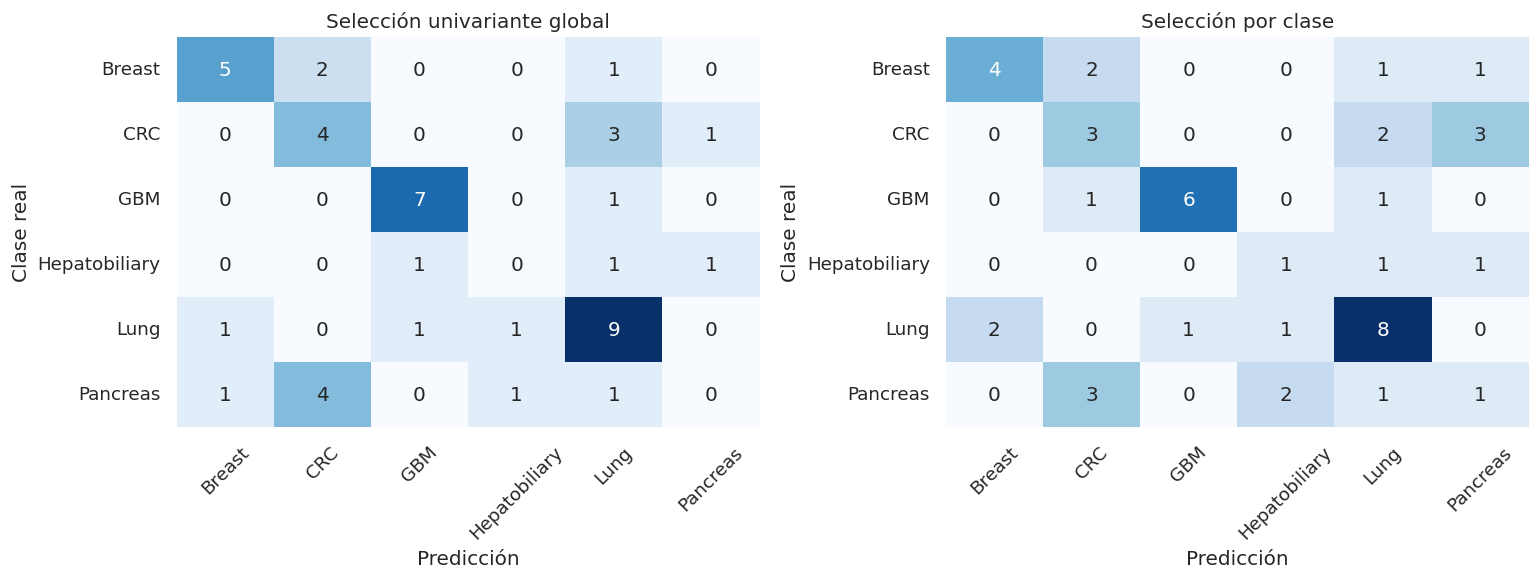


Detalle por clase del modelo con selección por clase:

               precision    recall  f1-score   support

       Breast      0.667     0.500     0.571         8
          CRC      0.333     0.375     0.353         8
          GBM      0.857     0.750     0.800         8
Hepatobiliary      0.250     0.333     0.286         3
         Lung      0.571     0.667     0.615        12
     Pancreas      0.167     0.143     0.154         7

     accuracy                          0.500        46
    macro avg      0.474     0.461     0.463        46
 weighted avg      0.514     0.500     0.502        46



In [181]:
matriz_pc = confusion_matrix(y_pru_multi, pred_pc, labels=orden_multi)

reparto = pd.DataFrame({
    "reales": y_pru_multi.value_counts(),
    "predicha (global)": pd.Series(pred_multi).value_counts(),
    "aciertos (global)": pd.Series([matriz_ori[i, i] for i in range(6)], index=orden_multi),
    "predicha (por clase)": pd.Series(pred_pc).value_counts(),
    "aciertos (por clase)": pd.Series([matriz_pc[i, i] for i in range(6)], index=orden_multi),
}).reindex(orden_multi).fillna(0).astype(int)

print("Reparto de las predicciones:\n")
print(reparto.to_string())

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
for eje, (titulo, matriz) in zip(ejes, [("Selección univariante global", matriz_ori),
                                        ("Selección por clase", matriz_pc)]):
    sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=orden_multi, yticklabels=orden_multi, ax=eje)
    eje.set_title(titulo)
    eje.set_xlabel("Predicción"); eje.set_ylabel("Clase real")
    eje.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print("\nDetalle por clase del modelo con selección por clase:\n")
print(classification_report(y_pru_multi, pred_pc, digits=3, zero_division=0))

El comportamiento sobre el conjunto de prueba muestra el efecto que produce el cambio. El reparto de las predicciones se equilibra de forma apreciable porque el cáncer de páncreas pasa de recibir 2 predicciones a 6, y el carcinoma hepatobiliar de 2 a 4, registrando cada uno un acierto donde antes no obtenían ninguno.

Esa redistribución se produce a costa del resto de categorías. Mama desciende de 5 aciertos a 4, colorrectal de 4 a 3, el glioblastoma de 7 a 6 y el cáncer de pulmón de 9 a 8. En conjunto, el modelo original clasifica correctamente 25 de las 46 muestras y el revisado solo 23, de modo que la exactitud simple desciende de 0,543 a 0,500. El área bajo la curva también disminuye, de 0,815 a 0,795.

Por tanto, el modelo de este apartado no ha aprendido a reconocer las clases minoritarias, sino que se limita a repartir sus predicciones de manera más uniforme, acertando alguna por azar y perdiendo aciertos en las categorías que antes resolvía bien. La mejora en la puntuación F1 macro sobre el conjunto de prueba refleja ese reparto más equitativo, no una mayor capacidad discriminativa.

 Después de haber investigado dos vías de mejora y haberlas descartado, se puede afirmar con cierta seguridad lo siguiente: ni el criterio de selección del modelo ni el procedimiento de elección de genes explican el comportamiento observado.

 La dificultad entonces se encuentra en que los perfiles de ARN plaquetario disponibles no contienen señal suficiente para separar el cáncer de páncreas y el carcinoma hepatobiliar del resto de categorías, al menos con 28 y 11 muestras de entrenamiento respectivamente.

Por tanto, el modelo multiclase final queda así:

In [182]:
print("MODELO MULTICLASE DEFINITIVO (selección univariante global)\n")
print(f"Exactitud simple:      {accuracy_score(y_pru_multi, pred_multi):.3f}")
print(f"Exactitud balanceada:  {balanced_accuracy_score(y_pru_multi, pred_multi):.3f}")
print(f"F1 macro:              {f1_score(y_pru_multi, pred_multi, average='macro'):.3f}")
print(f"AUC (uno contra resto):{roc_auc_score(y_pru_multi, prob_multi, multi_class='ovr', average='macro', labels=flujo_multi.classes_):.3f}\n")

# Cifra comparable con Jopek et al. (2024), que clasifica cinco tipos tumorales
sin_hepato = y_pru_multi != "Hepatobiliary"
print("Restringido a las cinco clases con mayor representación "
      "(se excluye el grupo hepatobiliar, ausente en el estudio de referencia):")
print(f"  muestras evaluadas: {sin_hepato.sum()}")
print(f"  exactitud simple:   {accuracy_score(y_pru_multi[sin_hepato], pred_multi[sin_hepato]):.3f}")

MODELO MULTICLASE DEFINITIVO (selección univariante global)

Exactitud simple:      0.543
Exactitud balanceada:  0.458
F1 macro:              0.430
AUC (uno contra resto):0.815

Restringido a las cinco clases con mayor representación (se excluye el grupo hepatobiliar, ausente en el estudio de referencia):
  muestras evaluadas: 43
  exactitud simple:   0.581


### **Estabilidad de los resultados frente al reparto**

La evaluación se ha realizado sobre una única división de los datos. Sin embargo, como los tamaños resultantes son reducidos (57 muestras en la tarea binaria y 46 en la multiclase, con categorías que apenas alcanzan las tres), un solo acierto o error modifica las métricas de forma apreciable, como se comprobó al observar que la desaparición de un único falso positivo elevaba la especificidad considerablemente.

Por tanto, para comprobar la robustez del modelo, es bueno repetir el proceso completo con distintas particiones aleatorias, informando de la media y la dispersión de las métricas resultantes.

La finalidad no es seleccionar la partición más favorable, sino conocer el margen de incertidumbre que acompaña a los valores obtenidos. Los modelos y sus hiperparámetros se mantienen fijos en la configuración ya seleccionada, de modo que la única variación sea el reparto de las muestras.

In [183]:
def repetir_con_semillas(X_completo, y_completo, fila_modelo, k_genes,
                         multiclase, umbral=None, n_repeticiones=20):
    """Repite partición, entrenamiento y evaluación con distintas semillas.
    El modelo y sus hiperparámetros permanecen fijos."""
    resultados = []
    for repeticion in range(n_repeticiones):
        semilla_rep = semilla + repeticion

        # La réplica se mantiene siempre en entrenamiento, como en la partición original
        presentes = [m for m in replica if m in X_completo.index]
        sin_rep = X_completo.index.difference(presentes)

        X_ent, X_pru, y_ent, y_pru = train_test_split(
            X_completo.loc[sin_rep], y_completo.loc[sin_rep],
            test_size=0.20, stratify=y_completo.loc[sin_rep],
            random_state=semilla_rep)
        if presentes:
            X_ent = pd.concat([X_ent, X_completo.loc[presentes]])
            y_ent = pd.concat([y_ent, y_completo.loc[presentes]])

        X_ent_n, X_pru_n = normalizar(X_ent), normalizar(X_pru)

        flujo = construir_flujo(crear_modelo(fila_modelo["modelo"],
                                             fila_modelo["estrategia"]),
                                fila_modelo["estrategia"], k_genes)
        flujo.set_params(**fila_modelo["mejores_parametros"])
        flujo.fit(X_ent_n, y_ent)

        probabilidad = flujo.predict_proba(X_pru_n)
        if multiclase:
            prediccion = flujo.predict(X_pru_n)
            auc = roc_auc_score(y_pru, probabilidad, multi_class="ovr",
                                average="macro", labels=flujo.classes_)
        else:
            columna = list(flujo.classes_).index("Cáncer")
            corte = umbral if umbral is not None else 0.5
            prediccion = np.where(probabilidad[:, columna] >= corte, "Cáncer", "Sano")
            auc = roc_auc_score((y_pru == "Cáncer").astype(int),
                                probabilidad[:, columna])

        resultados.append({
            "repeticion": repeticion,
            "exactitud": accuracy_score(y_pru, prediccion),
            "exactitud_balanceada": balanced_accuracy_score(y_pru, prediccion),
            "f1_macro": f1_score(y_pru, prediccion, average="macro"),
            "auc": auc,
        })
    return pd.DataFrame(resultados)

estabilidad_bin = repetir_con_semillas(X, y_binaria, mejor_bin, k_binaria,
                                       multiclase=False, umbral=umbral_final_bin)

estabilidad_multi = repetir_con_semillas(X_multiclase, y_multiclase, mejor_multi,
                                         k_multiclase, multiclase=True)

print("\nSe han repetido ambas tareas con distintas semillas.")


Se han repetido ambas tareas con distintas semillas.


El resumen recoge, junto a la media y la desviación típica de cada métrica, el rango de valores observado y el resultado correspondiente a la partición empleada en los apartados anteriores, lo que permite situarlo dentro de la distribución.

In [184]:
def resumir(tabla, valores_originales, nombre):
    metricas = ["exactitud", "exactitud_balanceada", "f1_macro", "auc"]
    resumen = pd.DataFrame({
        "media": tabla[metricas].mean(),
        "desviación": tabla[metricas].std(),
        "mínimo": tabla[metricas].min(),
        "máximo": tabla[metricas].max(),
        "partición original": pd.Series(valores_originales),
    })
    print(f"{nombre} ({len(tabla)} repeticiones)\n")
    print(resumen.round(3).to_string(), "\n")
    return resumen

originales_bin = {
    "exactitud": accuracy_score(y_pru_bin, pred_bin_final),
    "exactitud_balanceada": balanced_accuracy_score(y_pru_bin, pred_bin_final),
    "f1_macro": f1_score(y_pru_bin, pred_bin_final, average="macro"),
    "auc": roc_auc_score(y_pru_binario, prob_cancer_pru),
}
originales_multi = {
    "exactitud": accuracy_score(y_pru_multi, pred_multi),
    "exactitud_balanceada": met_multi["exactitud_balanceada"],
    "f1_macro": met_multi["f1_macro"],
    "auc": met_multi["auc"],
}

resumen_bin = resumir(estabilidad_bin, originales_bin, "TAREA BINARIA")
resumen_multi = resumir(estabilidad_multi, originales_multi, "TAREA MULTICLASE")

TAREA BINARIA (20 repeticiones)

                      media  desviación  mínimo  máximo  partición original
exactitud             0.891       0.049   0.789   0.982               0.842
exactitud_balanceada  0.917       0.048   0.800   0.989               0.902
f1_macro              0.853       0.062   0.729   0.973               0.801
auc                   0.969       0.025   0.885   1.000               0.958 

TAREA MULTICLASE (20 repeticiones)

                      media  desviación  mínimo  máximo  partición original
exactitud             0.589       0.055   0.435   0.652               0.543
exactitud_balanceada  0.568       0.065   0.442   0.669               0.458
f1_macro              0.555       0.069   0.430   0.658               0.430
auc                   0.853       0.033   0.777   0.897               0.815 



La variabilidad entre particiones resulta considerable en ambas tareas.
- En la binaria, la exactitud balanceada oscila entre 0,800 y 0,989 según el reparto, con una media de 0,917 y una desviación típica de 0,048.
- En la multiclase el rango va de 0,442 a 0,669, con media de 0,568 y desviación de 0,065.

Ningún valor concreto puede considerarse, por tanto, una estimación precisa del rendimiento, sino un punto dentro de una distribución relativamente amplia.

La representación gráfica de la distribución permite apreciar la amplitud de la variación y comprobar si el valor obtenido con la partición original se sitúa en una posición central o extrema.

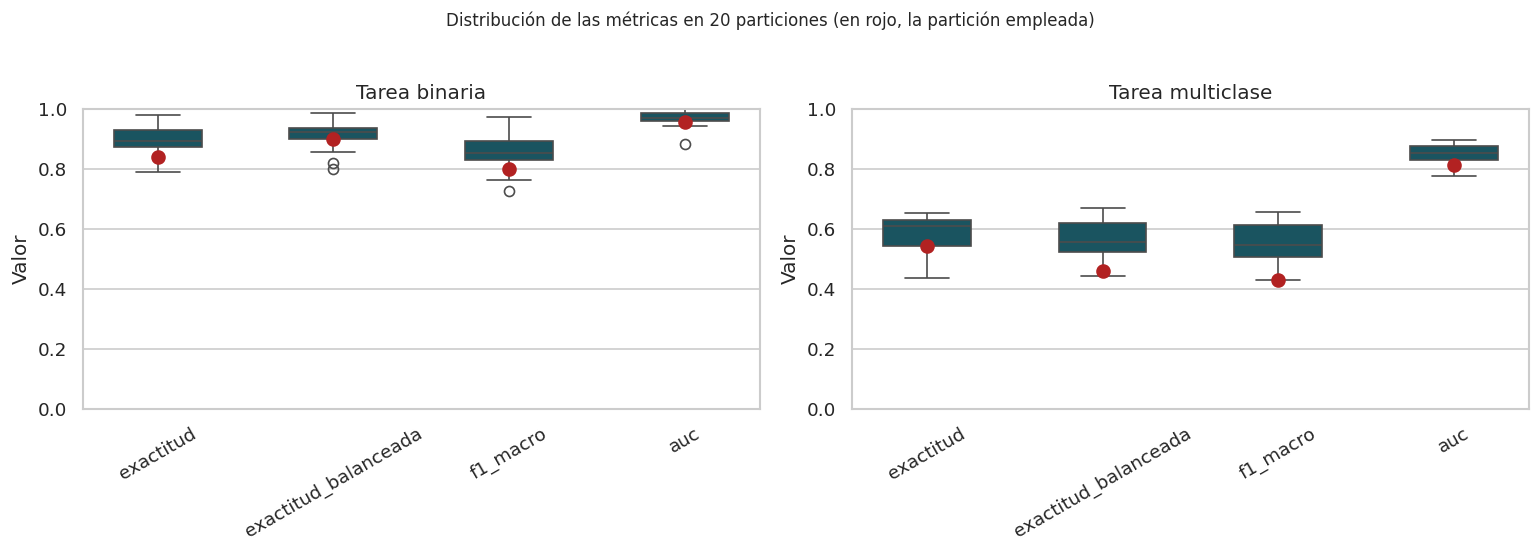

In [185]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
metricas = ["exactitud", "exactitud_balanceada", "f1_macro", "auc"]

for eje, (titulo, tabla, originales) in zip(
        ejes, [("Tarea binaria", estabilidad_bin, originales_bin),
               ("Tarea multiclase", estabilidad_multi, originales_multi)]):
    sns.boxplot(data=tabla[metricas], color=verde_azulado, ax=eje, width=0.5)
    for i, m in enumerate(metricas):
        eje.scatter(i, originales[m], color="firebrick", s=60, zorder=5)
    eje.set_title(titulo)
    eje.set_ylabel("Valor")
    eje.set_ylim(0, 1)
    eje.tick_params(axis="x", rotation=30)

plt.suptitle("Distribución de las métricas en 20 particiones "
             "(en rojo, la partición empleada)", y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

In [186]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Con clases de tres muestras, conviene comprobar cuántas veces quedan sin aciertos.
# La réplica se mantiene en entrenamiento, igual que en la partición original.
sin_aciertos = {clase: 0 for clase in orden_multi}
presentes = [m for m in replica if m in X_multiclase.index]
sin_rep = X_multiclase.index.difference(presentes)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")          # evita el aviso de genes constantes en algún pliegue
    for repeticion in range(20):
        semilla_rep = semilla + repeticion
        X_ent, X_pru, y_ent, y_pru = train_test_split(
            X_multiclase.loc[sin_rep], y_multiclase.loc[sin_rep],
            test_size=0.20, stratify=y_multiclase.loc[sin_rep],
            random_state=semilla_rep)
        X_ent = pd.concat([X_ent, X_multiclase.loc[presentes]])
        y_ent = pd.concat([y_ent, y_multiclase.loc[presentes]])

        X_ent_n, X_pru_n = normalizar(X_ent), normalizar(X_pru)

        flujo = construir_flujo(crear_modelo(mejor_multi["modelo"],
                                             mejor_multi["estrategia"]),
                                mejor_multi["estrategia"], k_multiclase)
        flujo.set_params(**mejor_multi["mejores_parametros"])
        flujo.fit(X_ent_n, y_ent)
        prediccion = flujo.predict(X_pru_n)

        matriz = confusion_matrix(y_pru, prediccion, labels=orden_multi)
        for i, clase in enumerate(orden_multi):
            if matriz[i].sum() > 0 and matriz[i, i] == 0:
                sin_aciertos[clase] += 1

print("Número de particiones (de 20) en que cada clase no obtiene ningún acierto:\n")
for clase, veces in sin_aciertos.items():
    print(f"  {clase:15s} {veces:2d}")

Número de particiones (de 20) en que cada clase no obtiene ningún acierto:

  Breast           0
  CRC              0
  GBM              0
  Hepatobiliary    5
  Lung             0
  Pancreas         1


La posición de la partición empleada se diferencia en ambas tareas. En la binaria se sitúa próxima a la media, con 0,902 frente a 0,917, de modo que los resultados comunicados resultan representativos. En la multiclase, en cambio, tiene una posición desfavorable: su exactitud balanceada de 0,458 se acerca al mínimo observado de 0,442, muy por debajo de la media de 0,568. Por tanto, el reparto obtenido fue uno de los menos favorables entre los examinados.

Este resultado obliga a corregir el diagnóstico formulado en el apartado anterior. El recuento por clase muestra que el cáncer de páncreas queda sin aciertos en una sola de las 20 particiones examinadas, y esa partición es precisamente la empleada en la evaluación principal. En las 19 restantes el modelo sí reconoce esa categoría, de modo que la ausencia total de aciertos no desvela una incapacidad del modelo sino una consecuencia del reparto concreto de las muestras. Así, la interpretación según la cual los datos no contendrían señal suficiente para esa clase no se sostiene y debe sustituirse por otra: con solo 7 muestras en el conjunto de prueba, el resultado de esa categoría está sujeto a una variabilidad que permite tanto varios aciertos como ninguno, aunque este último caso sea poco frecuente.

El carcinoma hepatobiliar presenta, en cambio, un problema real. Este tipo se queda sin ningún acierto en 5 de las 20 particiones, una cuarta parte del total, lo que resulta coherente con disponer únicamente de 11 muestras de entrenamiento y 3 de evaluación. Las métricas correspondientes a esta categoría carecen de fiabilidad con los datos disponibles.

El área bajo la curva es la métrica más estable en ambas tareas, con desviaciones de 0,025 y 0,033 respectivamente. Su cálculo no depende de un umbral de decisión ni de la asignación concreta de clases, sino de la ordenación de las muestras según su probabilidad estimada, lo que la hace menos sensible al reparto. Resulta, por ello, la métrica más sólida para valorar la capacidad discriminativa de los modelos.

Los valores obtenidos con la partición original se mantienen como resultado principal del trabajo, ya que fue la establecida antes de cualquier evaluación y sustituirla por otra más favorable comprometería la independencia de la estimación. A esas cifras se añade en adelante la información sobre su dispersión, de modo que la tarea binaria alcanza una exactitud balanceada de 0,902 en la partición evaluada, dentro de una distribución de media 0,917 y desviación típica 0,048, mientras que la multiclase obtiene 0,458 frente a una media de 0,568 y una desviación de 0,065.

Esta forma de comunicar los resultados es más informativa que una cifra aislada y muestra lo que se puede esperar del procedimiento aplicado a datos nuevos. Además, constituye la principal limitación provocada por el tamaño del conjunto: con menos de 300 muestras repartidas entre 7 categorías, cualquier estimación puntual arrastra un margen de incertidumbre alto.

### **Contraste con los estudios de referencia**

Se pretende valorar si el rendimiento obtenido resulta competitivo frente al de los trabajos que abordaron el mismo problema.

Es importante saber que los estudios de referencia no emplean las mismas métricas ni las mismas condiciones de evaluación. Best et al. (2015) comunican una exactitud del 96% en la detección de cáncer, sin fijar ningún límite de especificidad. Jopek et al. (2024) informan de una detección del 68% al 99% de especificidad y de un 79,4% de acierto en la clasificación de cinco tipos tumorales.

Cada cifra responde a un planteamiento distinto, de modo que el contraste debe realizarse métrica a métrica y no mediante una comparación global.

In [187]:
contraste = pd.DataFrame([
    # Detección de cáncer — exactitud
    {"tarea": "detección de cáncer", "métrica": "exactitud",
     "estudio": "Best et al. (2015)", "valor": 0.96,
     "condiciones": "validación dejando una muestra fuera"},
    {"tarea": "detección de cáncer", "métrica": "exactitud",
     "estudio": "Este trabajo", "valor": accuracy_score(y_pru_bin, pred_bin_final),
     "condiciones": "conjunto de prueba independiente"},

    # Detección de cáncer — sensibilidad al 99% de especificidad
    {"tarea": "detección de cáncer", "métrica": "sensibilidad al 99% esp.",
     "estudio": "Jopek et al. (2024)", "valor": 0.68,
     "condiciones": "conjunto de prueba independiente"},
    {"tarea": "detección de cáncer", "métrica": "sensibilidad al 99% esp.",
     "estudio": "Este trabajo",
     "valor": tabla_umbral.loc[tabla_umbral["criterio"] == "especificidad 99%",
                               "sensibilidad"].iloc[0],
     "condiciones": "conjunto de prueba independiente"},

    # Tipo de tumor — seis clases
    {"tarea": "tipo de tumor (6 clases)", "métrica": "exactitud",
     "estudio": "Best et al. (2015)", "valor": 0.71,
     "condiciones": "cohorte de validación (n = 108)"},
    {"tarea": "tipo de tumor (6 clases)", "métrica": "exactitud",
     "estudio": "Este trabajo", "valor": accuracy_score(y_pru_multi, pred_multi),
     "condiciones": "conjunto de prueba independiente"},

    # Tipo de tumor — cinco clases
    {"tarea": "tipo de tumor (5 clases)", "métrica": "exactitud",
     "estudio": "Jopek et al. (2024)", "valor": 0.794,
     "condiciones": "conjunto de prueba independiente"},
    {"tarea": "tipo de tumor (5 clases)", "métrica": "exactitud",
     "estudio": "Este trabajo",
     "valor": accuracy_score(y_pru_multi[sin_hepato], pred_multi[sin_hepato]),
     "condiciones": "se excluye el grupo hepatobiliar"},
])

print(contraste.round(3).to_string(index=False))

                   tarea                  métrica             estudio  valor                          condiciones
     detección de cáncer                exactitud  Best et al. (2015)  0.960 validación dejando una muestra fuera
     detección de cáncer                exactitud        Este trabajo  0.842     conjunto de prueba independiente
     detección de cáncer sensibilidad al 99% esp. Jopek et al. (2024)  0.680     conjunto de prueba independiente
     detección de cáncer sensibilidad al 99% esp.        Este trabajo  0.739     conjunto de prueba independiente
tipo de tumor (6 clases)                exactitud  Best et al. (2015)  0.710      cohorte de validación (n = 108)
tipo de tumor (6 clases)                exactitud        Este trabajo  0.543     conjunto de prueba independiente
tipo de tumor (5 clases)                exactitud Jopek et al. (2024)  0.794     conjunto de prueba independiente
tipo de tumor (5 clases)                exactitud        Este trabajo  0.581     se excl

En la detección de cáncer, el modelo alcanza una exactitud de 84,2% sobre la partición evaluada, frente al 96% comunicado por Best et al. (2015). La diferencia es notable, aunque las condiciones de evaluación no se pueden equiparar. Ellos validaron su modelo dejando una muestra fuera en cada iteración, procedimiento que emplea prácticamente todos los datos para entrenar y tiende a producir estimaciones más optimistas que un conjunto de prueba reservado. Utilizaron además la plataforma thromboSeq, con un procedimiento propio de corrección del ruido técnico y una selección de genes mediante optimización por enjambre de partículas, frente al filtro univariante usado en este trabajo.

Por tanto, se está comparando un método desarrollado y refinado por el grupo que generó los datos con una implementación construida sobre herramientas de uso general.

La comparación con Jopek et al. (2024) resulta más directa, ya que trabajan sobre los mismos datos y con un conjunto de prueba independiente. Al fijar la especificidad en el 99%, el modelo obtenido detecta el 73,9% de los casos de cáncer, por encima del 68% comunicado en aquel estudio. Es importante interpretar el dato con cuidado, ya que la especificidad se estima aquí sobre 11 controles sanos, de modo que un solo falso positivo bastaría para modificar la cifra de forma considerable.

En la clasificación del tipo tumoral la distancia es mayor en ambas comparaciones. Best et al. identificaron el órgano de origen entre los mismos 6 tipos con un 71% de exactitud sobre una cohorte de validación de 108 muestras, y Jopek et al. alcanzaron un 79,4% restringiendo el problema a 5 categorías. El modelo obtiene aquí 54,3% sobre 6 clases y 58,1% al excluir el grupo hepatobiliar para equiparar la comparación con este último trabajo.

La partición empleada resultó desfavorable para esta tarea. Repitiendo el proceso con 20 reparticiones, la exactitud media asciende a 58,9% y llega hasta 65,2% en el mejor de los repartos, valores que siguen quedando por debajo de ambas referencias aunque acorten la distancia.

Sin embargo, frente al 19% de exactitud media que Best et al. atribuyen a clasificadores aleatorios sobre este problema, los resultados obtenidos la triplican, lo que confirma que el modelo extrae información real de los perfiles de expresión.

El área bajo la curva ofrece la comparación más estable por no depender del umbral de decisión ni de la asignación concreta de clases. Los valores obtenidos, de 0,958 en la detección de cáncer y 0,815 en la clasificación del tipo tumoral, con desviaciones de 0,025 y 0,033 entre particiones, indican que la capacidad discriminativa se mantiene en niveles altos aun cuando las métricas basadas en predicción empeoran.

En definitiva, los modelos seleccionados en este análisis tienen las siguientes características:

In [188]:
print("Resultados de este trabajo, con la variabilidad estimada en 20 particiones:\n")
for nombre, resumen in [("Detección de cáncer", resumen_bin),
                        ("Tipo de tumor", resumen_multi)]:
    print(nombre)
    for metrica in ["exactitud", "exactitud_balanceada", "auc"]:
        fila = resumen.loc[metrica]
        print(f"  {metrica:22s} {fila['partición original']:.3f} "
              f"(media {fila['media']:.3f} ± {fila['desviación']:.3f}, "
              f"rango {fila['mínimo']:.3f}–{fila['máximo']:.3f})")
    print()

Resultados de este trabajo, con la variabilidad estimada en 20 particiones:

Detección de cáncer
  exactitud              0.842 (media 0.891 ± 0.049, rango 0.789–0.982)
  exactitud_balanceada   0.902 (media 0.917 ± 0.048, rango 0.800–0.989)
  auc                    0.958 (media 0.969 ± 0.025, rango 0.885–1.000)

Tipo de tumor
  exactitud              0.543 (media 0.589 ± 0.055, rango 0.435–0.652)
  exactitud_balanceada   0.458 (media 0.568 ± 0.065, rango 0.442–0.669)
  auc                    0.815 (media 0.853 ± 0.033, rango 0.777–0.897)



In [189]:
print("MODELOS SELECCIONADOS\n")

print("Tarea binaria (detección de cáncer)")
print(f"  regresión logística, sin corrección del desbalance")
print(f"  {mejor_bin['mejores_parametros']}")
print(f"  prefiltrado: {k_binaria} genes | umbral de decisión: {umbral_final_bin:.3f}")
print(f"  exactitud {accuracy_score(y_pru_bin, pred_bin_final):.3f} | "
      f"exactitud balanceada {balanced_accuracy_score(y_pru_bin, pred_bin_final):.3f} | "
      f"AUC {roc_auc_score(y_pru_binario, prob_cancer_pru):.3f}\n")

print("Tarea multiclase (tipo de tumor)")
print(f"  regresión logística, {mejor_multi['estrategia']}")
print(f"  {mejor_multi['mejores_parametros']}")
print(f"  prefiltrado: {k_multiclase} genes")
print(f"  exactitud {accuracy_score(y_pru_multi, pred_multi):.3f} | "
      f"exactitud balanceada {met_multi['exactitud_balanceada']:.3f} | "
      f"AUC {met_multi['auc']:.3f}")

MODELOS SELECCIONADOS

Tarea binaria (detección de cáncer)
  regresión logística, sin corrección del desbalance
  {'modelo__C': 0.1, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  prefiltrado: 5000 genes | umbral de decisión: 0.567
  exactitud 0.842 | exactitud balanceada 0.902 | AUC 0.958

Tarea multiclase (tipo de tumor)
  regresión logística, ninguna
  {'modelo__C': 0.01, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  prefiltrado: 1000 genes
  exactitud 0.543 | exactitud balanceada 0.458 | AUC 0.815


El rendimiento en la detección de cáncer puede considerarse competitivo. Supera al de Jopek et al. en la única métrica directamente comparable y queda por debajo del comunicado por Best et al., diferencia atribuible en gran parte a un procedimiento de validación más exigente y a la ausencia de las técnicas específicas de preprocesado que aquel grupo desarrolló para estos datos.

La clasificación del tipo tumoral se coloca claramente por detrás de ambos estudios. Esto se debe principalmente a tres factores:
- El efecto de lote documentado en la preparación de los datos no se corrigió, decisión justificada por estar parcialmente confundido con la clase, pero que introduce variación técnica en el modelado.
- La selección de genes se apoya en un filtro univariante, que es más simple que los procedimientos de optimización empleados en los trabajos de referencia.
- El reducido tamaño de las categorías minoritarias, con 11 muestras de entrenamiento en el grupo hepatobiliar, no permite que el modelo aprenda a reconocerlas de forma fiable.

Estas limitaciones no invalidan el planteamiento comparativo del trabajo, dado que se evalúan 5 algoritmos sobre las mismas condiciones para ambas tareas, con la regresión logística como modelo de mejor rendimiento en las dos. Ese resultado coincide con la conclusión de Jopek et al. (2024), quienes encontraron que un modelo lineal sencillo superaba a métodos más complejos sobre datos de ARN plaquetario.


## **Fase 5: identificación de los genes característicos**

Objetivo: extraer del modelo seleccionado los genes en los que se basan sus predicciones, comprobar su estabilidad frente a distintas particiones y descartar que se correspondan con variación de origen técnico.

### **Extracción de la firma génica**

La regresión logística asigna a cada gen un coeficiente que indica en qué dirección y con qué intensidad contribuye a la decisión. Un coeficiente positivo desplaza la predicción hacia una clase y uno negativo hacia la contraria, y su magnitud refleja el peso de esa contribución. Como los datos se estandarizaron antes del modelado, todos los genes comparten escala y los coeficientes son directamente comparables entre sí.

El ajuste de hiperparámetros seleccionó la penalización L2 en ambas tareas, que reduce la magnitud de los coeficientes sin llegar a anularlos. La firma no se puede obtener, por tanto, de forma automática, sino ordenando los genes por el valor absoluto de su coeficiente y conservando los de mayor peso. El número de genes seleccionados es una decisión que debe comentarse: se fija en 50 por tarea, cifra suficiente para permitir una lectura interpretable sin reducir la firma a unos pocos genes cuya selección resultaría más sensible al azar.

En la tarea multiclase el modelo estima un conjunto de coeficientes por cada categoría, lo que permite identificar los genes característicos de cada tipo tumoral por separado, que es precisamente uno de los objetivos planteados.


In [190]:
def extraer_coeficientes(flujo, columnas_originales):
    """
    Recupera los coeficientes del modelo asociándolos a su gen.
    El paso de selección reduce las columnas, de modo que hay que recomponer la correspondencia con los identificadores originales.
    """
    mascara = flujo.named_steps["seleccion"].get_support()
    genes = np.array(columnas_originales)[mascara]
    coeficientes = flujo.named_steps["modelo"].coef_
    clases = flujo.classes_
    if coeficientes.shape[0] == 1:          # tarea binaria
        return pd.DataFrame({"gen": genes, "coeficiente": coeficientes[0]})
    return pd.DataFrame(coeficientes.T, index=genes, columns=clases)

coef_bin = extraer_coeficientes(flujo_bin, X.columns)
coef_multi = extraer_coeficientes(flujo_multi, X_multiclase.columns)

print(f"Genes con coeficiente asignado — binaria: {len(coef_bin):,}")
print(f"Genes con coeficiente asignado — multiclase: {len(coef_multi):,}")
print(f"\nClases del modelo multiclase: {list(coef_multi.columns)}")

Genes con coeficiente asignado — binaria: 5,000
Genes con coeficiente asignado — multiclase: 1,000

Clases del modelo multiclase: ['Breast', 'CRC', 'GBM', 'Hepatobiliary', 'Lung', 'Pancreas']


El modelo binario asigna coeficientes a los 5000 genes que conserva el prefiltrado, y el multiclase a los 1000 correspondientes, con un conjunto distinto por cada tipo tumoral.

La firma de la tarea binaria recoge los genes que más contribuyen a distinguir a los individuos con cáncer de los controles sanos. El signo del coeficiente indica el sentido de esa contribución: los valores positivos corresponden a genes cuya mayor expresión desplaza la predicción hacia la ausencia de tumor (se ve en la salida siguiente).

In [191]:
n_firma = 50
clase_positiva = flujo_bin.classes_[1]          # clase a la que se refieren los coeficientes

coef_bin["magnitud"] = coef_bin["coeficiente"].abs()
firma_bin = coef_bin.sort_values("magnitud", ascending=False).head(n_firma).copy()
firma_bin["sentido"] = np.where(firma_bin["coeficiente"] > 0,
                                clase_positiva, flujo_bin.classes_[0])

print(f"Los coeficientes se refieren a la clase: {clase_positiva}")
print("Un coeficiente positivo desplaza la predicción hacia esa clase.\n")
print(firma_bin["sentido"].value_counts().to_string(), "\n")
print("Veinte genes de mayor peso:\n")
print(firma_bin[["gen", "coeficiente", "sentido"]].head(20).round(4).to_string(index=False))

Los coeficientes se refieren a la clase: Sano
Un coeficiente positivo desplaza la predicción hacia esa clase.

sentido
Sano      45
Cáncer     5 

Veinte genes de mayor peso:

            gen  coeficiente sentido
ENSG00000105255      -0.0667  Cáncer
ENSG00000181007       0.0663    Sano
ENSG00000184206       0.0611    Sano
ENSG00000254977       0.0606    Sano
ENSG00000243364       0.0603    Sano
ENSG00000197830       0.0577    Sano
ENSG00000250654       0.0566    Sano
ENSG00000211710       0.0565    Sano
ENSG00000211803       0.0557    Sano
ENSG00000117318       0.0555    Sano
ENSG00000264031       0.0553    Sano
ENSG00000075131       0.0545    Sano
ENSG00000211752       0.0537    Sano
ENSG00000264254       0.0535    Sano
ENSG00000196581       0.0530    Sano
ENSG00000263164       0.0526    Sano
ENSG00000225113       0.0526    Sano
ENSG00000264290       0.0513    Sano
ENSG00000104722       0.0511    Sano
ENSG00000114739       0.0509    Sano


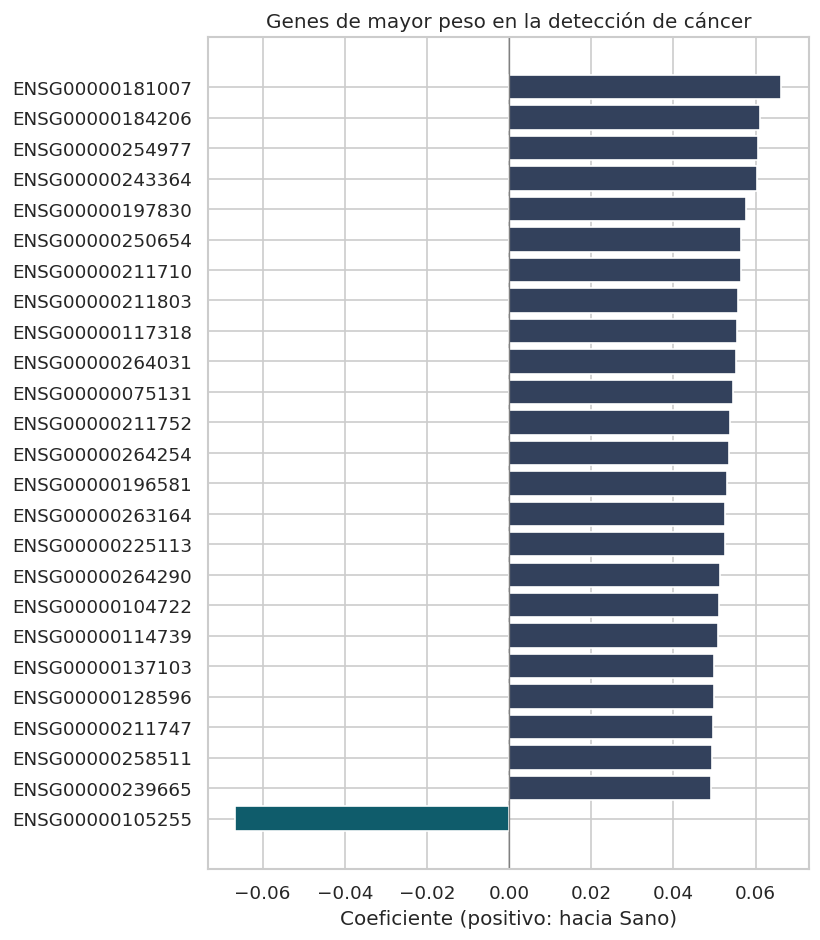

In [192]:
grafico = firma_bin.head(25).sort_values("coeficiente")

# Coeficiente positivo: desplaza hacia la clase positiva del modelo (Sano)
colores = [azul_oscuro if c > 0 else verde_azulado for c in grafico["coeficiente"]]

plt.figure(figsize=(7, 8))
plt.barh(grafico["gen"], grafico["coeficiente"], color=colores)
plt.axvline(0, color="gray", lw=0.8)
plt.xlabel(f"Coeficiente (positivo: hacia {clase_positiva})")
plt.title("Genes de mayor peso en la detección de cáncer")
plt.tight_layout(); plt.show()

Las magnitudes obtenidas son reducidas y muy parecidas entre sí. El coeficiente de mayor valor absoluto asciende a 0,067 y los 50 primeros se reparten en un intervalo estrecho, sin que ninguno destaque sobre el resto. Este comportamiento es consecuencia directa de la penalización L2 seleccionada durante el ajuste, que reduce todos los coeficientes de forma proporcional en lugar de concentrar el peso en unas pocas variables. La predicción se apoya en un número reducido de genes determinantes, sino en la contribución conjunta de muchos genes con aportaciones individuales pequeñas.

El reparto por sentido es desigual. Basta con ver que de los 50 genes de mayor peso, 45 presentan coeficiente positivo, de modo que su expresión elevada se asocia al perfil de los individuos sanos, mientras que solo 5 apuntan en sentido contrario. La señal que distingue ambos grupos parece manifestarse, por tanto, sobre todo como una pérdida de expresión en las muestras tumorales respecto a los controles, más que como la aparición de genes característicos del tumor.

Como ya se ha comentado, en la tarea multiclase, cada tipo tumoral posee su propio conjunto de coeficientes. Los genes con mayor valor positivo para una categoría son aquellos cuya expresión elevada favorece su predicción, y constituyen la firma característica de ese tumor.

In [193]:
n_por_clase = 15
firmas_por_clase = {}

for clase in coef_multi.columns:
    ordenados = coef_multi[clase].sort_values(ascending=False)
    firmas_por_clase[clase] = ordenados.head(n_por_clase)

print(f"Genes característicos de cada tipo tumoral "
      f"(los {n_por_clase} de mayor coeficiente positivo):\n")
for clase, genes in firmas_por_clase.items():
    print(f"{clase}")
    print("  " + ", ".join(genes.index))
    print(f"  coeficiente máximo: {genes.iloc[0]:.4f}\n")

Genes característicos de cada tipo tumoral (los 15 de mayor coeficiente positivo):

Breast
  ENSG00000253474, ENSG00000105376, ENSG00000125166, ENSG00000146834, ENSG00000149782, ENSG00000117174, ENSG00000100601, ENSG00000074660, ENSG00000095209, ENSG00000100150, ENSG00000175575, ENSG00000103091, ENSG00000188549, ENSG00000205485, ENSG00000008282
  coeficiente máximo: 0.0970

CRC
  ENSG00000177888, ENSG00000104763, ENSG00000154265, ENSG00000168405, ENSG00000129472, ENSG00000198223, ENSG00000164300, ENSG00000146776, ENSG00000233355, ENSG00000006125, ENSG00000059588, ENSG00000130717, ENSG00000164180, ENSG00000134899, ENSG00000106692
  coeficiente máximo: 0.0523

GBM
  ENSG00000196935, ENSG00000066923, ENSG00000197283, ENSG00000085465, ENSG00000169629, ENSG00000090920, ENSG00000253701, ENSG00000078018, ENSG00000268746, ENSG00000161249, ENSG00000138658, ENSG00000179593, ENSG00000196634, ENSG00000235770, ENSG00000198722
  coeficiente máximo: 0.0596

Hepatobiliary
  ENSG00000243364, ENSG000001

Genes compartidos entre las firmas de cada par de tipos tumorales:

               Breast  CRC  GBM  Hepatobiliary  Lung  Pancreas
Breast             15    0    0              0     0         0
CRC                 0   15    0              0     0         0
GBM                 0    0   15              0     0         0
Hepatobiliary       0    0    0             15     0         0
Lung                0    0    0              0    15         0
Pancreas            0    0    0              0     0        15


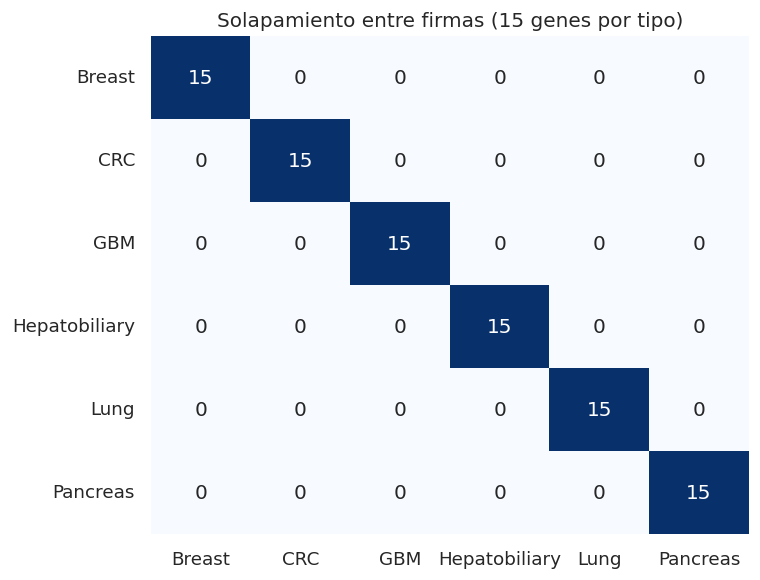

In [194]:
conjuntos = {c: set(g.index) for c, g in firmas_por_clase.items()}
clases = list(conjuntos)
solape = pd.DataFrame(0, index=clases, columns=clases)
for a in clases:
    for b in clases:
        solape.loc[a, b] = len(conjuntos[a] & conjuntos[b])

print("Genes compartidos entre las firmas de cada par de tipos tumorales:\n")
print(solape.to_string())

plt.figure(figsize=(6.5, 5))
sns.heatmap(solape, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Solapamiento entre firmas ({n_por_clase} genes por tipo)")
plt.tight_layout(); plt.show()

El solapamiento entre firmas informa sobre la especificidad de los genes seleccionados. De esta manera, un valor reducido fuera de la diagonal indica que cada tipo tumoral se apoya en genes propios, mientras que coincidencias abundantes mostrarían que el modelo emplea un mismo conjunto de variables para distinguir categorías distintas, con la consiguiente pérdida de especificidad biológica.

Los coeficientes máximos varían según la categoría, desde 0,052 en el cáncer colorrectal hasta 0,097 en el de mama. Los valores más elevados corresponden a mama, páncreas y carcinoma hepatobiliar. Sin embargo, un mayor peso relativo no se traduce en un mejor rendimiento predictivo, como demuestra el caso del grupo hepatobiliar, que a pesar de contar con coeficientes elevados no obtuvo ningún acierto en la evaluación.

Las firmas de los seis tipos tumorales no comparten ningún gen entre sí. Este resultado debe interpretarse con cuidado, ya que al seleccionar 15 genes de un conjunto de mil, la coincidencia esperable por azar entre 2 categorías cualesquiera es menor a 1 gen, de manera que la ausencia de solapamiento no es una prueba de especificidad biológica.

Esta prueba permite afirmar que el modelo no recurre a un mismo grupo completo de variables para diferenciar categorías distintas.

Hay un gen que llama la atención dentro de los resultados.

In [195]:
gen = "ENSG00000243364"
expresion = normalizar(X)[gen]

print(f"Expresión media de {gen} por clase (log2 CPM):\n")
resumen_gen = pd.DataFrame({
    "media": expresion.groupby(etiquetas).mean(),
    "mediana": expresion.groupby(etiquetas).median(),
    "n": etiquetas.value_counts(),
}).sort_values("media", ascending=False)
print(resumen_gen.round(3).to_string())

Expresión media de ENSG00000243364 por clase (log2 CPM):

               media  mediana   n
tipo_tumor                       
Sano           0.478      0.0  55
Hepatobiliary  0.151      0.0  14
GBM            0.042      0.0  40
CRC            0.000      0.0  42
Breast         0.000      0.0  39
Lung           0.000      0.0  60
Pancreas       0.000      0.0  35


El identificador ENSG00000243364 se encuentra entre los genes de mayor peso de la tarea binaria y encabeza además la firma del carcinoma hepatobiliar. Las dos tareas plantean comparaciones diferentes, ya que la binaria contrasta a los individuos sanos con el conjunto de los pacientes y, la multiclase compara cada tumor con los restantes, de modo que ambas contribuciones son compatibles. Se trataría entonces de un gen que se expresa sobre todo en personas sanas y que, entre los tumores, conserva algo de expresión únicamente en el grupo hepatobiliar.

La mediana de sus valores de expresión es nula en todas las clases, incluida la sana, y no llega a detectarse en ninguna muestra de cáncer colorrectal, de mama, de pulmón ni de páncreas. Por lo que, es un gen de expresión escasa y esporádica, que superó el filtrado inicial por un margen estrecho, de manera que su peso en el modelo no viene de diferencias en el nivel de expresión sino de un patrón de presencia o ausencia.

### **Estabilidad de la firma**

Las firmas génicas obtenidas a partir de datos de expresión sufren un problema, que consiste en que pequeñas variaciones en las muestras de entrenamiento producen listas de genes muy distintas, aunque el rendimiento predictivo apenas cambie (Abeel et al., 2010). Esa inestabilidad compromete la interpretación biológica, que constituye uno de los objetivos de este trabajo.

La comprobación consiste en repetir la extracción con distintas particiones de los datos y contar con qué frecuencia aparece cada gen. Los que se seleccionan en bastantes particiones merecen mayor confianza que los que solo aparecen en repartos concretos.

In [196]:
def firma_repetida(X_completo, y_completo, fila_modelo, k_genes,
                   n_genes=50, n_repeticiones=20):
    """Cuenta cuántas veces aparece cada gen en la firma."""
    apariciones = {}
    for repeticion in range(n_repeticiones):
        semilla_rep = semilla + repeticion
        presentes = [m for m in replica if m in X_completo.index]
        sin_rep = X_completo.index.difference(presentes)

        X_ent, _, y_ent, _ = train_test_split(
            X_completo.loc[sin_rep], y_completo.loc[sin_rep],
            test_size=0.20, stratify=y_completo.loc[sin_rep],
            random_state=semilla_rep)
        if presentes:
            X_ent = pd.concat([X_ent, X_completo.loc[presentes]])
            y_ent = pd.concat([y_ent, y_completo.loc[presentes]])

        flujo = construir_flujo(crear_modelo(fila_modelo["modelo"],
                                             fila_modelo["estrategia"]),
                                fila_modelo["estrategia"], k_genes)
        flujo.set_params(**fila_modelo["mejores_parametros"])
        flujo.fit(normalizar(X_ent), y_ent)

        mascara = flujo.named_steps["seleccion"].get_support()
        genes = np.array(X_completo.columns)[mascara]
        pesos = np.abs(flujo.named_steps["modelo"].coef_).max(axis=0)
        mejores = genes[np.argsort(pesos)[::-1][:n_genes]]
        for g in mejores:
            apariciones[g] = apariciones.get(g, 0) + 1

    return (pd.Series(apariciones, name="apariciones")
            .sort_values(ascending=False) / n_repeticiones)

estabilidad_firma_bin = firma_repetida(X, y_binaria, mejor_bin, k_binaria)

estabilidad_firma_multi = firma_repetida(X_multiclase, y_multiclase,
                                         mejor_multi, k_multiclase)
print("Se ha comprobado la estabilidad de las firmas.")

Se ha comprobado la estabilidad de las firmas.


In [197]:
for nombre, estabilidad, firma in [
        ("BINARIA", estabilidad_firma_bin, set(firma_bin["gen"])),
        ("MULTICLASE", estabilidad_firma_multi,
         set().union(*[set(g.index) for g in firmas_por_clase.values()]))]:
    print(f"{nombre}")
    print(f"  genes distintos seleccionados en alguna partición: {len(estabilidad)}")
    print(f"  presentes en todas las particiones:        {(estabilidad == 1).sum()}")
    print(f"  presentes en más del 80 % de ellas:        {(estabilidad >= 0.8).sum()}")
    print(f"  presentes en una sola partición:           {(estabilidad <= 0.05).sum()}")
    coincidentes = [g for g in firma if estabilidad.get(g, 0) >= 0.8]
    print(f"  de la firma comunicada, estables (≥80 %):  "
          f"{len(coincidentes)} de {len(firma)}\n")

BINARIA
  genes distintos seleccionados en alguna partición: 232
  presentes en todas las particiones:        2
  presentes en más del 80 % de ellas:        14
  presentes en una sola partición:           96
  de la firma comunicada, estables (≥80 %):  10 de 50

MULTICLASE
  genes distintos seleccionados en alguna partición: 348
  presentes en todas las particiones:        2
  presentes en más del 80 % de ellas:        6
  presentes en una sola partición:           172
  de la firma comunicada, estables (≥80 %):  4 de 90



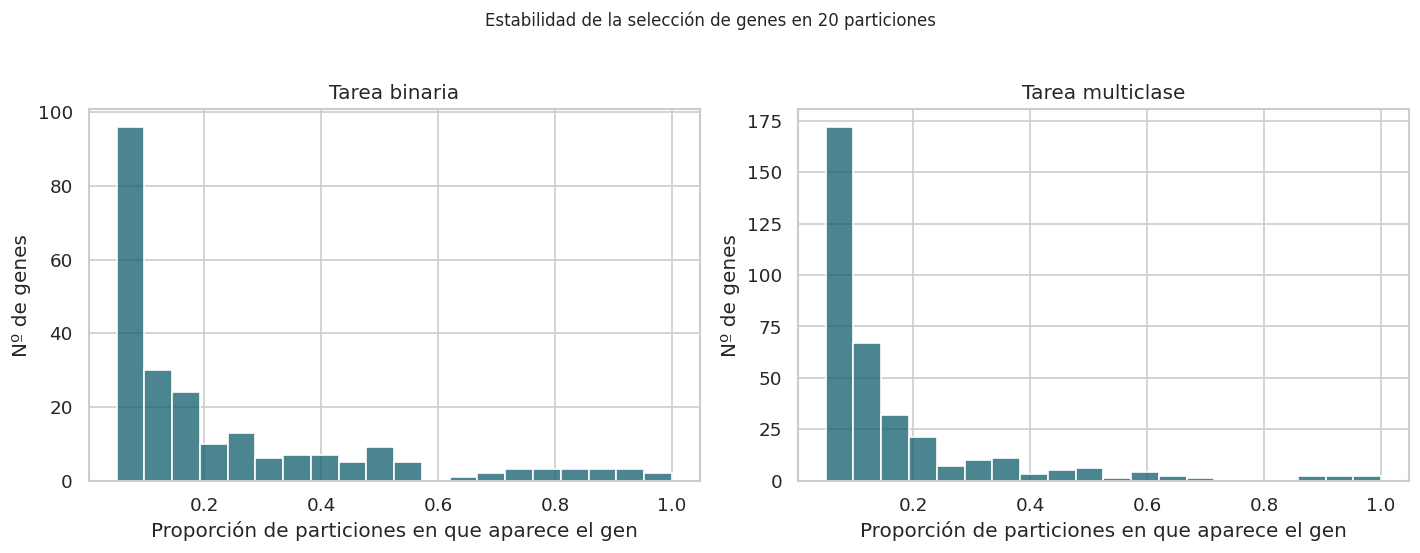

In [198]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
for eje, (titulo, estabilidad) in zip(
        ejes, [("Tarea binaria", estabilidad_firma_bin),
               ("Tarea multiclase", estabilidad_firma_multi)]):
    sns.histplot(estabilidad.values, bins=20, color=verde_azulado, ax=eje)
    eje.set_title(titulo)
    eje.set_xlabel("Proporción de particiones en que aparece el gen")
    eje.set_ylabel("Nº de genes")
plt.suptitle("Estabilidad de la selección de genes en 20 particiones",
             y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

In [199]:
# Firma restringida a los genes de selección reproducible
firma_estable_bin = estabilidad_firma_bin[estabilidad_firma_bin >= 0.8]
firma_estable_multi = estabilidad_firma_multi[estabilidad_firma_multi >= 0.8]

print(f"Firma estable — binaria: {len(firma_estable_bin)} genes")
print((firma_estable_bin * 100).round(0).astype(int).to_string(header=False))
print(f"\nFirma estable — multiclase: {len(firma_estable_multi)} genes")
print((firma_estable_multi * 100).round(0).astype(int).to_string(header=False))

Firma estable — binaria: 14 genes
ENSG00000184206    100
ENSG00000128596    100
ENSG00000134121     95
ENSG00000129646     95
ENSG00000226179     95
ENSG00000114739     90
ENSG00000196581     90
ENSG00000197830     90
ENSG00000213160     85
ENSG00000117318     85
ENSG00000243364     85
ENSG00000267364     80
ENSG00000232021     80
ENSG00000211710     80

Firma estable — multiclase: 6 genes
ENSG00000154620    100
ENSG00000146834    100
ENSG00000235770     95
ENSG00000196935     95
ENSG00000048740     90
ENSG00000105376     90


La selección de genes resulta considerablemente inestable. A lo largo de 20 particiones, la tarea binaria selecciona 232 genes distintos para configurar una firma que en cada caso consta de 50, y de todos ellos solo 2 aparecen en la totalidad de los repartos. Casi la mitad, 96 genes, se seleccionan en una única partición y no vuelven a figurar en ninguna otra. La tarea multiclase presenta un comportamiento aún más destacable, con 348 genes distintos y 172 de aparición única.

El histograma refleja esa dispersión con claridad, enseñando que la distribución se concentra en el extremo izquierdo, de modo que la mayoría de los genes seleccionados aparecen en menos de una quinta parte de las particiones, mientras que la zona de alta frecuencia queda prácticamente vacía. Solo 14 genes en la tarea binaria y 6 en la multiclase superan el umbral del 80% de apariciones.

De la firma indicada en el apartado anterior, únicamente 10 de sus 50 genes alcanzan ese nivel de estabilidad en la tarea binaria, y 4 de 90 en la multiclase. La lista concreta obtenida depende, por tanto, en gran parte del reparto de las muestras.

Este resultado reproduce el fenómeno descrito por Abeel et al. (2010), según el cual las firmas génicas obtenidas a partir de datos de expresión varían sustancialmente ante pequeños cambios en las muestras de entrenamiento, sin que el rendimiento predictivo se vea afectado en la misma medida. La explicación se encuentra en la estructura de los datos: con miles de genes correlacionados entre sí y menos de 300 muestras, existen numerosos subconjuntos capaces de conseguir predicciones equivalentes, de modo que el que se selecciona depende de detalles del conjunto de entrenamiento.

La consecuencia práctica es que la firma debe restringirse a los genes de selección reproducible.
- 14 genes superan el 80% de apariciones en la tarea binaria, encabezados por ENSG00000184206 y ENSG00000128596, presentes en las 20 particiones.
- En la tarea multiclase el conjunto reproducible se reduce a 6 genes, encabezados por ENSG00000154620 y ENSG00000146834. 4 de ellos figuraban ya en las firmas por tipo tumoral obtenidas anteriormente, y todos en las mismas dos categorías: ENSG00000105376 y ENSG00000146834 ocupan los puestos segundo y cuarto entre los característicos del cáncer de mama, mientras que ENSG00000196935 y ENSG00000235770 aparecen en primer y decimocuarto lugar entre los del glioblastoma. Su permanencia a lo largo de 20 repartos distintos les da una solidez que el resto de la lista no posee, y resulta coherente que se concentren precisamente en 2 de las categorías con mejor rendimiento en la evaluación.
Por su parte, los otros dos genes estables, ENSG00000154620 y ENSG00000048740, no se encuentran en ninguna de las 6 firmas. La razón es que el criterio de estabilidad atiende al peso máximo del gen entre todas las clases sin distinguir su signo, de modo que un gen con coeficiente muy negativo para alguna categoría resulta seleccionado de forma consistente aunque no aparezca entre los que la identifican. Su contribución al modelo consiste, por tanto, en descartar clases más que en reconocerlas.

Ninguno de los genes estables de la tarea multiclase coincide con los de la binaria, algo esperable ya que ambas tareas responden a preguntas distintas.

### **Contraste con la variación de origen técnico**

En la preparación de los datos apareció un efecto de lote. Las muestras de Batch05 y Batch06 se separaban con claridad del resto, y se comprobó que corresponden a la cohorte aportada por el Massachusetts General Hospital, mientras que las demás proceden del centro de Ámsterdam. Ese grupo no incluye ningún control sano, ni glioblastomas, ni casos de páncreas, de modo que saber de qué lote viene una muestra ya informa sobre qué es.

El modelo podría, por tanto, estar reconociendo el hospital de procedencia en lugar del perfil biológico, y acertando por el motivo equivocado.

La forma de comprobarlo es contrastar dos listas de genes. Por un lado, los que producen las predicciones del modelo, que son los de la firma. Por otro lado, los que mejor separan unas tandas de otras, que recogen la variación técnica. Si ambas listas se solapan, la sospecha sería cierta. Si los genes de la firma resultan estar entre los que menos distinguen las tandas, se puede afirmar que el modelo se apoya en biología.

In [200]:
# Muestras de entrenamiento con lote conocido
lotes_ent = pd.Series({m: lote_por_columna.get(m) for m in X_ent_bin_norm.index})
con_lote = lotes_ent.dropna()
print(f"Muestras de entrenamiento con lote identificado: {len(con_lote)} "
      f"de {len(X_ent_bin_norm)}")
print(con_lote.value_counts().to_string(), "\n")

# Genes que mejor separan los lotes entre sí, sobre los mismos datos normalizados
X_lote = X_ent_bin_norm.loc[con_lote.index]
puntuaciones, _ = f_classif(X_lote.values, con_lote.values)
puntuaciones = np.nan_to_num(puntuaciones, nan=0.0)

genes_lote = pd.Series(puntuaciones, index=X_lote.columns).sort_values(ascending=False)
top_lote = set(genes_lote.head(500).index)
print(f"Genes más asociados al lote de procesamiento: se retienen los 500 primeros")

Muestras de entrenamiento con lote identificado: 170 de 228
Batch03    59
Batch04    52
Batch06    25
Batch02    24
Batch05     9
Batch01     1 

Genes más asociados al lote de procesamiento: se retienen los 500 primeros


Con los genes ordenados según cuánto distinguen unas tandas de otras, se toman los 500 primeros y se mira cuántos de ellos aparecen en cada firma.

In [201]:
firma_binaria_genes = set(firma_bin["gen"])
firma_multi_genes = set().union(*[set(g.index) for g in firmas_por_clase.values()])

for nombre, firma in [("binaria", firma_binaria_genes),
                      ("multiclase", firma_multi_genes)]:
    comunes = firma & top_lote
    esperado = len(firma) * len(top_lote) / len(genes_lote)
    print(f"Firma {nombre}: {len(firma)} genes")
    print(f"  coincidentes con los 500 más asociados al lote: {len(comunes)}")
    print(f"  coincidencias esperables por azar: {esperado:.1f}")
    if comunes:
        print(f"  genes coincidentes: {sorted(comunes)}")
    print()

Firma binaria: 50 genes
  coincidentes con los 500 más asociados al lote: 0
  coincidencias esperables por azar: 1.9

Firma multiclase: 90 genes
  coincidentes con los 500 más asociados al lote: 2
  coincidencias esperables por azar: 3.4
  genes coincidentes: ['ENSG00000100614', 'ENSG00000159461']



Ninguno de los 50 genes de la firma binaria coincide con los 500 más asociados al lote, y en la multiclase aparecen 2 de 90, en ambos casos por debajo de lo esperable por azar. Sin embargo, ese recuento solo mira la cabecera de la lista, por lo que es más informativo comprobar en qué posición del ranking completo se sitúan los genes de cada firma, ya que eso indica si además de evitar los más contaminados, muestran alguna preferencia por los limpios.

In [202]:
rango_lote = pd.Series(range(1, len(genes_lote) + 1), index=genes_lote.index)
total = len(rango_lote)

print(f"Posición de los genes de cada firma en el ranking de asociación con el lote")
print(f"(la posición 1 corresponde al gen más asociado, de {total:,} en total)\n")

for nombre, firma in [("Firma binaria", firma_binaria_genes),
                      ("Firma multiclase", firma_multi_genes),
                      ("Firma estable binaria", set(firma_estable_bin.index)),
                      ("Firma estable multiclase", set(firma_estable_multi.index))]:
    posiciones = [rango_lote[g] for g in firma if g in rango_lote]
    en_primera_mitad = sum(1 for p in posiciones if p <= total / 2)
    print(f"{nombre}")
    print(f"  genes con posición conocida: {len(posiciones)} de {len(firma)}")
    print(f"  mediana: {np.median(posiciones):,.0f}")
    print(f"  rango:   {min(posiciones):,.0f} – {max(posiciones):,.0f}")
    print(f"  en la primera mitad del ranking: {en_primera_mitad} de {len(posiciones)} "
          f"(unos {len(posiciones)//2} si se repartiesen al azar)\n")

Posición de los genes de cada firma en el ranking de asociación con el lote
(la posición 1 corresponde al gen más asociado, de 13,343 en total)

Firma binaria
  genes con posición conocida: 50 de 50
  mediana: 11,032
  rango:   4,036 – 13,335
  en la primera mitad del ranking: 6 de 50 (unos 25 si se repartiesen al azar)

Firma multiclase
  genes con posición conocida: 90 de 90
  mediana: 7,120
  rango:   412 – 13,331
  en la primera mitad del ranking: 43 de 90 (unos 45 si se repartiesen al azar)

Firma estable binaria
  genes con posición conocida: 14 de 14
  mediana: 12,268
  rango:   5,147 – 13,335
  en la primera mitad del ranking: 1 de 14 (unos 7 si se repartiesen al azar)

Firma estable multiclase
  genes con posición conocida: 6 de 6
  mediana: 5,302
  rango:   1,122 – 9,531
  en la primera mitad del ranking: 3 de 6 (unos 3 si se repartiesen al azar)



Los resultados son bastante diferentes según la tarea, así que hay que verlos por separado.

En la detección de cáncer, los genes del modelo evitan los más contaminados por el lote dado que están agrupados en la cola de la lista, entre los que menos distinguen unas tandas de otras. El gen que ocupa la posición central de la firma es el 11032 de 13343, y solo 6 de los 50 aparecen en la mitad más afectada, cuando deberían ser unos 25 si estuvieran repartidos al azar. Incluso el más relacionado de todos, ocupa el puesto 4036, lejos de la cabecera.

Los 14 genes que el modelo elige de forma constante consolidan este resultado, con una posición central de 12268 y uno solo en la primera mitad frente a los 7 esperables. Por tanto, son los que menos tienen que ver con el hospital de procedencia.

En la clasificación del tipo de tumor ocurre algo distinto. La posición central de sus genes es la 7120, prácticamente el medio de la lista, y 43 de sus 90 caen en la mitad más afectada cuando el azar daría alrededor de 45. Es decir, se reparten como lo haría cualquier grupo de genes escogido sin criterio. Solo evitan los casos más extremos, con 2 coincidencias entre los 500 primeros frente a las 3,4 esperables, pero no muestran ninguna inclinación hacia los genes limpios.

Los 6 que resultan estables son demasiado pocos para sacar conclusiones de su reparto.

Por tanto, la conclusión depende de la tarea. En la detección de cáncer sí puede afirmarse que el modelo se apoya en diferencias biológicas y no en el hospital que envió la muestra, lo que resuelve la duda que quedó abierta al preparar los datos. Sin embargo, en la clasificación del tipo de tumor no puede afirmarse lo mismo, y encaja con que el centro de Boston aportó sobre todo casos de pulmón y de mama, así que la procedencia coincide con la enfermedad justo en la tarea que trata de distinguir unos tumores de otros. No se puede descartar que parte del acierto venga de reconocer de dónde procede la muestra, y así se recoge entre las limitaciones.

Queda un detalle sobre en qué muestras se apoya esta comprobación. El lote pudo determinarse en 170 de las 228 de entrenamiento, todas de pacientes con cáncer, porque los controles sanos no se pueden emparejar de forma fiable entre los dos archivos. Además, dejarlos fuera resulta mejor porque como la procedencia va ligada a la enfermedad, buscar los genes del lote incluyendo también los controles mezclaría lo técnico con lo biológico y haría la comparación menos limpia.